# Промышленность

## Описание проекта

Чтобы оптимизировать производственные расходы, металлургический комбинат «Стальная птица» решил уменьшить потребление электроэнергии на этапе обработки стали.  
Для этого комбинату нужно контролировать температуру сплава.  
Задача — построить модель, которая будет её предсказывать.  
Заказчик хочет использовать разработанную модель для имитации технологического процесса.  

## Описание процесса обработки

Сталь обрабатывают в металлическом ковше вместимостью около 100 тонн.  
Чтобы ковш выдерживал высокие температуры, изнутри его облицовывают огнеупорным кирпичом.  
Расплавленную сталь заливают в ковш и подогревают до нужной температуры графитовыми электродами. Они установлены на крышке ковша.  
Сначала происходит десульфурация — из стали выводят серу и корректируют её химический состав добавлением примесей.  
Затем сталь легируют — добавляют в неё куски сплава из бункера для сыпучих материалов или порошковую проволоку через специальный трайб-аппарат.  
Прежде чем в первый раз ввести легирующие добавки, специалисты производят химический анализ стали и измеряют её температуру.  
Потом температуру на несколько минут повышают, уже после этого добавляют легирующие материалы и продувают сталь инертным газом, чтобы перемешать, а затем снова проводят измерения.  
Такой цикл повторяется до тех пор, пока не будут достигнуты нужный химический состав стали и оптимальная температура плавки.  
Дальше расплавленная сталь отправляется на доводку металла или поступает в машину непрерывной разливки.  
Оттуда готовый продукт выходит в виде заготовок-слябов (англ. slab, «плита»).

## Описание данных

Данные хранятся в Sqlite  — СУБД, в которой база данных представлена одним файлом.  
Она состоит из нескольких таблиц:  
- steel.data_arc — данные об электродах;  
- steel.data_bulk — данные об объёме сыпучих материалов;  
- steel.data_bulk_time — данные о времени подачи сыпучих материалов;  
- steel.data_gas — данные о продувке сплава газом;  
- steel.data_temp — данные об измерениях температуры;  
- steel.data_wire — данные об объёме проволочных материалов;  
- steel.data_wire_time — данные о времени подачи проволочных материалов.  

Таблица steel.data_arc  
- key — номер партии;
- BeginHeat — время начала нагрева;
- EndHeat — время окончания нагрева;
- ActivePower — значение активной мощности;
- ReactivePower — значение реактивной мощности.

Таблица steel.data_bulk
- key — номер партии;
- Bulk1 … Bulk15 — объём подаваемого материала.  

Таблица steel.data_bulk_time  
- key — номер партии;
- Bulk1 … Bulk15 — время подачи материала.

Таблица steel.data_gas
- key — номер партии;
- gas — объём подаваемого газа.

Таблица steel.data_temp
- key — номер партии;
- MesaureTime — время замера;
- Temperature — значение температуры.

Таблица steel.data_wire
- key — номер партии;
- Wire1 … Wire9 — объём подаваемых проволочных материалов.

Таблица steel.data_wire_time
- key — номер партии;
- Wire1 … Wire9 — время подачи проволочных материалов.  

Во всех файлах столбец key содержит номер партии.  
В таблицах может быть несколько строк с одинаковым значением key: они соответствуют разным итерациям обработки.

# Проектирование

In [1]:
# !pip install catboost -q

## Импорты

In [2]:
# ============================================
# СТАНДАРТНЫЕ БИБЛИОТЕКИ PYTHON
# ============================================
import os
import re
import logging
import warnings
import random
from tqdm import tqdm
from IPython.display import HTML, display


# ============================================
# ОСНОВНЫЕ БИБЛИОТЕКИ ДЛЯ АНАЛИЗА ДАННЫХ
# ============================================
import numpy as np
import pandas as pd

# ============================================
# ВИЗУАЛИЗАЦИЯ
# ============================================
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# ============================================
# РАБОТА С БАЗАМИ ДАННЫХ
# ============================================
from sqlalchemy import create_engine, inspect, Table, MetaData
from sqlalchemy.orm import sessionmaker

# ============================================
# ПРЕДОБРАБОТКА ДАННЫХ И СТАТИСТИКА
# ============================================
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ============================================
# КОРРЕЛЯЦИОННЫЙ АНАЛИЗ (PHIK)
# ============================================
import phik
from phik import phik_matrix

# ============================================
# РАЗДЕЛЕНИЕ ДАННЫХ, КРОСС-ВАЛИДАЦИЯ, ОТБОР ПРИЗНАКОВ
# ============================================
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.feature_selection import SelectKBest, f_regression

# ============================================
# МЕТРИКИ КАЧЕСТВА
# ============================================
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# ============================================
# МОДЕЛИ МАШИННОГО ОБУЧЕНИЯ
# ============================================
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
import lightgbm as lgb

# ============================================
# ПАЙПЛАЙНЫ
# ============================================
from sklearn.pipeline import Pipeline

# ============================================
# ОПТИМИЗАЦИЯ ГИПЕРПАРАМЕТРОВ (OPTUNA)
# ============================================
import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler

# ============================================
# ГЛУБОКОЕ ОБУЧЕНИЕ (PYTORCH)
# ============================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ============================================
# НАСТРОЙКИ ЛОГИРОВАНИЯ И ПРЕДУПРЕЖДЕНИЙ
# ============================================
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(name)s: %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logger = logging.getLogger(__name__)

# Отключаем лишние предупреждения
warnings.filterwarnings("ignore")

e:\my_github\yandex_practicum_ds\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Константы

In [3]:
BD = '../data/ds-plus-final.db'
RANDOM_STATE = 10326
THRESHOLD = 0.99 # это для удаления пропусков, где больше N%
TEST_SIZE = 0.25
TARGET = 'конечная_температура'
N_TRIALS_NN = 5
CV_FOLDS = 2

N_TRIALS_CB = 30
CAT_EARLY_STOP = 20
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
logger.info(DEVICE)

2026-03-04 23:48:44 [INFO] __main__: cuda


## Функции проекта

In [4]:
# сделаем функцию оценки пропусков в датасетах
def missing_data(data):
    missing_data = data.isna().sum()
    missing_data = missing_data[missing_data > 0]
    display(missing_data)


# функция для обработки пробелов
def process_spaces(s):
    if isinstance(s, str):
        s = s.strip()
        s = " ".join(s.split())
    return s


# замена пробелов на нижнее подчеркинвание в названии столбцов
def replace_spaces(s):
    if isinstance(s, str):
        s = s.strip()
        s = "_".join(s.split())
    return s


def drop_duplicated(data):
    # проверка дубликатов
    logger.info("Проверим дубликаты и удалим, если есть")
    num_duplicates = data.duplicated().sum()
    display(num_duplicates)

    if num_duplicates > 0:
        logger.info("Удаляем")
        data = data.drop_duplicates(keep="first").reset_index(
            drop=True
        )  # обновляем DataFrame
    else:
        logger.info("Дубликаты отсутствуют")
    return data


def normalize_columns(columns):
    new_cols = []
    for col in columns:
        # вставляем "_" перед заглавной буквой (латиница или кириллица), кроме первой
        col = re.sub(r"(?<!^)(?=[A-ZА-ЯЁ])", "_", col)
        # приводим к нижнему регистру
        col = col.lower()
        new_cols.append(col)
    return new_cols


def check_data(data):
    # приведем все к нижнему регистру
    data.columns = normalize_columns(data.columns)

    # удалим лишние пробелы в строках
    for col in data.columns:
        if data[col].dtype == "object":
            data[col] = data[col].apply(
                lambda x: process_spaces(x) if isinstance(x, str) else x
            )

    # и в названии столбцов
    data.columns = [replace_spaces(col) for col in data.columns]

    # строки в ячейках строчными буквами
    for col in data.columns:
        if data[col].dtype == "object":
            # Безопасное преобразование: только для строк, игнорируем None и не-строки
            data[col] = data[col].apply(
                lambda x: x.lower() if isinstance(x, str) else x
            )

    # общая информация
    logger.info("Общая информация базы данных")
    display(data.info())

    # 5 строк
    logger.info("5 случайных строк")
    display(data.sample(5))

    # пропуски
    logger.info("Число пропусков в базе данных")
    display(missing_data(data))

    # проверка на наличие пропусков
    if data.isnull().sum().sum() > 0:
        logger.info("Визуализация пропусков")
        msno.bar(data)
        plt.show()

    # средние характеристики
    logger.info("Характеристики базы данных")
    display(data.describe().T)

    # data = drop_duplicated(data)

    return data  # возвращаем измененные данные

def plot_combined(data, col=None, target=None, col_type=None, legend_loc='best'):
    """
    Строит графики для числовых столбцов в DataFrame, автоматически определяя их типы (дискретные или непрерывные).

    :param data: DataFrame, содержащий данные для визуализации.
    :param col: Список столбцов для построения графиков. Если None, будут использованы все числовые столбцы.
    :param target: Столбец, по которому будет производиться разделение (для hue в графиках).
    :param col_type: Словарь, определяющий типы столбцов ('col' для непрерывных и 'dis' для дискретных).
                     Если None, типы будут определены автоматически.
    :param legend_loc: Положение легенды для графиков (по умолчанию 'best').
    :return: None. Графики отображаются с помощью plt.show().
    """
    
    # Определяем числовые столбцы
    if col is None:
        numerical_columns = data.select_dtypes(include=['int', 'float']).columns.tolist()
    else:
        numerical_columns = col

    # Если col_type не указан, определяем типы автоматически
    if col_type is None:
        col_type = {}
        for col in numerical_columns:
            unique_count = data[col].nunique()
            if unique_count > 20:
                col_type[col] = 'col'  # Непрерывные данные
            else:
                col_type[col] = 'dis'  # Дискретные данные

    total_plots = len(numerical_columns) * 2
    ncols = 2
    nrows = (total_plots + ncols - 1) // ncols

    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 5 * nrows))
    axs = axs.flatten()

    index = 0

    for col in numerical_columns:
        # Определяем тип графика
        plot_type = col_type.get(col)
        if plot_type is None:
            raise ValueError(f"Тип для столбца '{col}' не указан в col_type.")

        # Гистограмма или countplot
        if index < len(axs):
            if plot_type == 'col':
                if target is not None:
                    sns.histplot(data, x=col, hue=target, bins=20, kde=True, ax=axs[index])
                    handles, labels = axs[index].get_legend_handles_labels()
                    if handles:
                        axs[index].legend(title=target, loc=legend_loc)
                else:
                    sns.histplot(data[col].dropna(), bins=20, kde=True, ax=axs[index])
                axs[index].set_title(f'Гистограмма: {col}')
            elif plot_type == 'dis':
                if target is not None:
                    sns.countplot(data=data, x=col, hue=target, ax=axs[index])
                    handles, labels = axs[index].get_legend_handles_labels()
                    if handles:
                        axs[index].legend(title=target, loc=legend_loc)
                else:
                    sns.countplot(data=data, x=col, ax=axs[index])
                axs[index].set_title(f'Countplot: {col}')
            index += 1

        # Боксплот
        if index < len(axs):
            sns.boxplot(x=data[col], ax=axs[index])
            axs[index].set_title(f'Боксплот: {col}')
            index += 1

    # Отключаем оставшиеся оси
    for j in range(index, len(axs)):
        axs[j].axis('off')

    plt.tight_layout()
    plt.show()
    
def clear_df_missing_cols(df):
    missing_ratio = df.isna().mean()
    cols_to_keep = missing_ratio[missing_ratio <= THRESHOLD].index.tolist()
    df = df[cols_to_keep]

    logger.info(f"Удалено признаков: {len(missing_ratio) - len(cols_to_keep)}")
    logger.info(f"Осталось признаков: {len(cols_to_keep)}")    
    return df

## Загрузка данных

### Подключение движка

In [5]:
metadata = MetaData()
engine = create_engine(f'sqlite:///{BD}', echo=False)
inspector = inspect(engine)
Session = sessionmaker(engine)

### Исследовательский анализ

#### Данные в БД

In [6]:
# посмотрим что есть в БД
table_names = inspector.get_table_names()
logger.info(table_names)

2026-03-04 23:48:44 [INFO] __main__: ['contract', 'data_arc', 'data_bulk', 'data_bulk_time', 'data_gas', 'data_temp', 'data_wire', 'data_wire_time', 'internet', 'personal', 'phone']


В нашем файлике есть еще и "левые данные" по второму проекту  
Ну да пусть будут, нам нужны только с префикмом data_ 


#### Наличие данных в таблицах

In [7]:
# объявим переменные
data_arc = Table('data_arc', metadata, autoload_with=engine)
data_bulk = Table('data_bulk', metadata, autoload_with=engine)
data_bulk_time = Table('data_bulk_time', metadata, autoload_with=engine)
data_gas = Table('data_gas', metadata, autoload_with=engine)
data_temp = Table('data_temp', metadata, autoload_with=engine)
data_wire = Table('data_wire', metadata, autoload_with=engine)
data_wire_time = Table('data_wire_time', metadata, autoload_with=engine)

In [8]:
# и преобразуем в пандас для удобства работы
df_arc = pd.read_sql(data_arc.select(), engine)
df_bulk = pd.read_sql(data_bulk.select(), engine)
df_bulk_time = pd.read_sql(data_bulk_time.select(), engine)
df_gas = pd.read_sql(data_gas.select(), engine)
df_temp = pd.read_sql(data_temp.select(), engine)
df_wire = pd.read_sql(data_wire.select(), engine)
df_wire_time = pd.read_sql(data_wire_time.select(), engine)

##### df_arc

1. Изучить пропуски и аномалии, распределение признаков;  
2. Скорректировать или удалить партии с аномальными значениями;  
3. Генерация новых признаков - длительность нагрева, общую мощность, соотношение активной мощности к реактивной, количество запуска нагрева электродами;  

In [9]:
df_arc = check_data(df_arc)

2026-03-04 23:48:44 [INFO] __main__: Общая информация базы данных


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14876 entries, 0 to 14875
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   key                   14876 non-null  int64  
 1   начало_нагрева_дугой  14876 non-null  object 
 2   конец_нагрева_дугой   14876 non-null  object 
 3   активная_мощность     14876 non-null  float64
 4   реактивная_мощность   14876 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 581.2+ KB


None

2026-03-04 23:48:44 [INFO] __main__: 5 случайных строк


,key,начало_нагрева_дугой,конец_нагрева_дугой,активная_мощность,реактивная_мощность
2891,630,2019-05-27 13:06:54,2019-05-27 13:10:30,1.239881,1.132839
1439,312,2019-05-15 12:04:31,2019-05-15 12:15:56,0.857520,0.736287
4894,1056,2019-06-13 01:20:38,2019-06-13 01:21:31,0.361300,0.276932
7624,1656,2019-07-04 06:41:16,2019-07-04 06:43:06,0.525341,0.376794
9211,1998,2019-07-23 09:07:38,2019-07-23 09:10:30,0.542336,0.371648


2026-03-04 23:48:44 [INFO] __main__: Число пропусков в базе данных


Series([], dtype: int64)

None

2026-03-04 23:48:44 [INFO] __main__: Характеристики базы данных


,count,mean,std,min,25%,50%,75%,max
key,14876.0,1615.220422,934.571502,1.000000,806.000000,1617.000000,2429.000000,3241.000000
активная_мощность,14876.0,0.662752,0.258885,0.223120,0.467115,0.599587,0.830070,1.463773
реактивная_мощность,14876.0,0.438986,5.873485,-715.479924,0.337175,0.441639,0.608201,1.270284


Пропусков нет  
Даты надо преобразовать в нормальный тип  

Что проверить  
1) сопоставление дат - начало должно быть раньше конца  

In [10]:
df_arc['начало_нагрева_дугой'] = df_arc['начало_нагрева_дугой'].astype('datetime64[ns]')
df_arc['конец_нагрева_дугой'] = df_arc['конец_нагрева_дугой'].astype('datetime64[ns]')

In [11]:
df_arc['продолжительность_нагрева_сек'] = (df_arc['конец_нагрева_дугой'] - df_arc['начало_нагрева_дугой']).dt.total_seconds()

In [12]:
df_arc.describe().T

,count,mean,min,25%,50%,75%,max,std
key,14876.0,1615.220422,1.0,806.0,1617.0,2429.0,3241.0,934.571502
начало_нагрева_дугой,14876,2019-07-05 12:25:51.921081088,2019-05-03 11:02:14,2019-06-03 23:18:23.249999872,2019-07-03 01:31:26.500000,2019-08-07 22:52:20.750000128,2019-09-06 17:24:54,NaN
конец_нагрева_дугой,14876,2019-07-05 12:28:43.592027392,2019-05-03 11:06:02,2019-06-03 23:21:35,2019-07-03 01:35:13,2019-08-07 22:56:47,2019-09-06 17:26:15,NaN
активная_мощность,14876.0,0.662752,0.22312,0.467115,0.599587,0.83007,1.463773,0.258885
реактивная_мощность,14876.0,0.438986,-715.479924,0.337175,0.441639,0.608201,1.270284,5.873485
продолжительность_нагрева_сек,14876.0,171.670946,11.0,107.0,147.0,214.0,907.0,98.186803


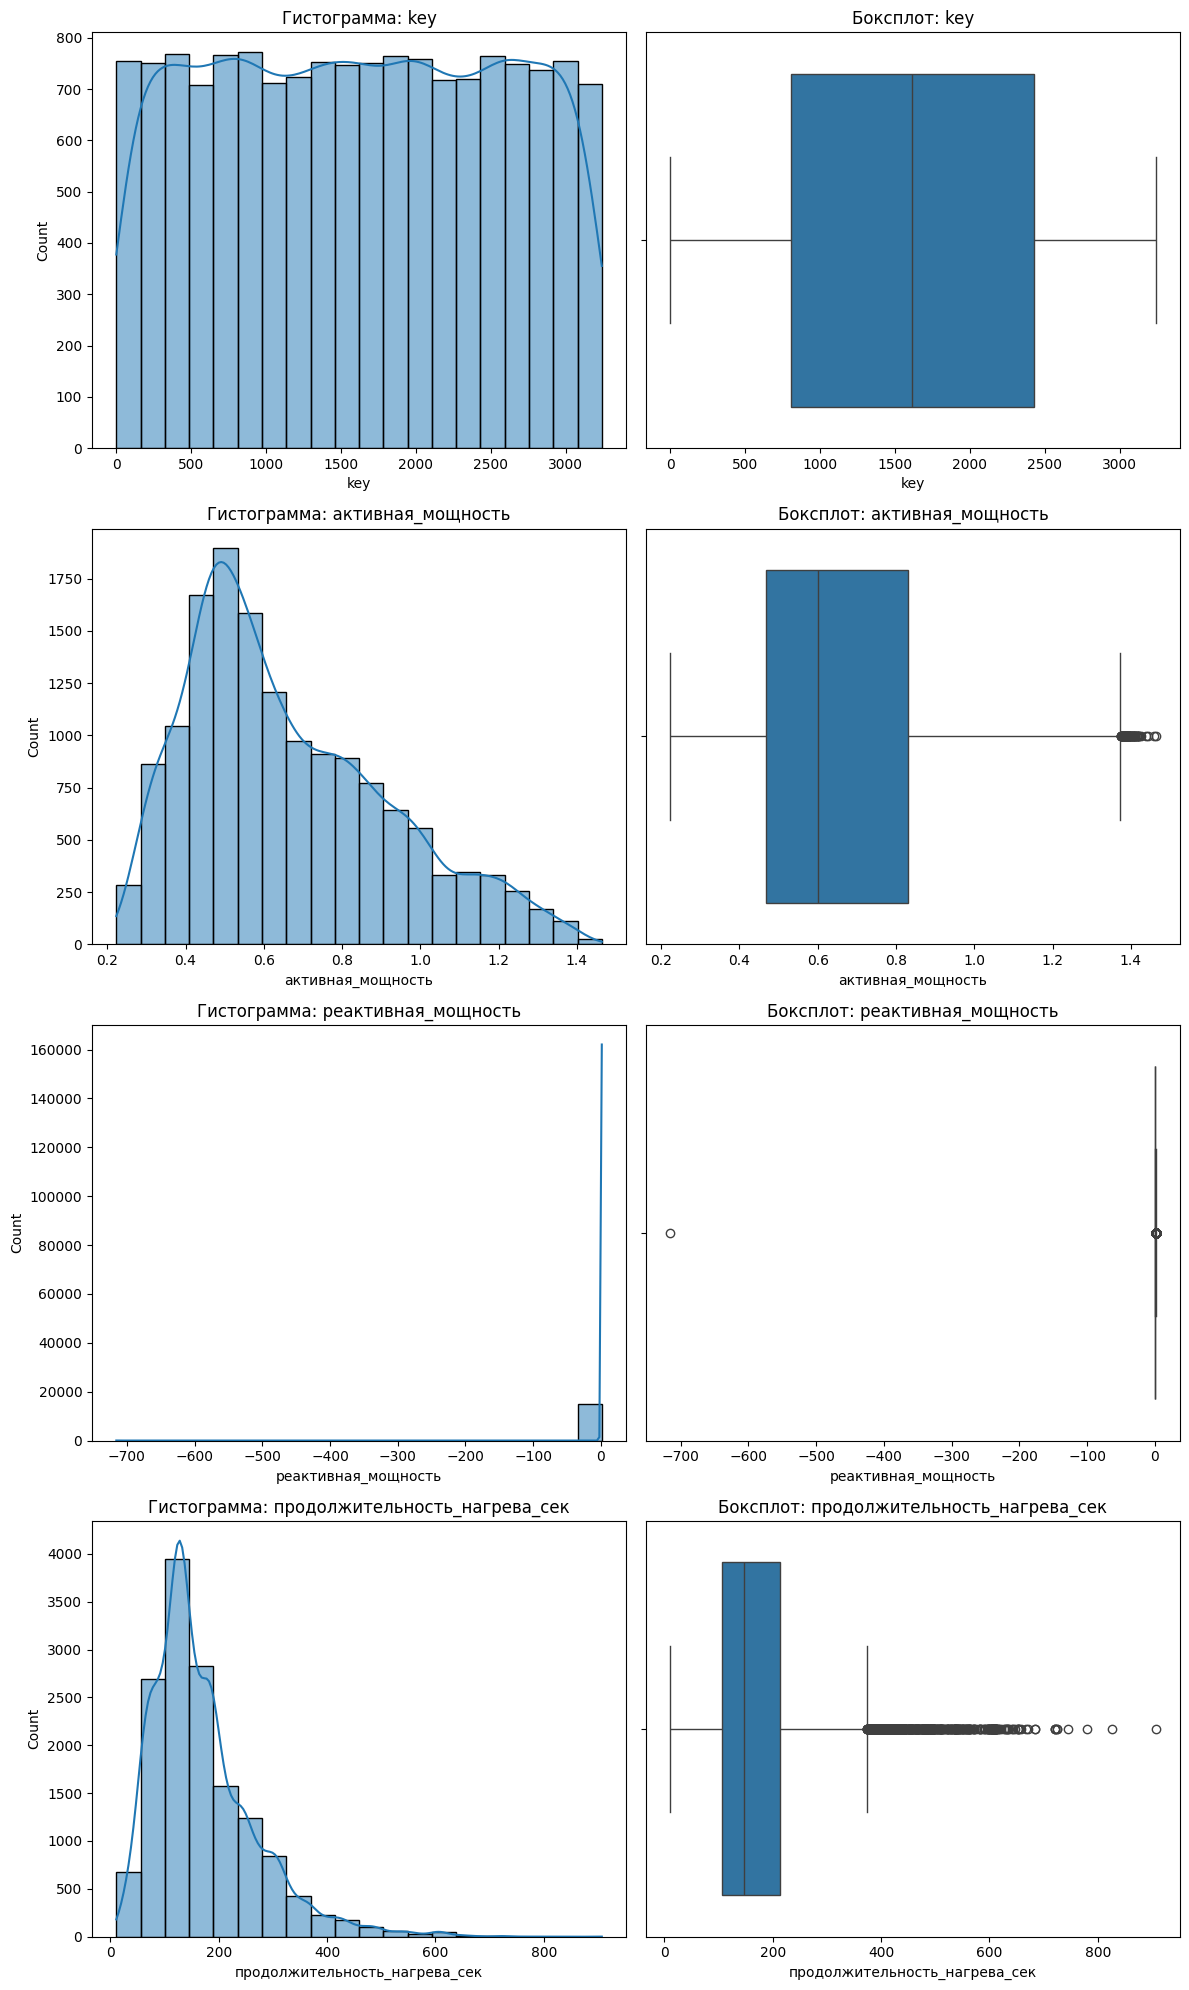

In [13]:
# теперь посмотрим распределение данных
plot_combined(df_arc, col=None, target=None, col_type=None, legend_loc='best')

Везде наблюдаем наличие сильных выбросов, проверим детальнее  
К тому же есть отрицательные значения чего не должно быть

In [14]:
df_arc[df_arc['активная_мощность'] > 1.3]

,key,начало_нагрева_дугой,конец_нагрева_дугой,активная_мощность,реактивная_мощность,продолжительность_нагрева_сек
171,38,2019-05-04 17:18:40,2019-05-04 17:21:07,1.336674,1.213404,147.0
296,64,2019-05-05 22:47:19,2019-05-05 22:49:19,1.316444,1.054070,120.0
331,70,2019-05-06 04:00:31,2019-05-06 04:02:06,1.341706,0.950409,95.0
493,106,2019-05-07 08:16:16,2019-05-07 08:21:28,1.327936,0.969106,312.0
517,113,2019-05-07 15:41:34,2019-05-07 15:43:52,1.317665,0.945464,138.0
...,...,...,...,...,...,...
14368,3123,2019-09-02 16:59:39,2019-09-02 17:00:40,1.330737,0.915607,61.0
14549,3166,2019-09-03 22:18:01,2019-09-03 22:20:04,1.368719,1.083031,123.0
14577,3172,2019-09-04 05:58:03,2019-09-04 06:03:15,1.316411,0.886694,312.0
14775,3219,2019-09-05 21:47:29,2019-09-05 21:51:18,1.347920,1.025508,229.0


Значения увеличиваются равномерно и постепенно, сложно сказать ошибка это или нет

In [15]:
df_arc[df_arc['реактивная_мощность'] < 0]

,key,начало_нагрева_дугой,конец_нагрева_дугой,активная_мощность,реактивная_мощность,продолжительность_нагрева_сек
9780,2116,2019-07-28 02:22:08,2019-07-28 02:23:57,0.705344,-715.479924,109.0


Явная ошибка заполнения данных, посчитаем среднюю активная_мощность и среднюю реактивная_мощность  
Посмотрим коэффицент изменения и изменим эту ошибку соответственно

In [16]:
avg_act_power = df_arc['активная_мощность'].mean()
avg_react_power = df_arc['реактивная_мощность'].mean()
koef_power = (avg_act_power / avg_react_power) - 1
logger.info(avg_act_power)
logger.info(avg_react_power)
logger.info(koef_power)


2026-03-04 23:48:46 [INFO] __main__: 0.6627522122882497
2026-03-04 23:48:46 [INFO] __main__: 0.43898642672761495
2026-03-04 23:48:46 [INFO] __main__: 0.5097328116239874


In [17]:
df_arc.loc[df_arc['реактивная_мощность'] < 0, 'реактивная_мощность'] = df_arc['активная_мощность'] * koef_power

In [18]:
df_arc[df_arc['продолжительность_нагрева_сек'] > 400]

,key,начало_нагрева_дугой,конец_нагрева_дугой,активная_мощность,реактивная_мощность,продолжительность_нагрева_сек
20,5,2019-05-03 13:23:32,2019-05-03 13:30:27,0.461620,0.308665,415.0
30,8,2019-05-03 14:53:56,2019-05-03 15:01:11,0.401980,0.292894,435.0
94,21,2019-05-04 03:42:26,2019-05-04 03:52:24,0.639156,0.425871,598.0
137,30,2019-05-04 10:49:25,2019-05-04 10:56:44,0.782927,0.546200,439.0
145,32,2019-05-04 12:58:33,2019-05-04 13:07:22,0.502953,0.352604,529.0
...,...,...,...,...,...,...
14654,3188,2019-09-04 20:54:34,2019-09-04 21:01:49,0.315474,0.254738,435.0
14659,3189,2019-09-04 22:29:02,2019-09-04 22:35:47,1.012875,0.772938,405.0
14772,3218,2019-09-05 20:49:26,2019-09-05 20:57:17,1.281652,1.074167,471.0
14779,3220,2019-09-05 22:35:56,2019-09-05 22:43:26,0.994169,0.720291,450.0


Здесь как будто бы тоже всё ок по времени, надо детальнее изучать вопрос относительно нормальности плавки

In [19]:
# добавим немного новых фич
df_arc['полная_мощность'] = np.sqrt(df_arc['активная_мощность']**2 + df_arc['реактивная_мощность']**2)
df_arc['соотношение_мощностей'] = df_arc['реактивная_мощность'] / df_arc['активная_мощность']
df_arc['энергия_нагрева'] = df_arc['активная_мощность'] * df_arc['продолжительность_нагрева_сек']
df_arc['cos_phi'] = 1 / np.sqrt(1 + df_arc['соотношение_мощностей']**2)

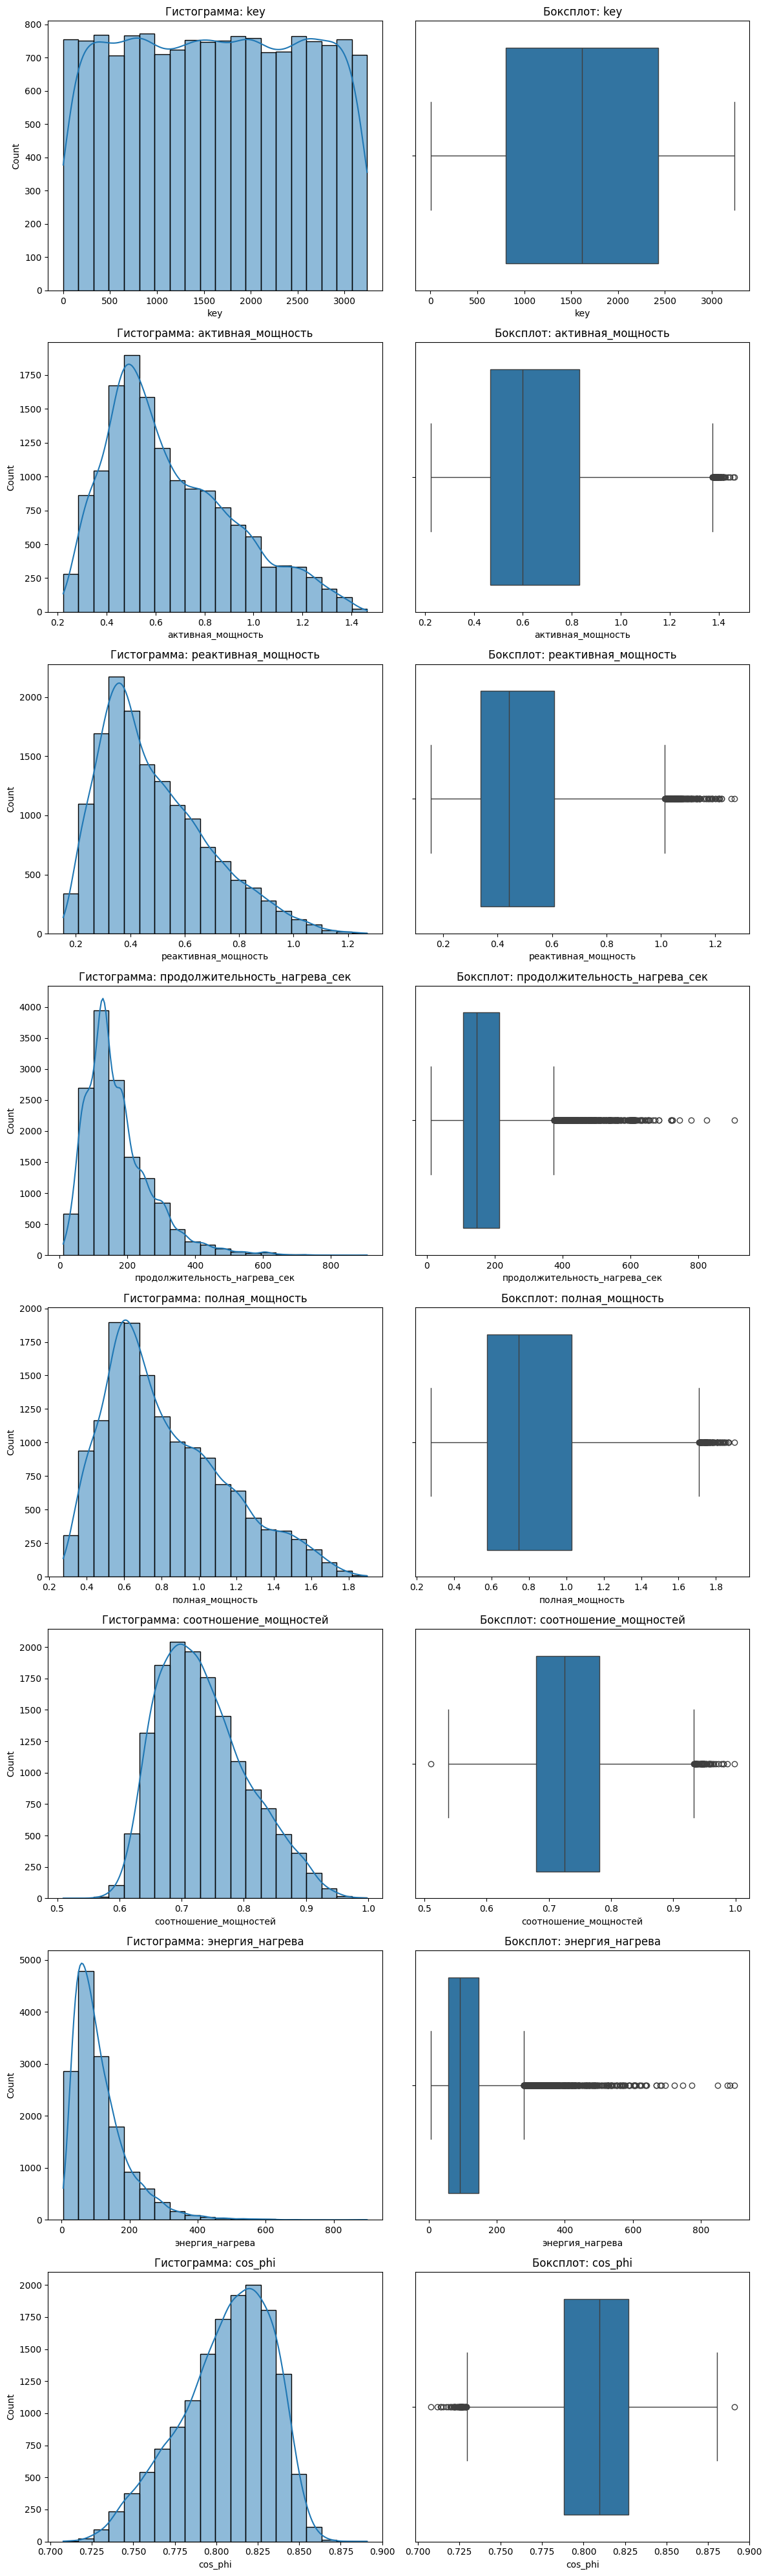

In [20]:
# теперь посмотрим распределение данных
plot_combined(df_arc, col=None, target=None, col_type=None, legend_loc='best')

In [21]:
display(df_arc.info())
display(df_arc.head())
display(df_arc.describe().T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14876 entries, 0 to 14875
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   key                            14876 non-null  int64         
 1   начало_нагрева_дугой           14876 non-null  datetime64[ns]
 2   конец_нагрева_дугой            14876 non-null  datetime64[ns]
 3   активная_мощность              14876 non-null  float64       
 4   реактивная_мощность            14876 non-null  float64       
 5   продолжительность_нагрева_сек  14876 non-null  float64       
 6   полная_мощность                14876 non-null  float64       
 7   соотношение_мощностей          14876 non-null  float64       
 8   энергия_нагрева                14876 non-null  float64       
 9   cos_phi                        14876 non-null  float64       
dtypes: datetime64[ns](2), float64(7), int64(1)
memory usage: 1.1 MB


None

,key,начало_нагрева_дугой,конец_нагрева_дугой,активная_мощность,реактивная_мощность,продолжительность_нагрева_сек,полная_мощность,соотношение_мощностей,энергия_нагрева,cos_phi
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253,228.0,0.371123,0.692338,69.569640,0.822181
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438,185.0,0.902319,0.623566,141.646730,0.848545
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460,172.0,0.722536,0.741772,99.813836,0.803161
3,1,2019-05-03 11:18:14,2019-05-03 11:24:19,0.518496,0.379979,365.0,0.642824,0.732848,189.251040,0.806591
4,1,2019-05-03 11:26:09,2019-05-03 11:28:37,0.867133,0.643691,148.0,1.079934,0.742321,128.335684,0.802950


,count,mean,min,25%,50%,75%,max,std
key,14876.0,1615.220422,1.0,806.0,1617.0,2429.0,3241.0,934.571502
начало_нагрева_дугой,14876,2019-07-05 12:25:51.921081088,2019-05-03 11:02:14,2019-06-03 23:18:23.249999872,2019-07-03 01:31:26.500000,2019-08-07 22:52:20.750000128,2019-09-06 17:24:54,NaN
конец_нагрева_дугой,14876,2019-07-05 12:28:43.592027392,2019-05-03 11:06:02,2019-06-03 23:21:35,2019-07-03 01:35:13,2019-08-07 22:56:47,2019-09-06 17:26:15,NaN
активная_мощность,14876.0,0.662752,0.22312,0.467115,0.599587,0.83007,1.463773,0.258885
реактивная_мощность,14876.0,0.487107,0.153777,0.337192,0.441639,0.608201,1.270284,0.197609
продолжительность_нагрева_сек,14876.0,171.670946,11.0,107.0,147.0,214.0,907.0,98.186803
полная_мощность,14876.0,0.823382,0.275718,0.578847,0.746591,1.03039,1.898158,0.323459
соотношение_мощностей,14876.0,0.734908,0.509733,0.679707,0.724754,0.781162,0.998261,0.072438
энергия_нагрева,14876.0,114.044276,5.246505,57.376903,92.194117,145.983547,898.200876,83.006059
cos_phi,14876.0,0.805893,0.707722,0.788058,0.809705,0.827039,0.890932,0.027664


Самое главное, надо переделать ключи в одну строку - в широкий формат  
Но только после того как создадим новые признаки

In [ ]:
# пока оставлю и этот вариант закоменченым

# df_arc['число_нагревов'] = df_arc.groupby('key').cumcount() + 1

# df_arc['длительность'] = (
#     pd.to_datetime(df_arc['конец_нагрева_дугой']) - 
#     pd.to_datetime(df_arc['начало_нагрева_дугой'])
# ).dt.total_seconds()

# avg_stats = df_arc.groupby('key').agg(
#     средняя_активная_мощность=('активная_мощность', 'mean'),
#     средняя_реактивная_мощность=('реактивная_мощность', 'mean'),
#     среднее_время_нагрева_сек=('длительность', 'mean')
# ).reset_index()

In [23]:
# values_cols = [col for col in df_arc.columns if col not in ['key', 'число_нагревов']]

# df_pivot = df_arc.pivot(
#     index='key',
#     columns='число_нагревов',
#     values=values_cols
# )

# df_pivot.columns = [f'{col[0]}_{col[1]}' for col in df_pivot.columns]
# df_pivot = df_pivot.reset_index()

# df_arc = df_pivot

In [24]:
df_arc['число_нагревов'] = df_arc.groupby('key').cumcount() + 1

df_arc['длительность'] = (
    pd.to_datetime(df_arc['конец_нагрева_дугой']) - 
    pd.to_datetime(df_arc['начало_нагрева_дугой'])
).dt.total_seconds()

df_agg = df_arc.groupby('key').agg(
    количество_нагревов=('число_нагревов', 'count'),
    суммарная_длительность=('длительность', 'sum'),
    средняя_длительность=('длительность', 'mean'),
    максимальная_длительность=('длительность', 'max'),
    средняя_активная_мощность=('активная_мощность', 'mean'),
    максимальная_активная_мощность=('активная_мощность', 'max'),
    средняя_реактивная_мощность=('реактивная_мощность', 'mean'),
).reset_index()

df_arc = df_agg

In [ ]:
# Одна плавка - одна строчка
display(df_arc.head())

2026-03-04 23:48:48 [INFO] __main__: Одна плавка - одна строчка:


,key,количество_нагревов,суммарная_длительность,средняя_длительность,максимальная_длительность,средняя_активная_мощность,максимальная_активная_мощность,средняя_реактивная_мощность
0,1,5,1098.0,219.60,365.0,0.607346,0.867133,0.428564
1,2,4,811.0,202.75,338.0,0.534852,0.786322,0.363339
2,3,5,655.0,131.00,280.0,0.812728,1.222963,0.587491
3,4,4,741.0,185.25,278.0,0.676622,0.887855,0.514248
4,5,4,869.0,217.25,415.0,0.563238,0.892957,0.421998


In [ ]:
# и почистим от мусорных столбцов
df_arc = clear_df_missing_cols(df_arc)

2026-03-04 23:48:48 [INFO] __main__: Удалено признаков: 0
2026-03-04 23:48:48 [INFO] __main__: Осталось признаков: 8


In [27]:
# и сразу заменим на 0 пропуски в активной и реактивной мощностях

power_cols = [col for col in df_arc.columns 
              if 'активная_мощность' in col or 'реактивная_мощность' in col]

missing_before = df_arc[power_cols].isna().sum().sum()
# df_arc[power_cols] = df_arc[power_cols].fillna(0)

##### df_bulk

2026-03-04 23:48:48 [INFO] __main__: Общая информация базы данных


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   key      3129 non-null   int64  
 1   bulk_1   252 non-null    float64
 2   bulk_2   22 non-null     float64
 3   bulk_3   1298 non-null   float64
 4   bulk_4   1014 non-null   float64
 5   bulk_5   77 non-null     object 
 6   bulk_6   576 non-null    object 
 7   bulk_7   25 non-null     object 
 8   bulk_8   1 non-null      object 
 9   bulk_9   19 non-null     object 
 10  bulk_10  176 non-null    object 
 11  bulk_11  177 non-null    object 
 12  bulk_12  2450 non-null   object 
 13  bulk_13  18 non-null     object 
 14  bulk_14  2806 non-null   object 
 15  bulk_15  2248 non-null   object 
dtypes: float64(4), int64(1), object(11)
memory usage: 391.3+ KB


None

2026-03-04 23:48:48 [INFO] __main__: 5 случайных строк


,key,bulk_1,bulk_2,bulk_3,bulk_4,bulk_5,bulk_6,bulk_7,bulk_8,bulk_9,bulk_10,bulk_11,bulk_12,bulk_13,bulk_14,bulk_15
2164,2243,NaN,NaN,NaN,NaN,None,None,None,None,None,None,None,510.0,None,197.0,None
1485,1542,NaN,NaN,NaN,NaN,None,None,None,None,None,None,None,111.0,151.0,None,110.0
1597,1657,NaN,NaN,61.0,NaN,None,None,None,None,None,None,None,None,None,None,None
2846,2952,NaN,NaN,NaN,100.0,None,None,None,None,None,None,None,None,None,None,None
1616,1676,NaN,NaN,NaN,NaN,33.0,40.0,None,None,None,None,None,None,None,203.0,None


2026-03-04 23:48:48 [INFO] __main__: Число пропусков в базе данных


bulk_1     2877
bulk_2     3107
bulk_3     1831
bulk_4     2115
bulk_5     3052
bulk_6     2553
bulk_7     3104
bulk_8     3128
bulk_9     3110
bulk_10    2953
bulk_11    2952
bulk_12     679
bulk_13    3111
bulk_14     323
bulk_15     881
dtype: int64

None

2026-03-04 23:48:48 [INFO] __main__: Визуализация пропусков


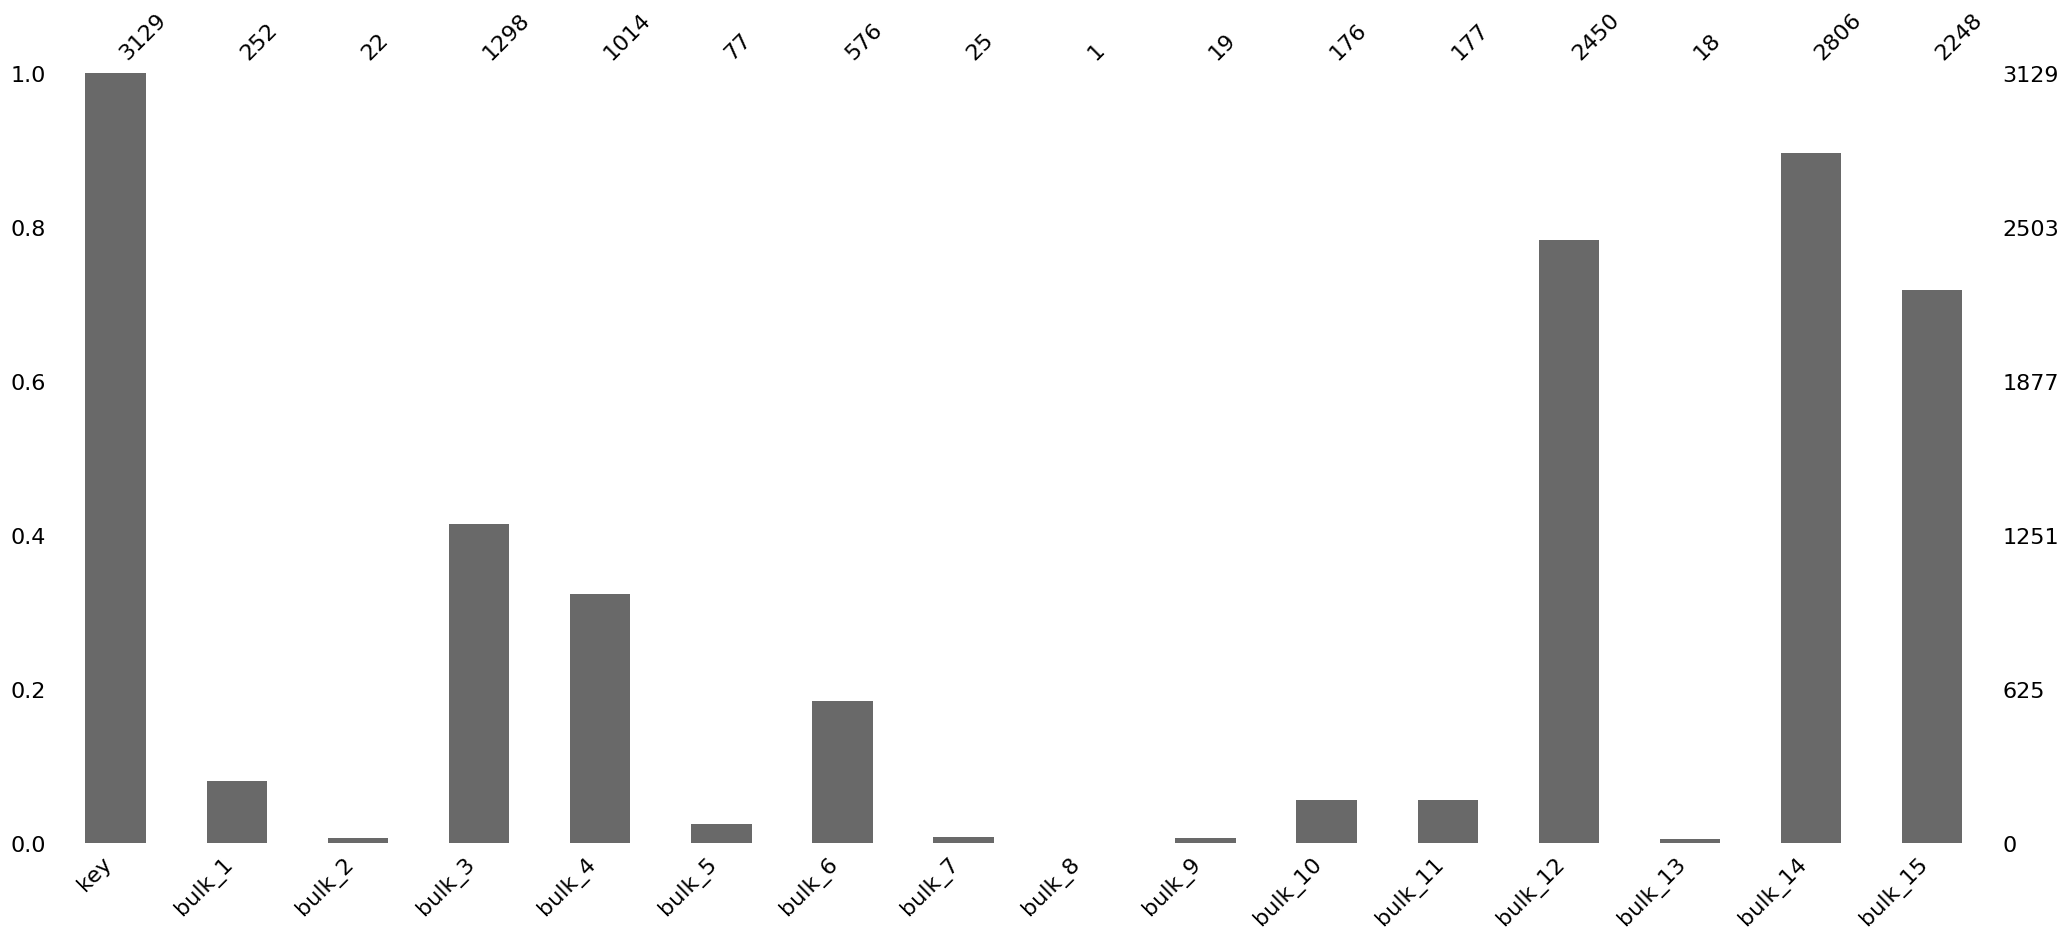

2026-03-04 23:48:48 [INFO] __main__: Характеристики базы данных


,count,mean,std,min,25%,50%,75%,max
key,3129.0,1624.383509,933.337642,1.0,816.0,1622.0,2431.00,3241.0
bulk_1,252.0,39.242063,18.277654,10.0,27.0,31.0,46.00,185.0
bulk_2,22.0,253.045455,21.180578,228.0,242.0,251.5,257.75,325.0
bulk_3,1298.0,113.879045,75.483494,6.0,58.0,97.5,152.00,454.0
bulk_4,1014.0,104.394477,48.184126,12.0,72.0,102.0,133.00,281.0


In [28]:
df_bulk = check_data(df_bulk)

Много пропусков - но это мелочи.  
Заменим на 0, т.к. это просто означает, что не было подачи сыпучего материала.  
Ну и тип данных везде поменять на float  

PS: после первых экспериментов попробуем убрать те загрузки, где больше 50% - пропуски

In [29]:
df_bulk = clear_df_missing_cols(df_bulk)

2026-03-04 23:48:48 [INFO] __main__: Удалено признаков: 5
2026-03-04 23:48:48 [INFO] __main__: Осталось признаков: 11


In [30]:
for col in df_bulk.columns:
    if col != 'key':
        df_bulk[col] = df_bulk[col].astype(float)

In [31]:
df_bulk.describe().T

,count,mean,std,min,25%,50%,75%,max
key,3129.0,1624.383509,933.337642,1.0,816.00,1622.0,2431.00,3241.0
bulk_1,252.0,39.242063,18.277654,10.0,27.00,31.0,46.00,185.0
bulk_3,1298.0,113.879045,75.483494,6.0,58.00,97.5,152.00,454.0
bulk_4,1014.0,104.394477,48.184126,12.0,72.00,102.0,133.00,281.0
bulk_5,77.0,107.025974,81.790646,11.0,70.00,86.0,132.00,603.0
bulk_6,576.0,118.925347,72.057776,17.0,69.75,100.0,157.00,503.0
bulk_10,176.0,83.284091,26.060347,24.0,64.00,86.5,102.00,159.0
bulk_11,177.0,76.819209,59.655365,8.0,25.00,64.0,106.00,313.0
bulk_12,2450.0,260.471020,120.649269,53.0,204.00,208.0,316.00,1849.0
bulk_14,2806.0,170.284747,65.868652,16.0,119.00,151.0,205.75,636.0


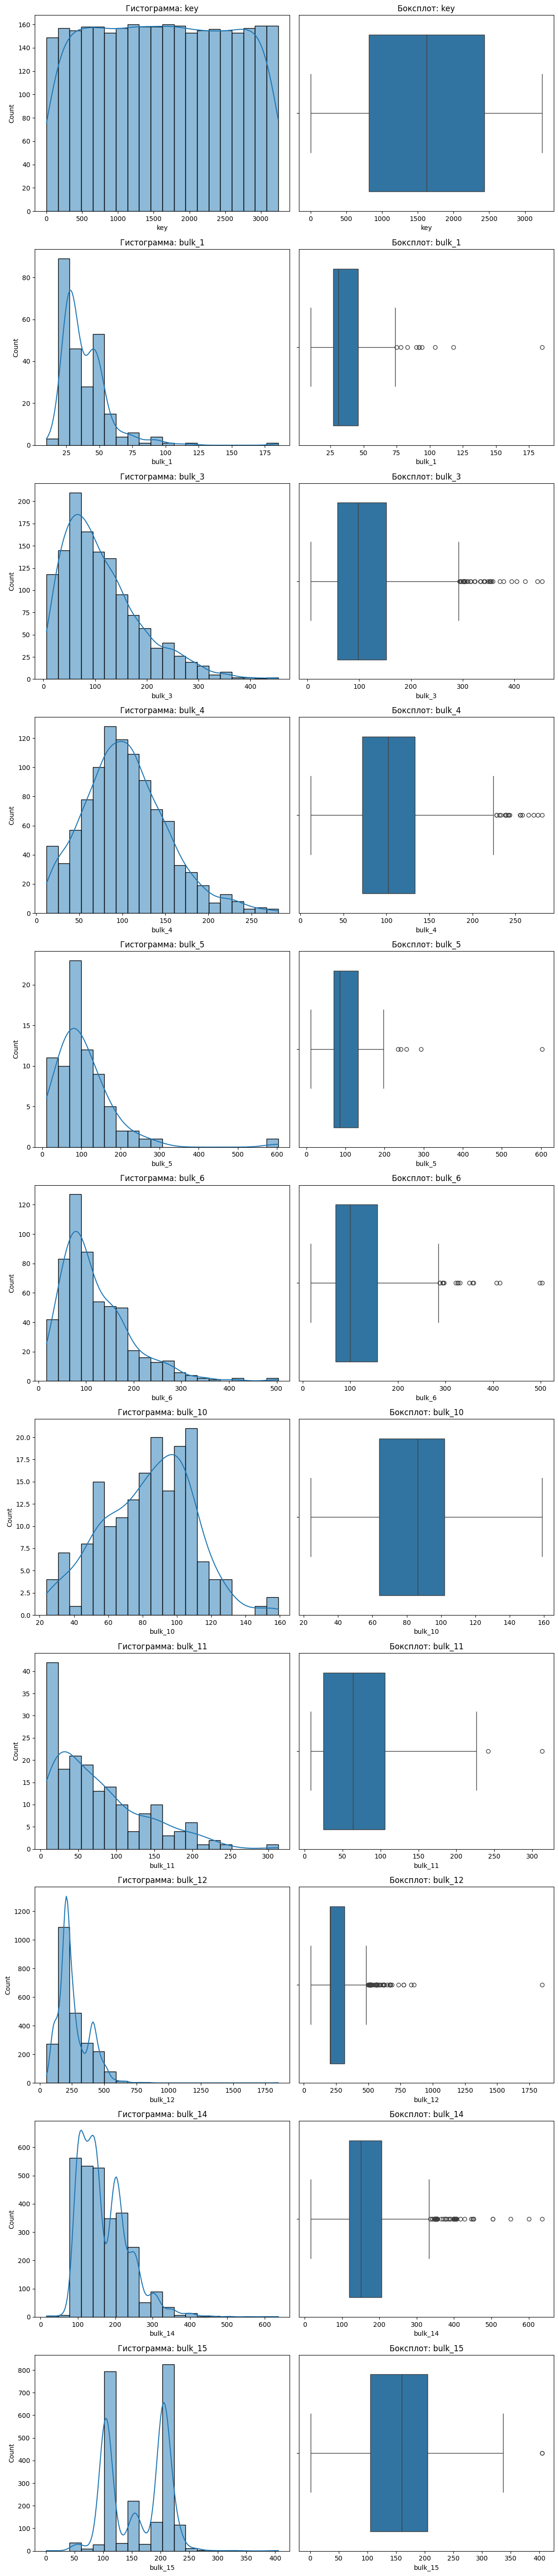

In [32]:
# теперь посмотрим распределение данных
plot_combined(df_bulk, col=None, target=None, col_type=None, legend_loc='best')

Все добавки выше нуля - это главное  
а по числу добавок - сложно понять, что мы добавляем и сколько этого надо...

In [33]:
display(df_bulk.info())
display(df_bulk.head())
display(df_bulk.describe().T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   key      3129 non-null   int64  
 1   bulk_1   252 non-null    float64
 2   bulk_3   1298 non-null   float64
 3   bulk_4   1014 non-null   float64
 4   bulk_5   77 non-null     float64
 5   bulk_6   576 non-null    float64
 6   bulk_10  176 non-null    float64
 7   bulk_11  177 non-null    float64
 8   bulk_12  2450 non-null   float64
 9   bulk_14  2806 non-null   float64
 10  bulk_15  2248 non-null   float64
dtypes: float64(10), int64(1)
memory usage: 269.0 KB


None

,key,bulk_1,bulk_3,bulk_4,bulk_5,bulk_6,bulk_10,bulk_11,bulk_12,bulk_14,bulk_15
0,1,NaN,NaN,43.0,NaN,NaN,NaN,NaN,206.0,150.0,154.0
1,2,NaN,NaN,73.0,NaN,NaN,NaN,NaN,206.0,149.0,154.0
2,3,NaN,NaN,34.0,NaN,NaN,NaN,NaN,205.0,152.0,153.0
3,4,NaN,NaN,81.0,NaN,NaN,NaN,NaN,207.0,153.0,154.0
4,5,NaN,NaN,78.0,NaN,NaN,NaN,NaN,203.0,151.0,152.0


,count,mean,std,min,25%,50%,75%,max
key,3129.0,1624.383509,933.337642,1.0,816.00,1622.0,2431.00,3241.0
bulk_1,252.0,39.242063,18.277654,10.0,27.00,31.0,46.00,185.0
bulk_3,1298.0,113.879045,75.483494,6.0,58.00,97.5,152.00,454.0
bulk_4,1014.0,104.394477,48.184126,12.0,72.00,102.0,133.00,281.0
bulk_5,77.0,107.025974,81.790646,11.0,70.00,86.0,132.00,603.0
bulk_6,576.0,118.925347,72.057776,17.0,69.75,100.0,157.00,503.0
bulk_10,176.0,83.284091,26.060347,24.0,64.00,86.5,102.00,159.0
bulk_11,177.0,76.819209,59.655365,8.0,25.00,64.0,106.00,313.0
bulk_12,2450.0,260.471020,120.649269,53.0,204.00,208.0,316.00,1849.0
bulk_14,2806.0,170.284747,65.868652,16.0,119.00,151.0,205.75,636.0


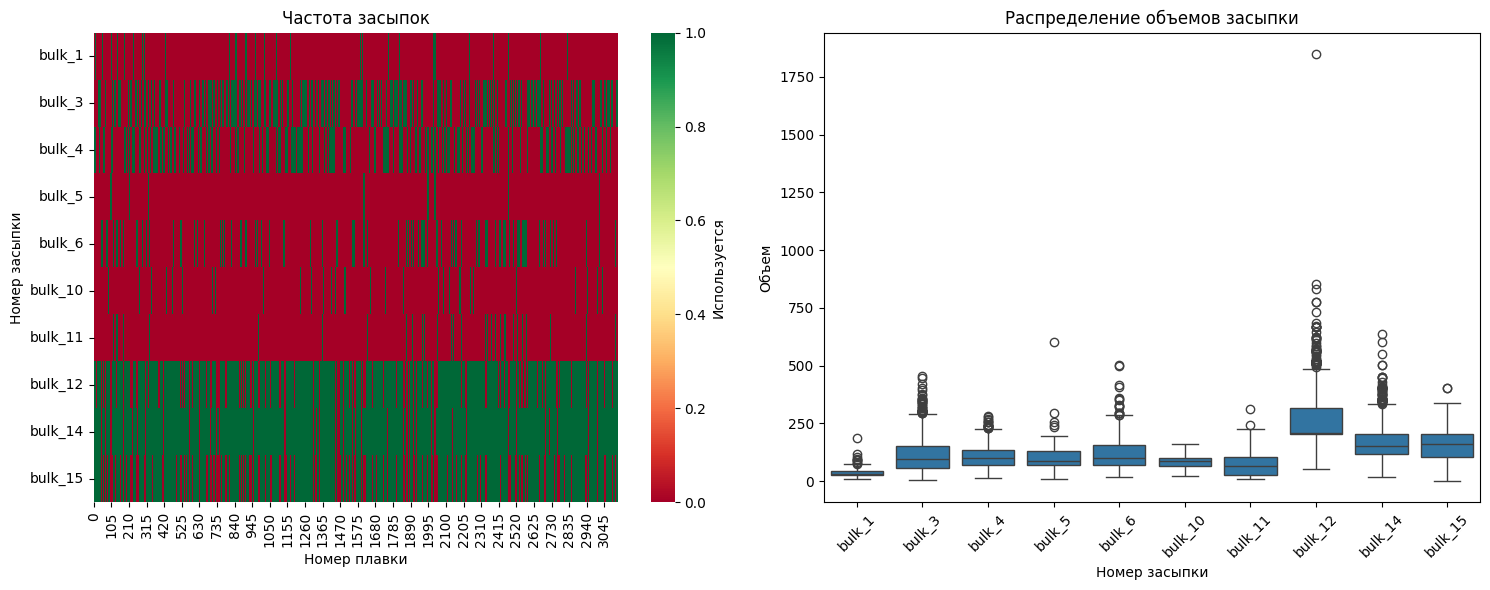

In [34]:
bulk_cols = [col for col in df_bulk.columns if col.startswith('bulk_')]
bulk_cols = sorted(bulk_cols, key=lambda x: int(x.split('_')[1]))

if len(bulk_cols) == 0:
    logger.warning("Нет колонок bulk_ для построения графиков. Пропускаем визуализацию.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Тепловая карта засыпок
    usage_matrix = pd.DataFrame({col: (df_bulk[col] > 0).astype(int) for col in bulk_cols})
    sns.heatmap(usage_matrix.T, cmap='RdYlGn', cbar_kws={'label': 'Используется'}, ax=axes[0])
    axes[0].set_title('Частота засыпок')
    axes[0].set_xlabel('Номер плавки')
    axes[0].set_ylabel('Номер засыпки')

    # Распределение объемов
    data_for_box = df_bulk[bulk_cols].melt(var_name='Номер засыпки', value_name='Объем')
    data_for_box = data_for_box[data_for_box['Объем'] > 0]
    if data_for_box.empty:
        logger.warning("Нет ненулевых объемов для boxplot.")
    else:
        sns.boxplot(data=data_for_box, x='Номер засыпки', y='Объем', ax=axes[1])
        axes[1].set_title('Распределение объемов засыпки')
        axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

Посмотрим отдельно на выброс засыпки в номере 12  
Именно номер плавки по порядку, непонятно

In [35]:
df_bulk.head()

,key,bulk_1,bulk_3,bulk_4,bulk_5,bulk_6,bulk_10,bulk_11,bulk_12,bulk_14,bulk_15
0,1,NaN,NaN,43.0,NaN,NaN,NaN,NaN,206.0,150.0,154.0
1,2,NaN,NaN,73.0,NaN,NaN,NaN,NaN,206.0,149.0,154.0
2,3,NaN,NaN,34.0,NaN,NaN,NaN,NaN,205.0,152.0,153.0
3,4,NaN,NaN,81.0,NaN,NaN,NaN,NaN,207.0,153.0,154.0
4,5,NaN,NaN,78.0,NaN,NaN,NaN,NaN,203.0,151.0,152.0


In [36]:
display(df_bulk[df_bulk['bulk_12'] > 600])

,key,bulk_1,bulk_3,bulk_4,bulk_5,bulk_6,bulk_10,bulk_11,bulk_12,bulk_14,bulk_15
11,12,46.0,NaN,34.0,NaN,NaN,NaN,NaN,618.0,406.0,203.0
207,223,NaN,124.0,NaN,NaN,NaN,NaN,NaN,666.0,316.0,202.0
303,322,185.0,101.0,58.0,NaN,NaN,NaN,NaN,1849.0,636.0,NaN
308,327,67.0,NaN,119.0,NaN,NaN,NaN,NaN,775.0,403.0,205.0
418,444,52.0,NaN,115.0,NaN,NaN,NaN,NaN,671.0,379.0,203.0
841,877,90.0,NaN,NaN,NaN,NaN,85.0,NaN,669.0,102.0,NaN
960,1005,31.0,147.0,NaN,NaN,NaN,NaN,NaN,668.0,198.0,205.0
1005,1050,46.0,NaN,NaN,NaN,109.0,NaN,29.0,647.0,371.0,103.0
1175,1224,31.0,NaN,NaN,NaN,NaN,NaN,NaN,668.0,213.0,NaN
1240,1290,44.0,61.0,65.0,NaN,NaN,NaN,NaN,609.0,275.0,158.0


Непонятно все равно, может быть и есть в этом какая-то логика, но мне она отсюда не видна.  
Лучше сделаем новые фичи:  
1) Суммарный объем засыпок;  
2) Число засыпок;  

In [37]:
bulk_cols = [col for col in df_bulk.columns if 'bulk_' in col.lower()]
df_bulk['total_bulk'] = df_bulk[bulk_cols].sum(axis=1)

In [38]:
df_bulk['count_bulk'] = df_bulk[bulk_cols].count(axis=1)

In [39]:
df_bulk.head()

,key,bulk_1,bulk_3,bulk_4,bulk_5,bulk_6,bulk_10,bulk_11,bulk_12,bulk_14,bulk_15,total_bulk,count_bulk
0,1,NaN,NaN,43.0,NaN,NaN,NaN,NaN,206.0,150.0,154.0,553.0,4
1,2,NaN,NaN,73.0,NaN,NaN,NaN,NaN,206.0,149.0,154.0,582.0,4
2,3,NaN,NaN,34.0,NaN,NaN,NaN,NaN,205.0,152.0,153.0,544.0,4
3,4,NaN,NaN,81.0,NaN,NaN,NaN,NaN,207.0,153.0,154.0,595.0,4
4,5,NaN,NaN,78.0,NaN,NaN,NaN,NaN,203.0,151.0,152.0,584.0,4


2026-03-04 23:48:51 [INFO] matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-04 23:48:51 [INFO] matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


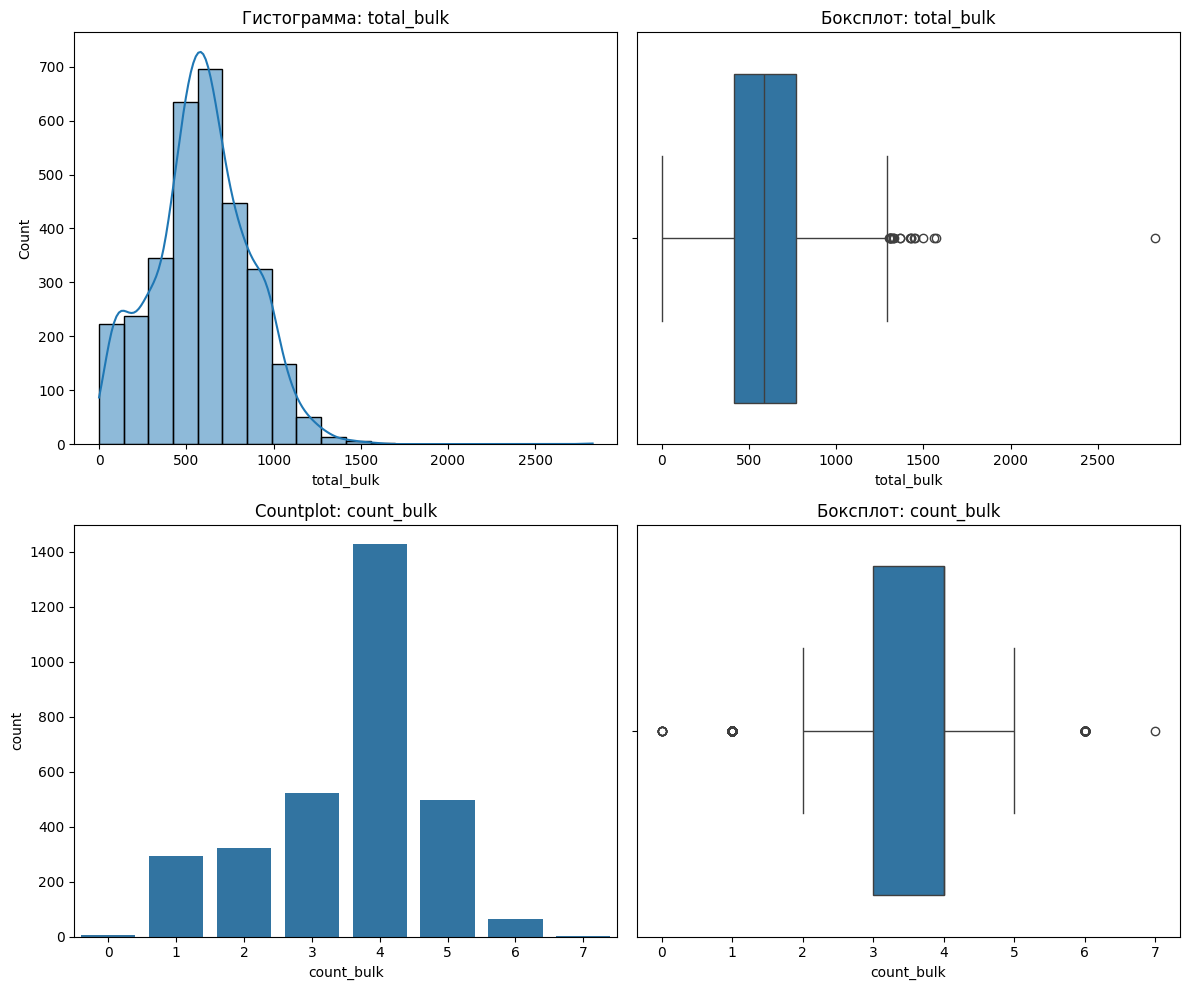

In [40]:
# и посмотрим что вышло
cols = ['total_bulk', 'count_bulk']
plot_combined(df_bulk, col=cols, target=None, col_type=None, legend_loc='best')

In [41]:
# df_bulk = df_bulk.fillna(0)

##### df_bulk_time

2026-03-04 23:48:51 [INFO] __main__: Общая информация базы данных


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   key      3129 non-null   int64 
 1   bulk_1   252 non-null    object
 2   bulk_2   22 non-null     object
 3   bulk_3   1298 non-null   object
 4   bulk_4   1014 non-null   object
 5   bulk_5   77 non-null     object
 6   bulk_6   576 non-null    object
 7   bulk_7   25 non-null     object
 8   bulk_8   1 non-null      object
 9   bulk_9   19 non-null     object
 10  bulk_10  176 non-null    object
 11  bulk_11  177 non-null    object
 12  bulk_12  2450 non-null   object
 13  bulk_13  18 non-null     object
 14  bulk_14  2806 non-null   object
 15  bulk_15  2248 non-null   object
dtypes: int64(1), object(15)
memory usage: 391.3+ KB


None

2026-03-04 23:48:51 [INFO] __main__: 5 случайных строк


,key,bulk_1,bulk_2,bulk_3,bulk_4,bulk_5,bulk_6,bulk_7,bulk_8,bulk_9,bulk_10,bulk_11,bulk_12,bulk_13,bulk_14,bulk_15
2982,3091,None,None,2019-09-01 12:41:21,None,None,None,None,None,None,None,None,2019-09-01 13:05:04,None,2019-09-01 13:01:59,2019-09-01 12:54:04
2983,3092,None,None,2019-09-01 13:43:43,None,None,None,None,None,None,None,None,2019-09-01 13:43:43,None,2019-09-01 14:08:40,2019-09-01 13:47:59
566,595,None,None,None,2019-05-26 01:51:47,None,None,None,None,None,None,None,2019-05-26 01:43:21,None,2019-05-26 01:32:23,2019-05-26 01:20:34
408,434,None,None,None,2019-05-20 00:24:11,None,None,None,None,None,None,None,2019-05-20 00:20:42,None,2019-05-20 00:14:10,2019-05-19 23:52:20
1355,1408,2019-06-25 11:36:24,None,2019-06-25 11:36:24,None,None,None,None,None,None,None,None,2019-06-25 11:36:24,None,2019-06-25 11:27:34,2019-06-25 11:13:15


2026-03-04 23:48:51 [INFO] __main__: Число пропусков в базе данных


bulk_1     2877
bulk_2     3107
bulk_3     1831
bulk_4     2115
bulk_5     3052
bulk_6     2553
bulk_7     3104
bulk_8     3128
bulk_9     3110
bulk_10    2953
bulk_11    2952
bulk_12     679
bulk_13    3111
bulk_14     323
bulk_15     881
dtype: int64

None

2026-03-04 23:48:51 [INFO] __main__: Визуализация пропусков


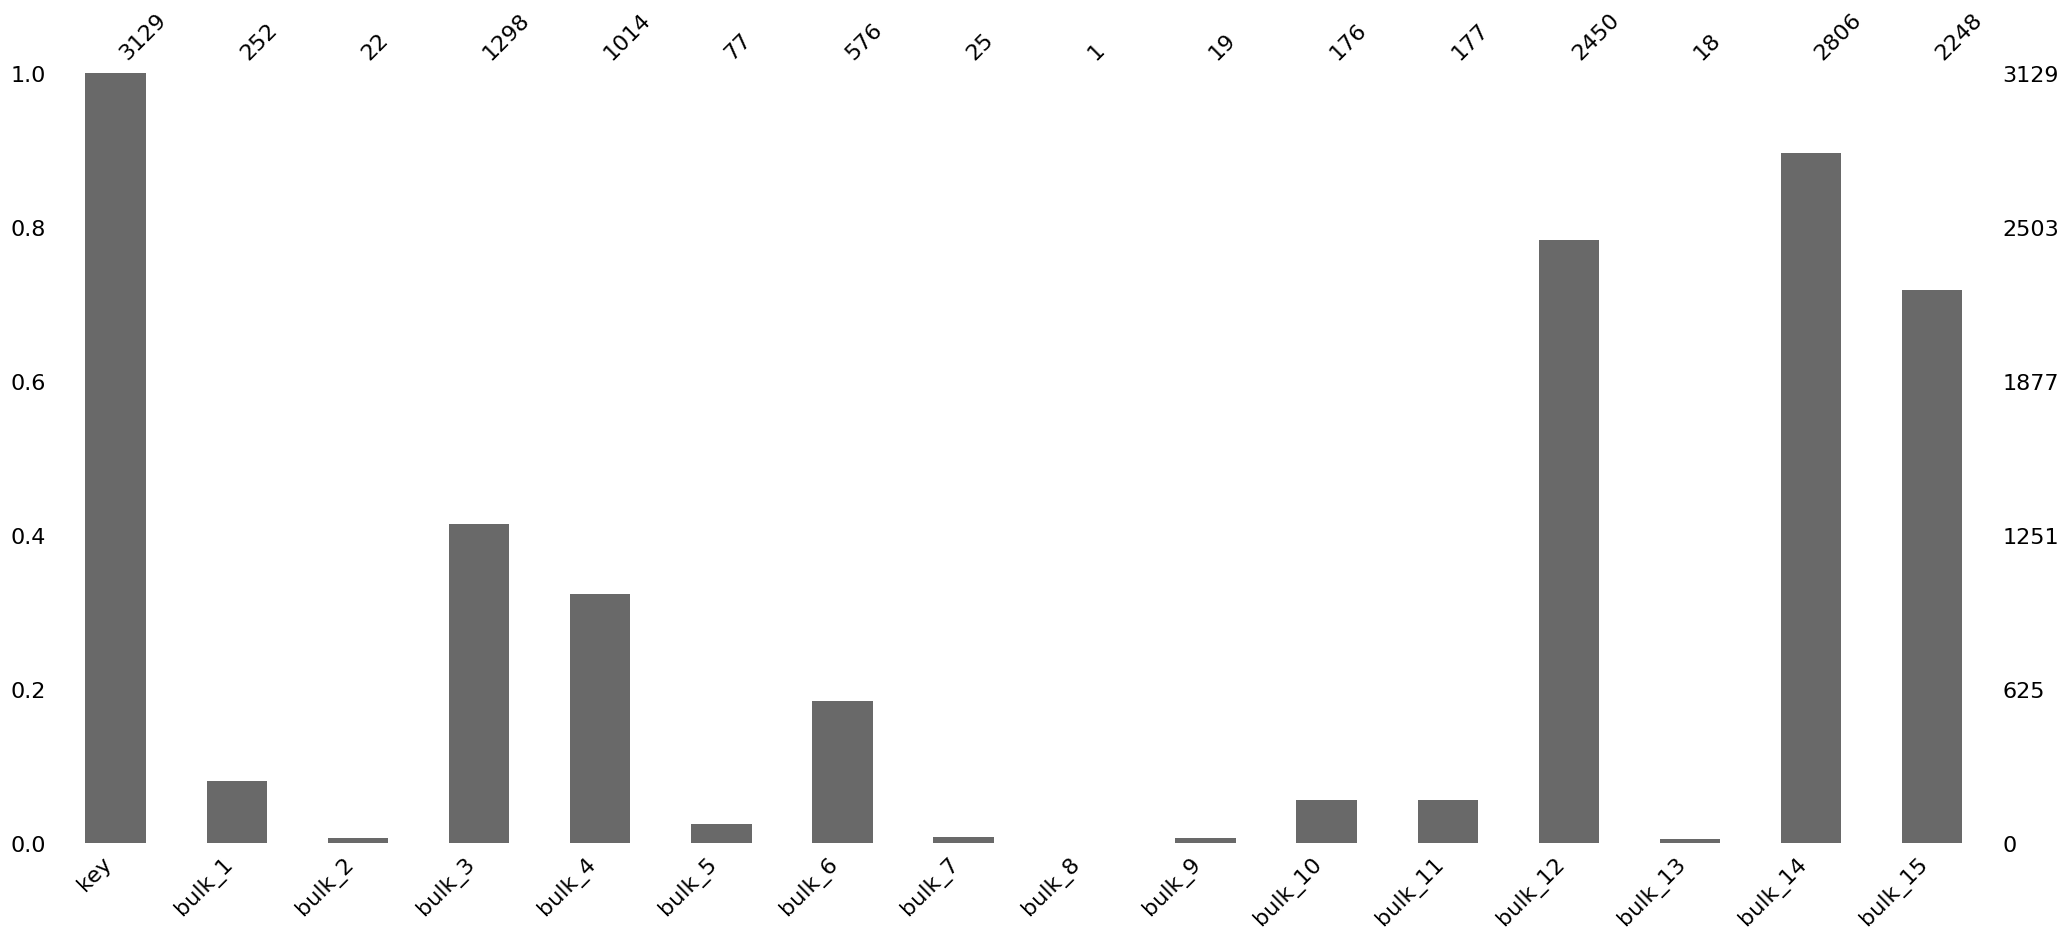

2026-03-04 23:48:52 [INFO] __main__: Характеристики базы данных


,count,mean,std,min,25%,50%,75%,max
key,3129.0,1624.383509,933.337642,1.0,816.0,1622.0,2431.0,3241.0


In [42]:
df_bulk_time = check_data(df_bulk_time)

Аналогично и тут пропуски - время подачи, т.к. не было подачи по факту то и не было фиксации времени  
Здесь видимо пропуски будут NaT

In [43]:
df_bulk_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   key      3129 non-null   int64 
 1   bulk_1   252 non-null    object
 2   bulk_2   22 non-null     object
 3   bulk_3   1298 non-null   object
 4   bulk_4   1014 non-null   object
 5   bulk_5   77 non-null     object
 6   bulk_6   576 non-null    object
 7   bulk_7   25 non-null     object
 8   bulk_8   1 non-null      object
 9   bulk_9   19 non-null     object
 10  bulk_10  176 non-null    object
 11  bulk_11  177 non-null    object
 12  bulk_12  2450 non-null   object
 13  bulk_13  18 non-null     object
 14  bulk_14  2806 non-null   object
 15  bulk_15  2248 non-null   object
dtypes: int64(1), object(15)
memory usage: 391.3+ KB


In [44]:
df_bulk_time.head()

,key,bulk_1,bulk_2,bulk_3,bulk_4,bulk_5,bulk_6,bulk_7,bulk_8,bulk_9,bulk_10,bulk_11,bulk_12,bulk_13,bulk_14,bulk_15
0,1,None,None,None,2019-05-03 11:28:48,None,None,None,None,None,None,None,2019-05-03 11:24:31,None,2019-05-03 11:14:50,2019-05-03 11:10:43
1,2,None,None,None,2019-05-03 11:36:50,None,None,None,None,None,None,None,2019-05-03 11:53:30,None,2019-05-03 11:48:37,2019-05-03 11:44:39
2,3,None,None,None,2019-05-03 12:32:39,None,None,None,None,None,None,None,2019-05-03 12:27:13,None,2019-05-03 12:21:01,2019-05-03 12:16:16
3,4,None,None,None,2019-05-03 12:43:22,None,None,None,None,None,None,None,2019-05-03 12:58:00,None,2019-05-03 12:51:11,2019-05-03 12:46:36
4,5,None,None,None,2019-05-03 13:30:47,None,None,None,None,None,None,None,2019-05-03 13:30:47,None,2019-05-03 13:34:12,2019-05-03 13:30:47


Интересное наблюдение, отсчет идет с последней засыпке к 1й...   
Ну да пусть, нам бы посчитать суммарное время  

In [45]:
df_bulk_time = clear_df_missing_cols(df_bulk_time)

2026-03-04 23:48:52 [INFO] __main__: Удалено признаков: 5
2026-03-04 23:48:52 [INFO] __main__: Осталось признаков: 11


In [46]:
df_bulk_time

,key,bulk_1,bulk_3,bulk_4,bulk_5,bulk_6,bulk_10,bulk_11,bulk_12,bulk_14,bulk_15
0,1,None,None,2019-05-03 11:28:48,None,None,None,None,2019-05-03 11:24:31,2019-05-03 11:14:50,2019-05-03 11:10:43
1,2,None,None,2019-05-03 11:36:50,None,None,None,None,2019-05-03 11:53:30,2019-05-03 11:48:37,2019-05-03 11:44:39
2,3,None,None,2019-05-03 12:32:39,None,None,None,None,2019-05-03 12:27:13,2019-05-03 12:21:01,2019-05-03 12:16:16
3,4,None,None,2019-05-03 12:43:22,None,None,None,None,2019-05-03 12:58:00,2019-05-03 12:51:11,2019-05-03 12:46:36
4,5,None,None,2019-05-03 13:30:47,None,None,None,None,2019-05-03 13:30:47,2019-05-03 13:34:12,2019-05-03 13:30:47
...,...,...,...,...,...,...,...,...,...,...,...
3124,3237,None,2019-09-06 11:54:15,None,None,None,None,None,2019-09-06 11:49:45,2019-09-06 11:45:22,2019-09-06 11:40:06
3125,3238,None,2019-09-06 12:26:52,None,None,None,None,None,2019-09-06 12:18:35,2019-09-06 12:31:49,2019-09-06 12:26:52
3126,3239,None,None,None,None,2019-09-06 15:06:00,None,None,2019-09-06 15:01:44,2019-09-06 14:58:15,2019-09-06 14:48:06
3127,3240,None,None,None,None,2019-09-06 16:24:28,None,None,None,2019-09-06 16:07:29,2019-09-06 16:01:34


In [47]:
bulk_time_cols = [col for col in df_bulk_time.columns if 'bulk_' in col.lower()]
df_bulk_time[bulk_time_cols] = df_bulk_time[bulk_time_cols].astype('datetime64[ns]')

In [48]:
df_bulk_time['начало_засыпок'] = df_bulk_time[bulk_time_cols].min(axis=1)
df_bulk_time['конец_засыпок'] = df_bulk_time[bulk_time_cols].max(axis=1)
df_bulk_time['общее_время_засыпок'] = (df_bulk_time['конец_засыпок'] - df_bulk_time['начало_засыпок']).dt.total_seconds()

In [49]:
# ну и средний интервал между подачами заодно

df_bulk_time['интервал_подачи_avg'] = (
    df_bulk_time[bulk_time_cols]
    .apply(lambda row: row.dropna().sort_values().diff().dt.total_seconds().mean(), axis=1)
)

In [50]:
display(df_bulk_time.head())
display(df_bulk_time.info())
display(df_bulk_time.describe().T)

,key,bulk_1,bulk_3,bulk_4,bulk_5,bulk_6,bulk_10,bulk_11,bulk_12,bulk_14,bulk_15,начало_засыпок,конец_засыпок,общее_время_засыпок,интервал_подачи_avg
0,1,NaT,NaT,2019-05-03 11:28:48,NaT,NaT,NaT,NaT,2019-05-03 11:24:31,2019-05-03 11:14:50,2019-05-03 11:10:43,2019-05-03 11:10:43,2019-05-03 11:28:48,1085.0,361.666667
1,2,NaT,NaT,2019-05-03 11:36:50,NaT,NaT,NaT,NaT,2019-05-03 11:53:30,2019-05-03 11:48:37,2019-05-03 11:44:39,2019-05-03 11:36:50,2019-05-03 11:53:30,1000.0,333.333333
2,3,NaT,NaT,2019-05-03 12:32:39,NaT,NaT,NaT,NaT,2019-05-03 12:27:13,2019-05-03 12:21:01,2019-05-03 12:16:16,2019-05-03 12:16:16,2019-05-03 12:32:39,983.0,327.666667
3,4,NaT,NaT,2019-05-03 12:43:22,NaT,NaT,NaT,NaT,2019-05-03 12:58:00,2019-05-03 12:51:11,2019-05-03 12:46:36,2019-05-03 12:43:22,2019-05-03 12:58:00,878.0,292.666667
4,5,NaT,NaT,2019-05-03 13:30:47,NaT,NaT,NaT,NaT,2019-05-03 13:30:47,2019-05-03 13:34:12,2019-05-03 13:30:47,2019-05-03 13:30:47,2019-05-03 13:34:12,205.0,68.333333


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   key                  3129 non-null   int64         
 1   bulk_1               252 non-null    datetime64[ns]
 2   bulk_3               1298 non-null   datetime64[ns]
 3   bulk_4               1014 non-null   datetime64[ns]
 4   bulk_5               77 non-null     datetime64[ns]
 5   bulk_6               576 non-null    datetime64[ns]
 6   bulk_10              176 non-null    datetime64[ns]
 7   bulk_11              177 non-null    datetime64[ns]
 8   bulk_12              2450 non-null   datetime64[ns]
 9   bulk_14              2806 non-null   datetime64[ns]
 10  bulk_15              2248 non-null   datetime64[ns]
 11  начало_засыпок       3122 non-null   datetime64[ns]
 12  конец_засыпок        3122 non-null   datetime64[ns]
 13  общее_время_засыпок  3122 non-nul

None

,count,mean,min,25%,50%,75%,max,std
key,3129.0,1624.383509,1.0,816.0,1622.0,2431.0,3241.0,933.337642
bulk_1,252,2019-06-29 23:24:44.769841152,2019-05-03 17:42:46,2019-05-29 14:48:48.500000,2019-06-25 11:09:13,2019-07-31 05:58:18.249999872,2019-09-05 09:11:32,NaN
bulk_3,1298,2019-07-08 13:50:14.630970624,2019-05-03 20:40:25,2019-06-08 03:50:23.500000,2019-07-04 09:31:42,2019-08-11 01:00:36.750000128,2019-09-06 12:26:52,NaN
bulk_4,1014,2019-07-03 11:17:28.834319616,2019-05-03 11:28:48,2019-05-30 21:36:11.249999872,2019-06-28 03:44:42.500000,2019-08-04 04:15:46.500000,2019-09-05 03:35:21,NaN
bulk_5,77,2019-07-13 17:18:29.090908928,2019-05-07 15:19:17,2019-06-19 23:32:44,2019-07-25 17:59:41,2019-08-13 04:23:23,2019-09-02 18:16:52,NaN
bulk_6,576,2019-07-06 13:50:06.345486080,2019-05-03 19:09:15,2019-06-06 22:46:10.500000,2019-07-09 03:34:57.500000,2019-08-07 18:55:01.249999872,2019-09-06 16:24:28,NaN
bulk_10,176,2019-07-06 23:55:10.954545408,2019-05-06 07:54:02,2019-06-02 05:12:00.500000,2019-07-06 07:05:20,2019-08-04 02:23:35.750000128,2019-09-04 10:03:22,NaN
bulk_11,177,2019-07-15 07:01:00.615819264,2019-05-05 23:43:24,2019-06-14 20:24:48,2019-07-24 11:17:22,2019-08-11 05:21:01,2019-09-06 05:03:14,NaN
bulk_12,2450,2019-07-05 22:55:11.468571392,2019-05-03 11:24:31,2019-06-03 12:48:47.249999872,2019-07-03 01:32:00,2019-08-08 14:55:05.249999872,2019-09-06 15:01:44,NaN
bulk_14,2806,2019-07-06 07:17:48.372772608,2019-05-03 11:14:50,2019-06-04 04:50:42,2019-07-03 21:54:13.500000,2019-08-09 04:22:40.500000,2019-09-06 17:26:33,NaN


Вылезла неадекватная продолжительность подачи, посмотрим поближе

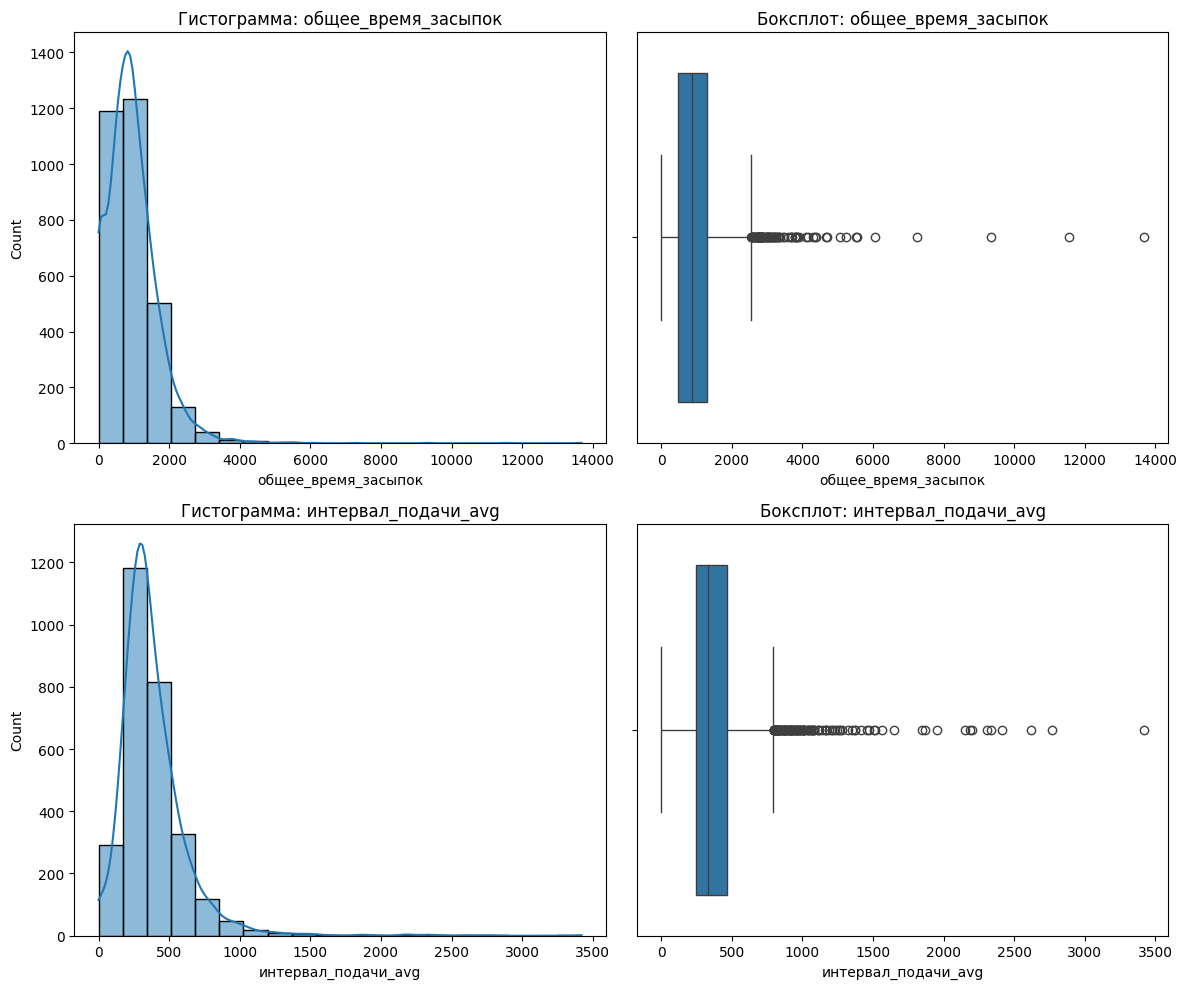

In [51]:
# и посмотрим что вышло
cols = ['общее_время_засыпок', 'интервал_подачи_avg']
plot_combined(df_bulk_time, col=cols, target=None, col_type=None, legend_loc='best')

##### df_gas

In [52]:
df_gas = check_data(df_gas)

2026-03-04 23:48:53 [INFO] __main__: Общая информация базы данных


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3239 entries, 0 to 3238
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3239 non-null   int64  
 1   газ_1   3239 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 50.7 KB


None

2026-03-04 23:48:53 [INFO] __main__: 5 случайных строк


,key,газ_1
258,261,13.403258
2530,2533,7.542188
1886,1889,10.586564
866,869,14.453072
1988,1991,11.145643


2026-03-04 23:48:53 [INFO] __main__: Число пропусков в базе данных


Series([], dtype: int64)

None

2026-03-04 23:48:53 [INFO] __main__: Характеристики базы данных


,count,mean,std,min,25%,50%,75%,max
key,3239.0,1621.861377,935.386334,1.000000,812.500000,1622.000000,2431.500000,3241.00000
газ_1,3239.0,11.002062,6.220327,0.008399,7.043089,9.836267,13.769915,77.99504


Тут на первый взгляд все у нас хорошо  
но посмотрим и на график

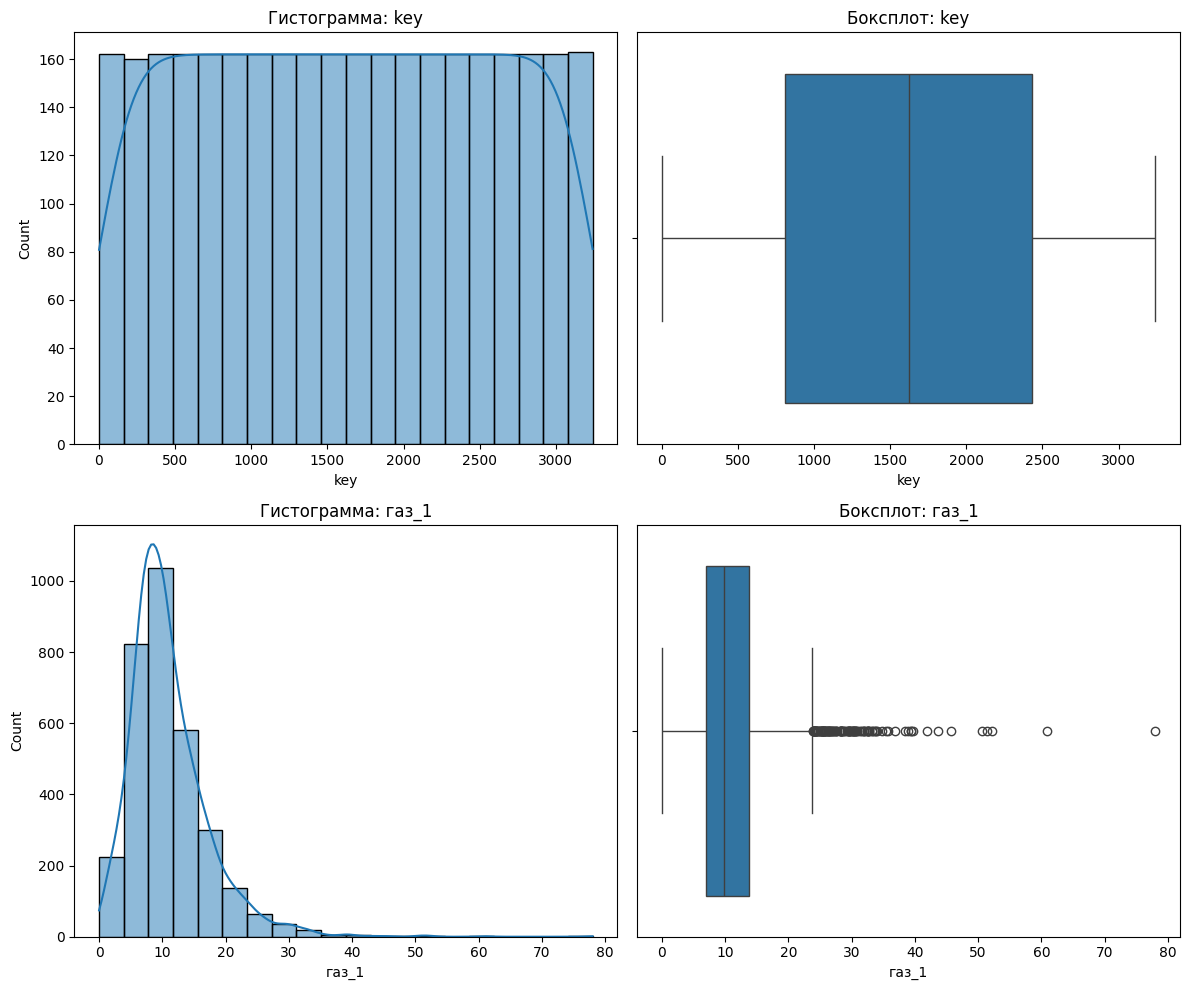

In [53]:
plot_combined(df_gas, col=None, target=None, col_type=None, legend_loc='best')

Не такой больше различие у максимума, но все равно посмотрим на бОльшие значения

In [54]:
display(df_gas[df_gas['газ_1'] > 50])

,key,газ_1
116,117,50.581035
277,280,60.935689
319,322,77.995040
2107,2110,52.142373
2567,2570,51.380229


Ну дали чутка больше газа и ладно, бывает

##### df_temp

2026-03-04 23:48:54 [INFO] __main__: Общая информация базы данных


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18092 entries, 0 to 18091
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   key           18092 non-null  int64 
 1   время_замера  18092 non-null  object
 2   температура   14665 non-null  object
dtypes: int64(1), object(2)
memory usage: 424.2+ KB


None

2026-03-04 23:48:54 [INFO] __main__: 5 случайных строк


,key,время_замера,температура
8430,1508,2019-06-29 02:22:50,1564.0
8107,1452,2019-06-27 00:52:23,1614.0
5680,1012,2019-06-11 12:36:41,1577.0
14753,2638,2019-08-15 18:20:15,None
12188,2173,2019-07-30 01:00:56,1600.0


2026-03-04 23:48:54 [INFO] __main__: Число пропусков в базе данных


температура    3427
dtype: int64

None

2026-03-04 23:48:54 [INFO] __main__: Визуализация пропусков


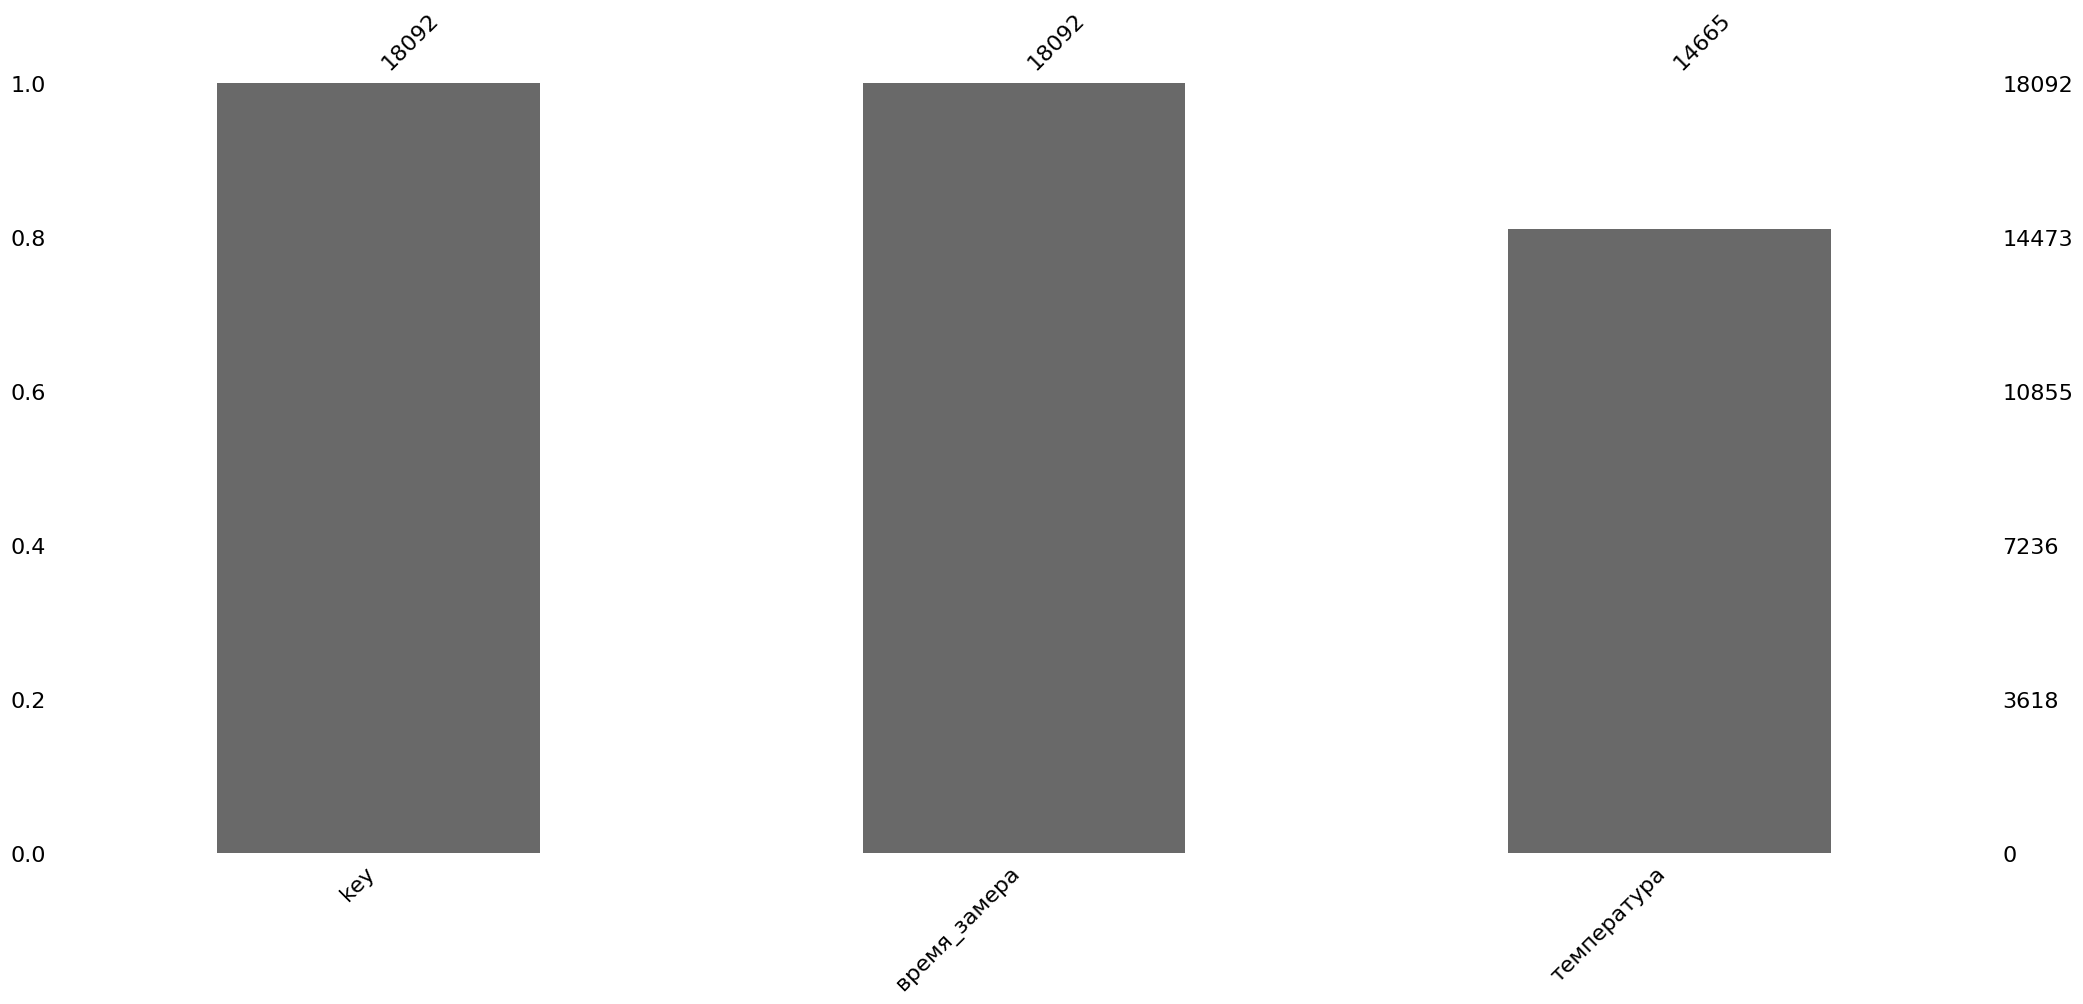

2026-03-04 23:48:54 [INFO] __main__: Характеристики базы данных


,count,mean,std,min,25%,50%,75%,max
key,18092.0,1616.460977,934.641385,1.0,807.75,1618.0,2429.0,3241.0


In [55]:
df_temp = check_data(df_temp)

У времени сделать нормальный тип данных  
Пропуски мы не сможем адекватно скорректировать  
Как эксперимент можем взять два соседних тайминга и просто взять среднюю между этими числами, критической проблемы тут быть не должно  
PS: изучив данные мы видим, что там на каждый key только один замер температур

In [56]:
# df_temp['температура'] = df_temp['температура'].fillna(-1).astype('float64')
df_temp['температура'] = df_temp['температура'].astype('float64')

In [57]:
df_temp['время_замера'] = df_temp['время_замера'].astype('datetime64[ns]')

In [58]:
df_temp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18092 entries, 0 to 18091
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   key           18092 non-null  int64         
 1   время_замера  18092 non-null  datetime64[ns]
 2   температура   14665 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 424.2 KB


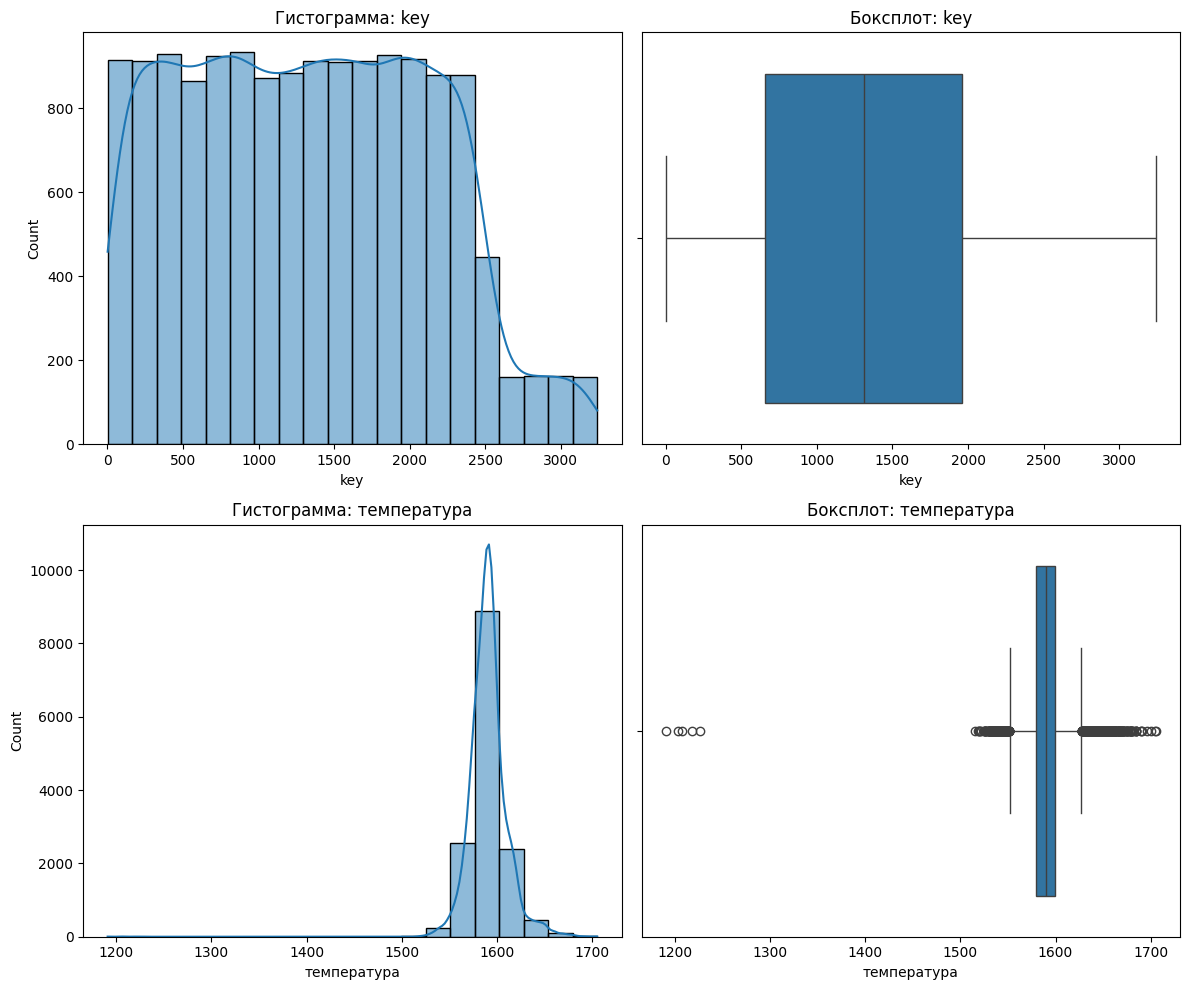

In [59]:
temp_df_temp = df_temp[df_temp['температура'] > 0]
plot_combined(temp_df_temp, col=None, target=None, col_type=None, legend_loc='best')

In [60]:
temp_df_temp.describe().T

,count,mean,min,25%,50%,75%,max,std
key,14665.0,1325.484214,1.0,654.0,1314.0,1963.0,3241.0,787.375969
время_замера,14665,2019-06-23 23:59:11.606341632,2019-05-03 11:02:04,2019-05-28 23:56:49,2019-06-21 22:55:49,2019-07-21 22:58:20,2019-09-06 16:48:55,NaN
температура,14665.0,1590.722741,1191.0,1580.0,1590.0,1599.0,1705.0,20.394381


В целом распределение температур выглядит адекватно

Что касается задания -  
1) таргет - последняя температура партии  
2) можно брать только те позиции, где есть начальная и конечная температура, т.е. минимум 2 позиции  
3) промежуточные - не брать, это утечка данных  
4) температура ниже 1500 - аномалия

In [61]:
# посмотрим исходя из вводных от заказчика
# уберем сразу аномалии
df_temp = df_temp[df_temp['температура'] >= 1500]

Находим ключи, у которых 2 и более записей, т.к. это требования по ТЗ

In [62]:
valid_keys = df_temp.groupby('key').size()
valid_keys = valid_keys[valid_keys >= 2].index

df_temp_filtered = df_temp[df_temp['key'].isin(valid_keys)]

df_temp_agg = df_temp_filtered.groupby('key').agg(
    время_первого_замера=('время_замера', 'min'),
    время_последнего_замера=('время_замера', 'max'),
    стартовая_температура=('температура', 'min'),
    конечная_температура=('температура', 'max')
).reset_index()

display(df_temp_agg.head())

,key,время_первого_замера,время_последнего_замера,стартовая_температура,конечная_температура
0,1,2019-05-03 11:02:04,2019-05-03 11:30:38,1571.0,1618.0
1,2,2019-05-03 11:34:04,2019-05-03 11:55:09,1577.0,1604.0
2,3,2019-05-03 12:06:44,2019-05-03 12:35:57,1596.0,1600.0
3,4,2019-05-03 12:39:27,2019-05-03 12:59:47,1601.0,1625.0
4,5,2019-05-03 13:11:03,2019-05-03 13:36:39,1576.0,1602.0


In [63]:
df_temp = df_temp_agg
display(df_temp)

,key,время_первого_замера,время_последнего_замера,стартовая_температура,конечная_температура
0,1,2019-05-03 11:02:04,2019-05-03 11:30:38,1571.0,1618.0
1,2,2019-05-03 11:34:04,2019-05-03 11:55:09,1577.0,1604.0
2,3,2019-05-03 12:06:44,2019-05-03 12:35:57,1596.0,1600.0
3,4,2019-05-03 12:39:27,2019-05-03 12:59:47,1601.0,1625.0
4,5,2019-05-03 13:11:03,2019-05-03 13:36:39,1576.0,1602.0
...,...,...,...,...,...
2470,2495,2019-08-10 11:27:47,2019-08-10 11:50:47,1570.0,1591.0
2471,2496,2019-08-10 11:56:48,2019-08-10 12:25:13,1554.0,1595.0
2472,2497,2019-08-10 12:37:26,2019-08-10 12:53:28,1571.0,1589.0
2473,2498,2019-08-10 12:58:11,2019-08-10 13:23:31,1570.0,1594.0


##### df_wire

2026-03-04 23:48:55 [INFO] __main__: Общая информация базы данных


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3081 non-null   int64  
 1   wire_1  3055 non-null   float64
 2   wire_2  1079 non-null   object 
 3   wire_3  63 non-null     object 
 4   wire_4  14 non-null     object 
 5   wire_5  1 non-null      object 
 6   wire_6  73 non-null     object 
 7   wire_7  11 non-null     object 
 8   wire_8  19 non-null     object 
 9   wire_9  29 non-null     object 
dtypes: float64(1), int64(1), object(8)
memory usage: 240.8+ KB


None

2026-03-04 23:48:55 [INFO] __main__: 5 случайных строк


,key,wire_1,wire_2,wire_3,wire_4,wire_5,wire_6,wire_7,wire_8,wire_9
2729,2882,39.049923,15.14032,None,None,None,None,None,None,None
1586,1666,85.222801,117.322395,None,None,None,None,None,None,None
503,537,100.011597,None,None,None,None,None,None,None,None
273,296,168.080642,None,None,None,None,None,None,None,None
2891,3050,85.088638,None,None,None,None,None,None,None,None


2026-03-04 23:48:55 [INFO] __main__: Число пропусков в базе данных


wire_1      26
wire_2    2002
wire_3    3018
wire_4    3067
wire_5    3080
wire_6    3008
wire_7    3070
wire_8    3062
wire_9    3052
dtype: int64

None

2026-03-04 23:48:55 [INFO] __main__: Визуализация пропусков


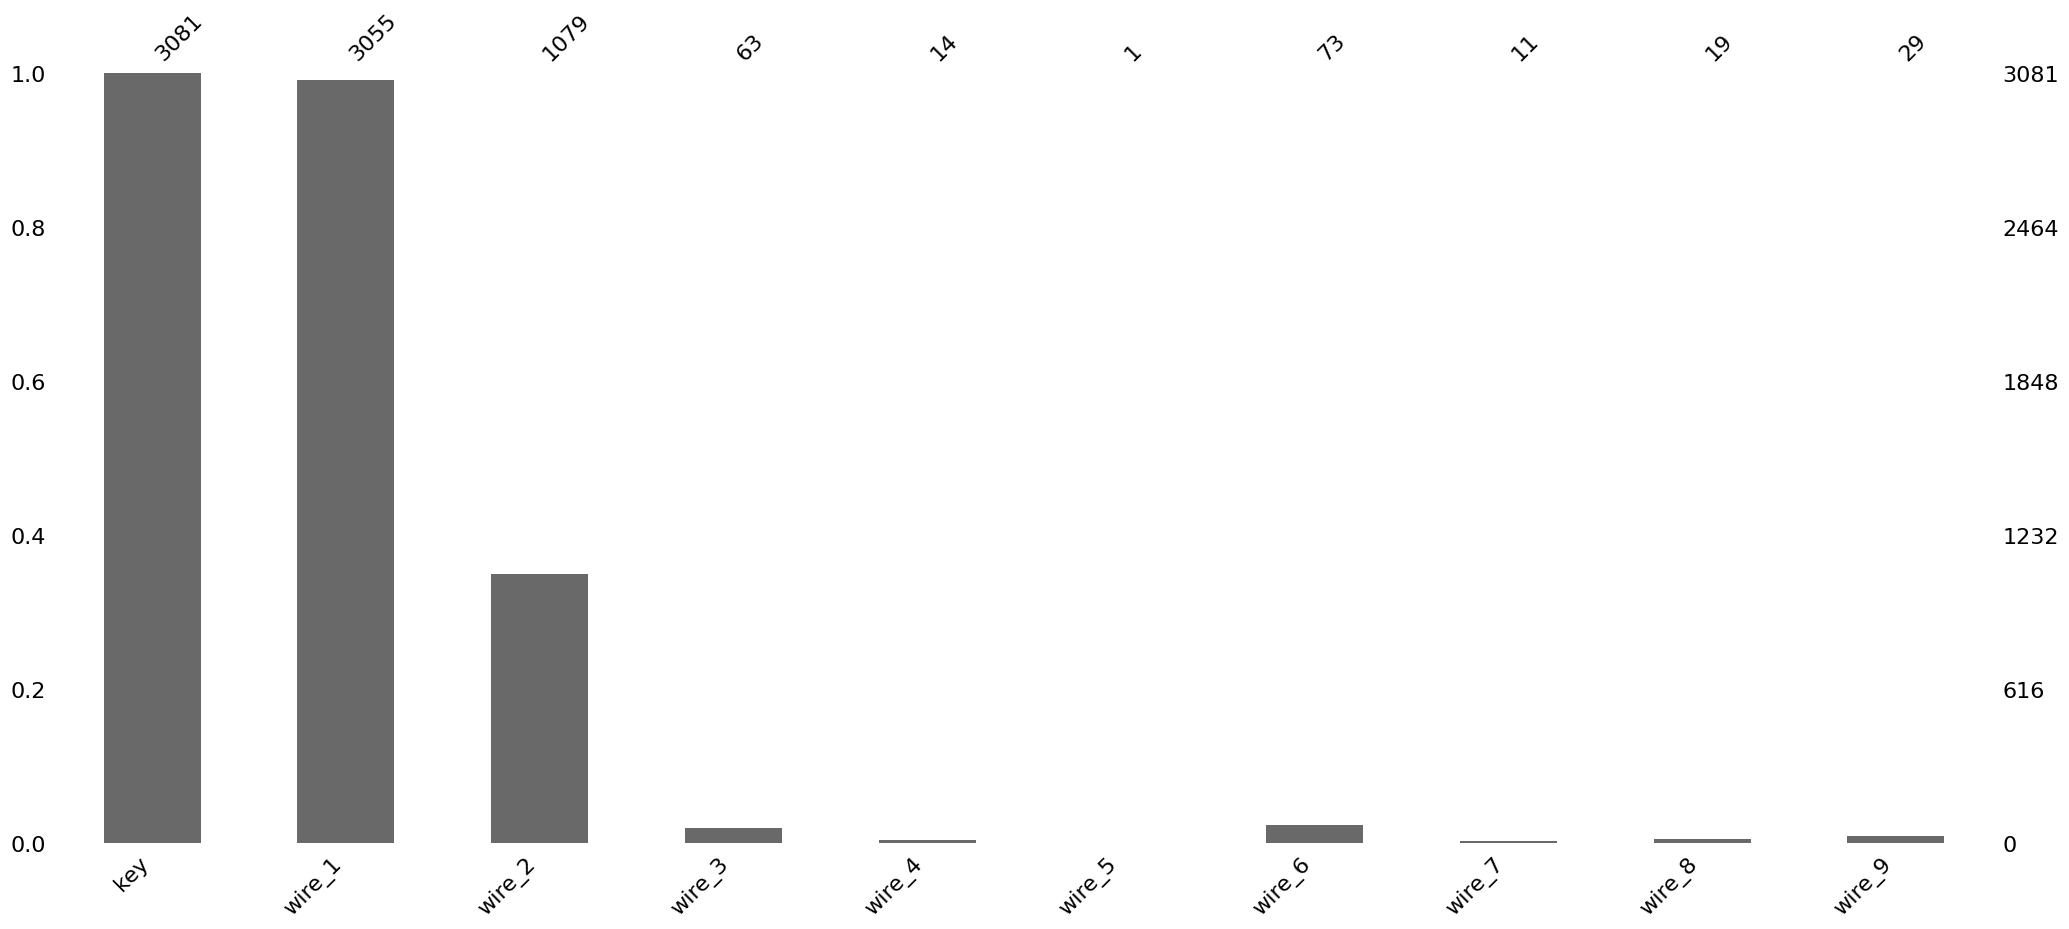

2026-03-04 23:48:55 [INFO] __main__: Характеристики базы данных


,count,mean,std,min,25%,50%,75%,max
key,3081.0,1623.426485,932.996726,1.0000,823.000000,1619.000000,2434.000000,3241.000000
wire_1,3055.0,100.895853,42.012518,1.9188,72.115684,100.158234,126.060483,330.314424


In [64]:
df_wire = check_data(df_wire)

Тут как и с сыпучими материалами - либо добавили, либо нет.  
Вместо пропусков - 0

In [65]:
for col in df_wire.columns:
    if col != 'key':
        df_wire[col] = df_wire[col].astype(float)

In [66]:
# сразу добавим общуюю массу добавок
wire_cols = [col for col in df_wire.columns if 'wire_' in col.lower()]
df_wire['total_wire'] = df_wire[wire_cols].sum(axis=1)

In [67]:
df_wire['count_wire'] = df_wire[wire_cols].count(axis=1)

In [68]:
df_wire.head()

,key,wire_1,wire_2,wire_3,wire_4,wire_5,wire_6,wire_7,wire_8,wire_9,total_wire,count_wire
0,1,60.059998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60.059998,1
1,2,96.052315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,96.052315,1
2,3,91.160157,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,91.160157,1
3,4,89.063515,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.063515,1
4,5,89.238236,9.11456,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.352796,2


In [69]:
df_wire = clear_df_missing_cols(df_wire)

2026-03-04 23:48:55 [INFO] __main__: Удалено признаков: 5
2026-03-04 23:48:55 [INFO] __main__: Осталось признаков: 7


2026-03-04 23:48:55 [INFO] matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-04 23:48:55 [INFO] matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


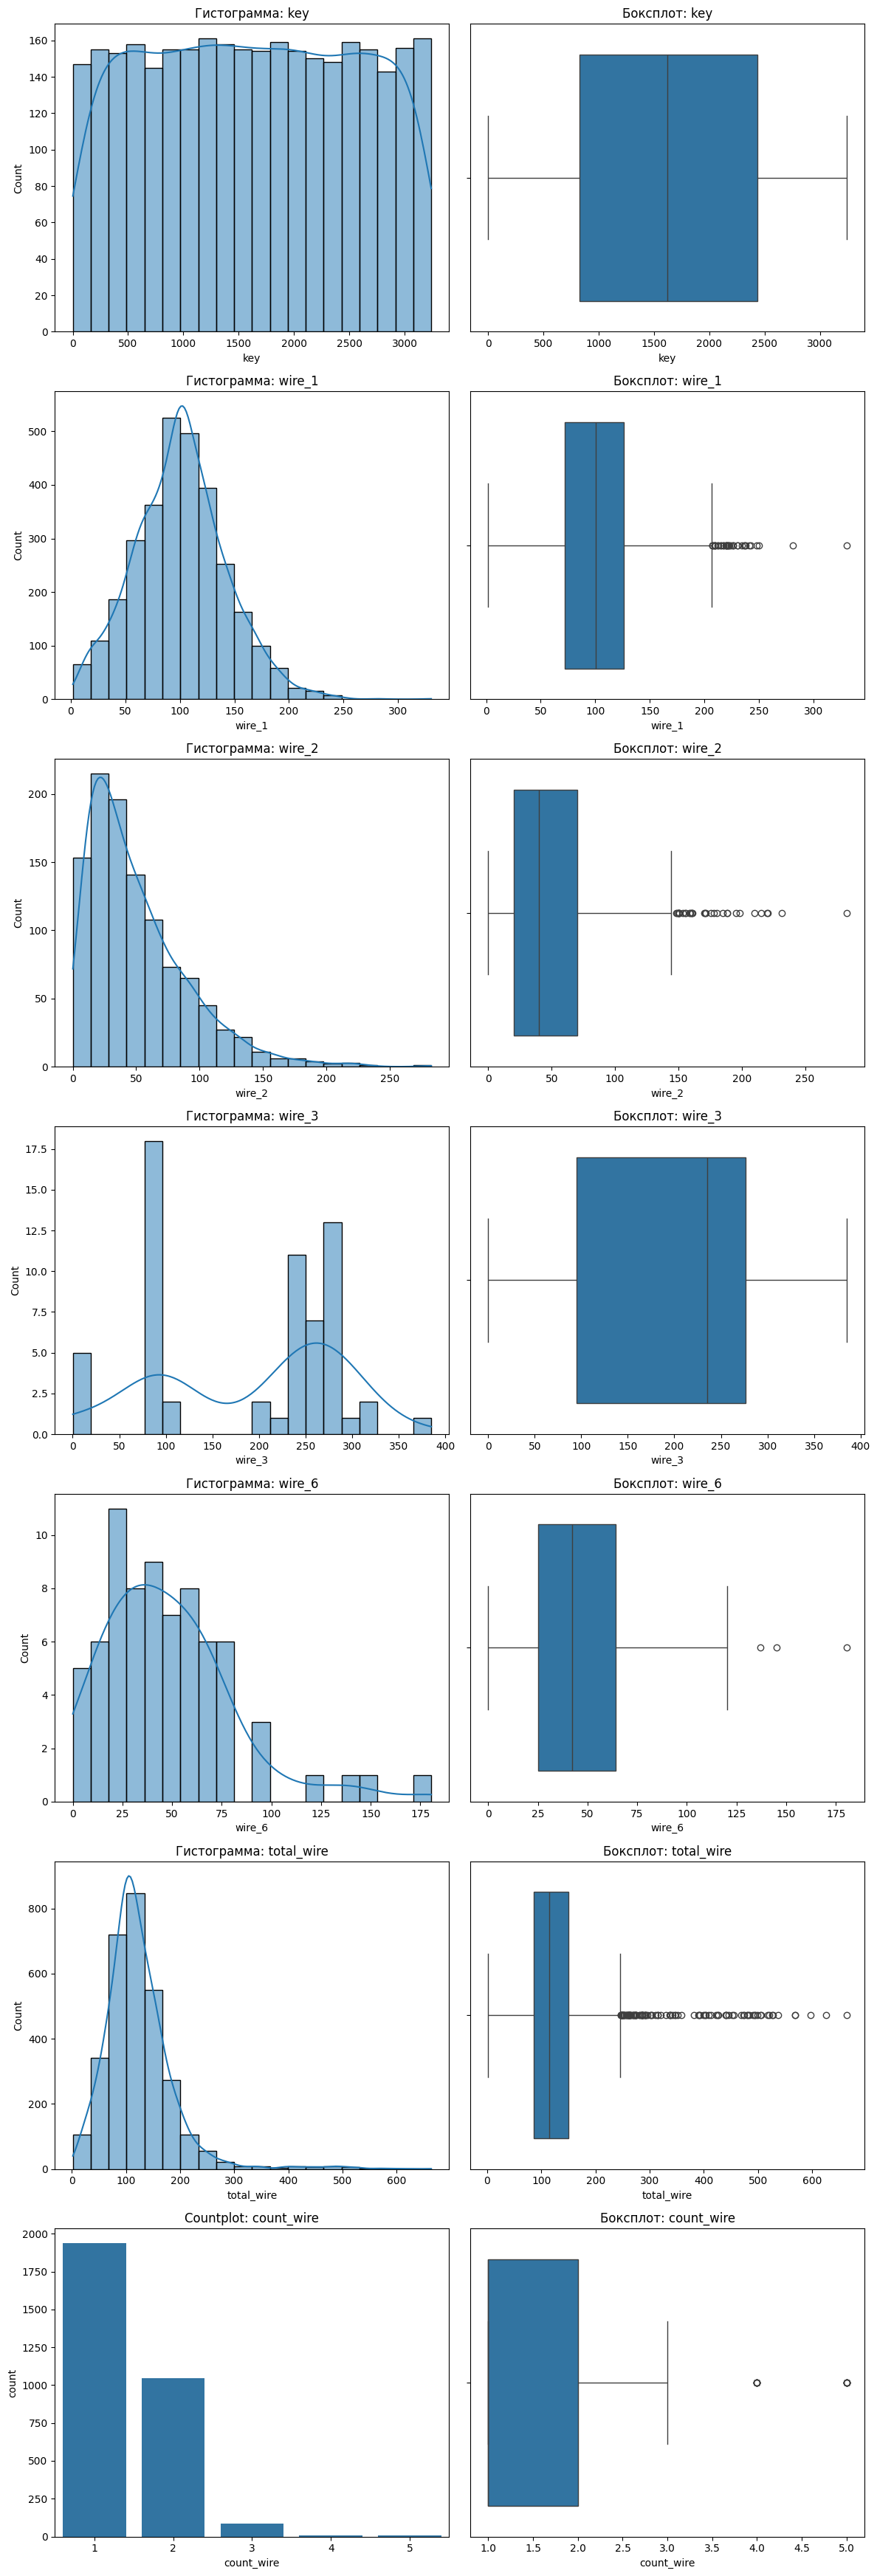

In [70]:
plot_combined(df_wire, col=None, target=None, col_type=None, legend_loc='best')

In [71]:
display(df_wire.info())
display(df_wire.head())
display(df_wire.describe().T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   key         3081 non-null   int64  
 1   wire_1      3055 non-null   float64
 2   wire_2      1079 non-null   float64
 3   wire_3      63 non-null     float64
 4   wire_6      73 non-null     float64
 5   total_wire  3081 non-null   float64
 6   count_wire  3081 non-null   int64  
dtypes: float64(5), int64(2)
memory usage: 168.6 KB


None

,key,wire_1,wire_2,wire_3,wire_6,total_wire,count_wire
0,1,60.059998,NaN,NaN,NaN,60.059998,1
1,2,96.052315,NaN,NaN,NaN,96.052315,1
2,3,91.160157,NaN,NaN,NaN,91.160157,1
3,4,89.063515,NaN,NaN,NaN,89.063515,1
4,5,89.238236,9.11456,NaN,NaN,98.352796,2


,count,mean,std,min,25%,50%,75%,max
key,3081.0,1623.426485,932.996726,1.000000,823.000000,1619.000000,2434.000000,3241.000000
wire_1,3055.0,100.895853,42.012518,1.918800,72.115684,100.158234,126.060483,330.314424
wire_2,1079.0,50.577323,39.320216,0.030160,20.193680,40.142956,70.227558,282.780152
wire_3,63.0,189.482681,99.513444,0.144144,95.135044,235.194977,276.252014,385.008668
wire_6,73.0,48.016974,33.919845,0.034320,25.053600,42.076324,64.212723,180.454575
total_wire,3081.0,123.723326,66.082966,1.918800,86.112000,114.179523,150.181198,663.851766
count_wire,3081.0,1.409932,0.578078,1.000000,1.000000,1.000000,2.000000,5.000000


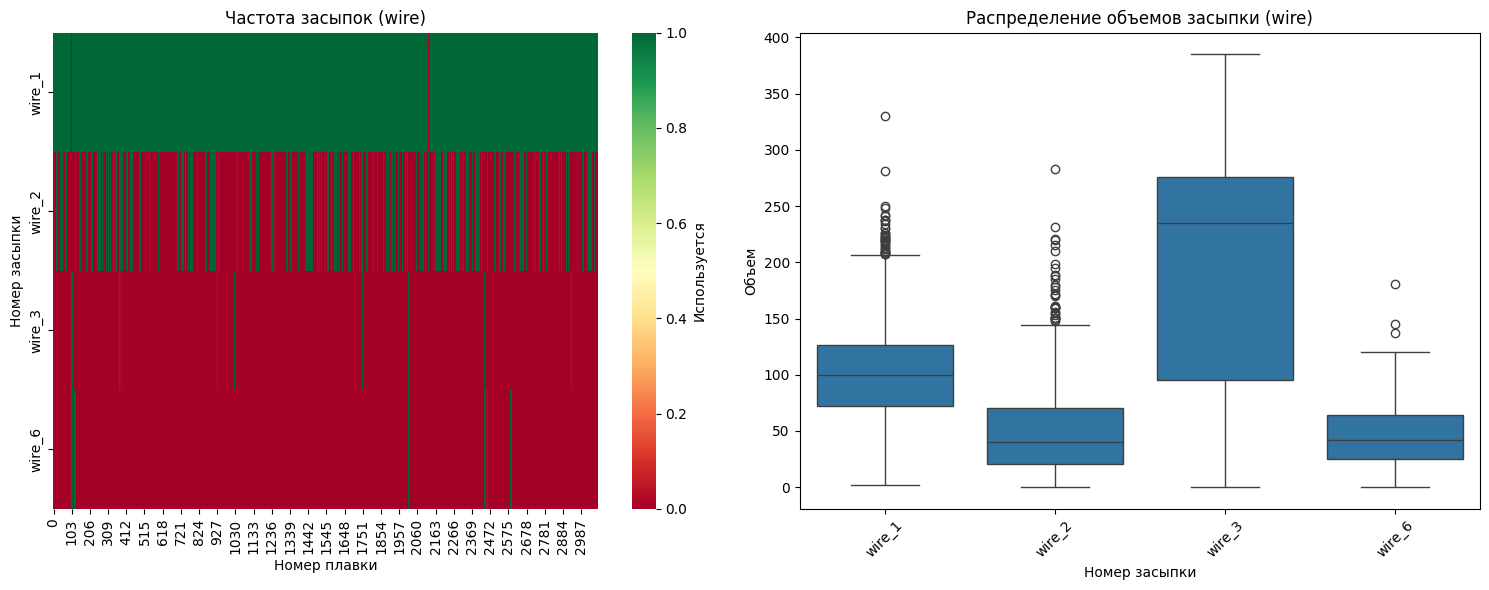

In [72]:
wire_cols = [col for col in df_wire.columns if col.startswith('wire_')]
wire_cols = sorted(wire_cols, key=lambda x: int(x.split('_')[1]))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Тепловая карта засыпок
usage_matrix = pd.DataFrame({col: (df_wire[col] > 0).astype(int) for col in wire_cols})
sns.heatmap(usage_matrix.T, cmap='RdYlGn', cbar_kws={'label': 'Используется'}, ax=axes[0])
axes[0].set_title('Частота засыпок (wire)')
axes[0].set_xlabel('Номер плавки')
axes[0].set_ylabel('Номер засыпки')

# Распределение объемов
data_for_box = df_wire[wire_cols].melt(var_name='Номер засыпки', value_name='Объем')
data_for_box = data_for_box[data_for_box['Объем'] > 0]
sns.boxplot(data=data_for_box, x='Номер засыпки', y='Объем', ax=axes[1])
# axes[1].set_yscale('log')
axes[1].set_title('Распределение объемов засыпки (wire)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Выборсы конечно же есть, но берем в расчте, что так надо  
В целом видно, что основная масса грузится в первые 2-3 этапа, а дальше уже мелкие корректировки

In [73]:
# Добьем нулями
# df_wire = df_wire.fillna(0)

##### df_wire_time

2026-03-04 23:48:56 [INFO] __main__: Общая информация базы данных


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   key     3081 non-null   int64 
 1   wire_1  3055 non-null   object
 2   wire_2  1079 non-null   object
 3   wire_3  63 non-null     object
 4   wire_4  14 non-null     object
 5   wire_5  1 non-null      object
 6   wire_6  73 non-null     object
 7   wire_7  11 non-null     object
 8   wire_8  19 non-null     object
 9   wire_9  29 non-null     object
dtypes: int64(1), object(9)
memory usage: 240.8+ KB


None

2026-03-04 23:48:56 [INFO] __main__: 5 случайных строк


,key,wire_1,wire_2,wire_3,wire_4,wire_5,wire_6,wire_7,wire_8,wire_9
2157,2267,2019-08-02 00:58:12,None,None,None,None,None,None,None,None
1698,1785,2019-07-08 16:29:31,2019-07-08 16:21:50,None,None,None,None,None,None,None
1254,1323,2019-06-22 04:58:40,None,None,None,None,None,None,None,None
1800,1890,2019-07-12 22:28:18,None,None,None,None,None,None,None,None
1785,1875,2019-07-12 01:06:36,2019-07-12 00:59:59,None,None,None,None,None,None,None


2026-03-04 23:48:56 [INFO] __main__: Число пропусков в базе данных


wire_1      26
wire_2    2002
wire_3    3018
wire_4    3067
wire_5    3080
wire_6    3008
wire_7    3070
wire_8    3062
wire_9    3052
dtype: int64

None

2026-03-04 23:48:56 [INFO] __main__: Визуализация пропусков


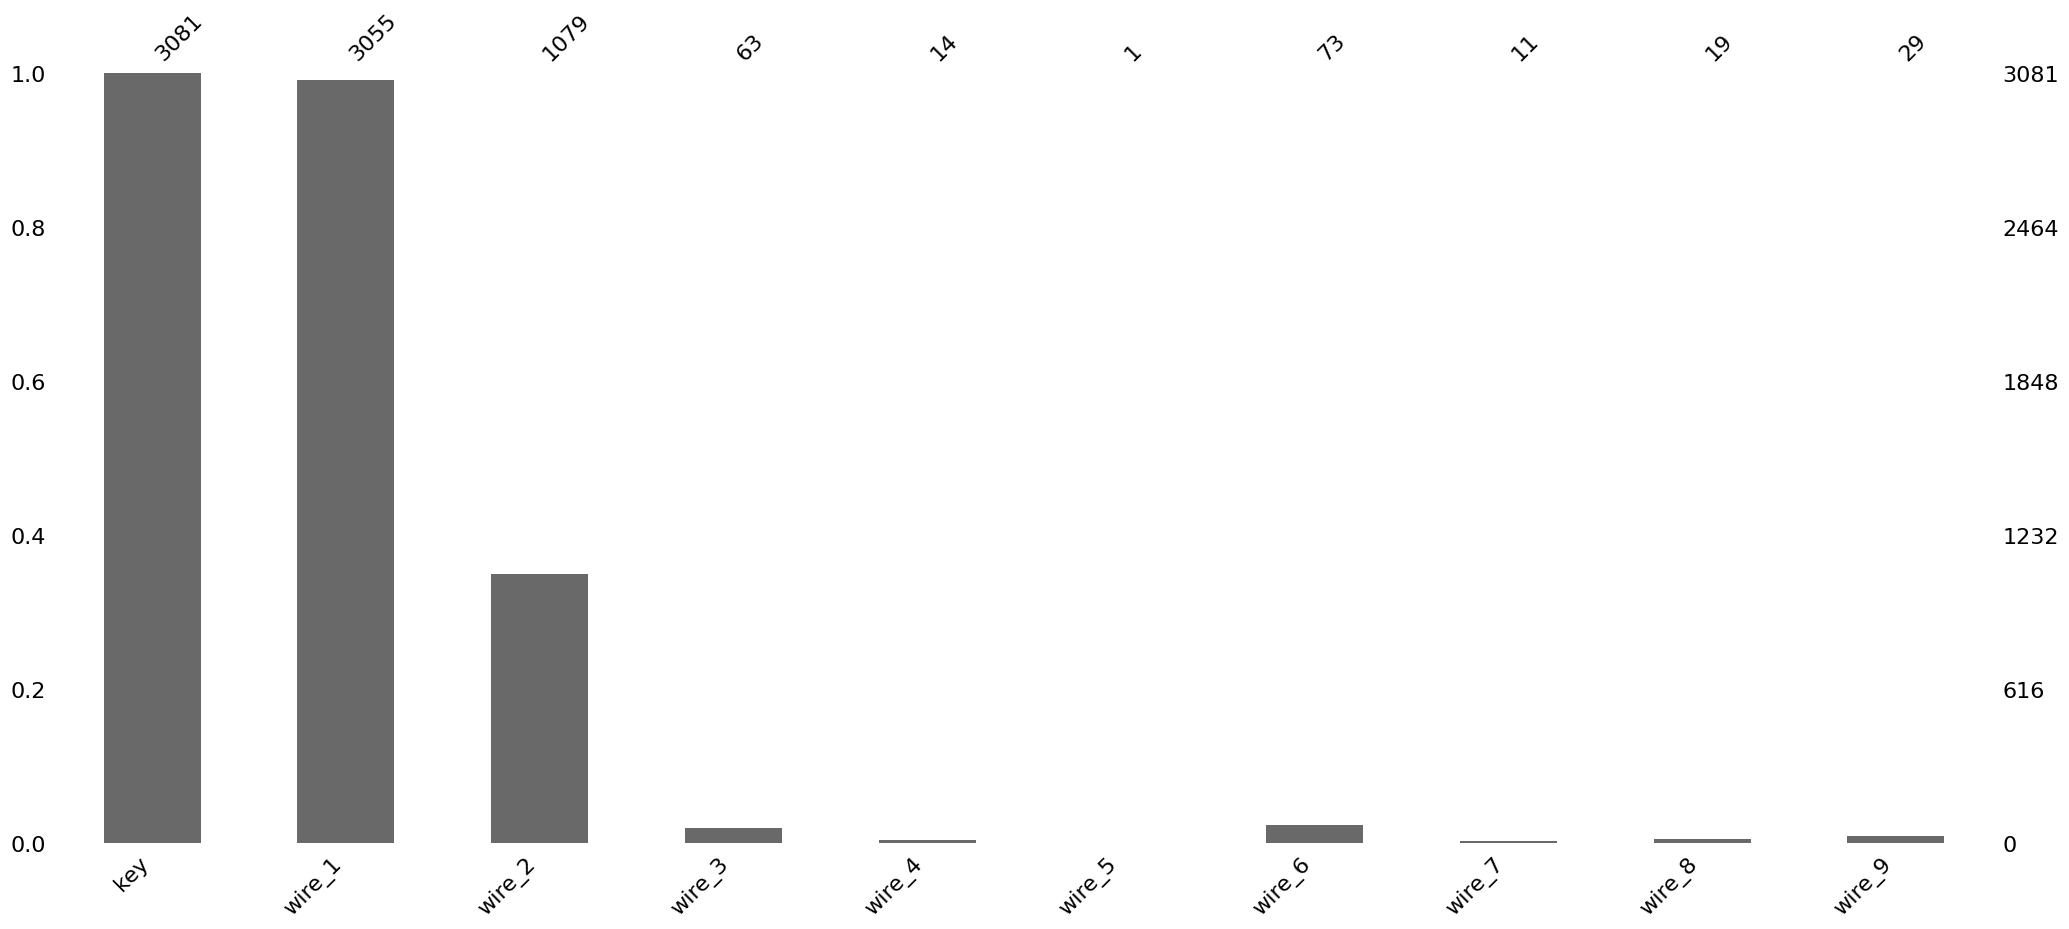

2026-03-04 23:48:56 [INFO] __main__: Характеристики базы данных


,count,mean,std,min,25%,50%,75%,max
key,3081.0,1623.426485,932.996726,1.0,823.0,1619.0,2434.0,3241.0


In [74]:
df_wire_time = check_data(df_wire_time)

In [75]:
df_wire_time = clear_df_missing_cols(df_wire_time)

2026-03-04 23:48:56 [INFO] __main__: Удалено признаков: 5
2026-03-04 23:48:56 [INFO] __main__: Осталось признаков: 5


In [76]:
wire_time_cols = [col for col in df_wire_time.columns if 'wire_' in col.lower()]
df_wire_time[wire_time_cols] = df_wire_time[wire_time_cols].astype('datetime64[ns]')

In [77]:
df_wire_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   key     3081 non-null   int64         
 1   wire_1  3055 non-null   datetime64[ns]
 2   wire_2  1079 non-null   datetime64[ns]
 3   wire_3  63 non-null     datetime64[ns]
 4   wire_6  73 non-null     datetime64[ns]
dtypes: datetime64[ns](4), int64(1)
memory usage: 120.5 KB


In [78]:
# если засыпок >2 то сделаем новые признаки
wire_time_cols = [col for col in df_wire_time.columns if col.startswith('wire_')]
wire_time_cols = sorted(wire_time_cols, key=lambda x: int(x.split('_')[1]))

In [79]:
if len(wire_time_cols) >= 2:
    df_wire_time['начало_засыпок'] = df_wire_time[wire_time_cols].min(axis=1)
    df_wire_time['конец_засыпок'] = df_wire_time[wire_time_cols].max(axis=1)
    df_wire_time['общее_время_засыпок'] = (df_wire_time['конец_засыпок'] - df_wire_time['начало_засыпок']).dt.total_seconds()
    
    # Средний интервал между подачами (если подач меньше двух, будет NaN)
    df_wire_time['интервал_подачи_avg'] = (
        df_wire_time[wire_time_cols]
        .apply(lambda row: row.dropna().sort_values().diff().dt.total_seconds().mean(), axis=1)
    )
else:
    logger.info("Недостаточно колонок wire_ для расчета признаков (нужно >=2). Пропускаем.")

In [80]:
display(df_wire_time.head())
display(df_wire_time.info())
display(df_wire_time.describe().T)

,key,wire_1,wire_2,wire_3,wire_6,начало_засыпок,конец_засыпок,общее_время_засыпок,интервал_подачи_avg
0,1,2019-05-03 11:06:19,NaT,NaT,NaT,2019-05-03 11:06:19,2019-05-03 11:06:19,0.0,NaN
1,2,2019-05-03 11:36:50,NaT,NaT,NaT,2019-05-03 11:36:50,2019-05-03 11:36:50,0.0,NaN
2,3,2019-05-03 12:11:46,NaT,NaT,NaT,2019-05-03 12:11:46,2019-05-03 12:11:46,0.0,NaN
3,4,2019-05-03 12:43:22,NaT,NaT,NaT,2019-05-03 12:43:22,2019-05-03 12:43:22,0.0,NaN
4,5,2019-05-03 13:20:44,2019-05-03 13:15:34,NaT,NaT,2019-05-03 13:15:34,2019-05-03 13:20:44,310.0,310.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   key                  3081 non-null   int64         
 1   wire_1               3055 non-null   datetime64[ns]
 2   wire_2               1079 non-null   datetime64[ns]
 3   wire_3               63 non-null     datetime64[ns]
 4   wire_6               73 non-null     datetime64[ns]
 5   начало_засыпок       3080 non-null   datetime64[ns]
 6   конец_засыпок        3080 non-null   datetime64[ns]
 7   общее_время_засыпок  3080 non-null   float64       
 8   интервал_подачи_avg  1137 non-null   float64       
dtypes: datetime64[ns](6), float64(2), int64(1)
memory usage: 216.8 KB


None

,count,mean,min,25%,50%,75%,max,std
key,3081.0,1623.426485,1.0,823.0,1619.0,2434.0,3241.0,932.996726
wire_1,3055,2019-07-05 23:22:34.279541760,2019-05-03 11:06:19,2019-06-04 19:30:11.500000,2019-07-03 06:36:23,2019-08-08 08:56:06.500000,2019-09-06 17:10:06,NaN
wire_2,1079,2019-07-07 01:07:08.735866624,2019-05-03 13:15:34,2019-06-05 14:50:26.500000,2019-07-04 23:13:39,2019-08-08 23:15:17,2019-09-06 07:35:40,NaN
wire_3,63,2019-07-10 15:09:58.650793472,2019-05-04 04:34:27,2019-06-11 14:17:38.500000,2019-07-21 10:04:47,2019-08-12 22:54:46,2019-09-02 07:14:44,NaN
wire_6,73,2019-07-07 11:51:15.095890432,2019-05-07 14:46:05,2019-05-08 21:47:30,2019-07-28 05:00:32,2019-08-13 13:33:02,2019-08-18 19:10:56,NaN
начало_засыпок,3080,2019-07-05 19:41:45.199025920,2019-05-03 11:06:19,2019-06-04 15:06:48,2019-07-03 02:56:18.500000,2019-08-08 02:57:18.500000,2019-09-06 17:10:06,NaN
конец_засыпок,3080,2019-07-05 19:45:09.480519424,2019-05-03 11:06:19,2019-06-04 15:06:48,2019-07-03 03:03:12,2019-08-08 02:57:18.500000,2019-09-06 17:10:06,NaN
общее_время_засыпок,3080.0,204.281494,0.0,0.0,0.0,390.5,5676.0,371.040229
интервал_подачи_avg,1137.0,519.648637,0.0,354.0,455.0,605.0,3375.0,312.266706


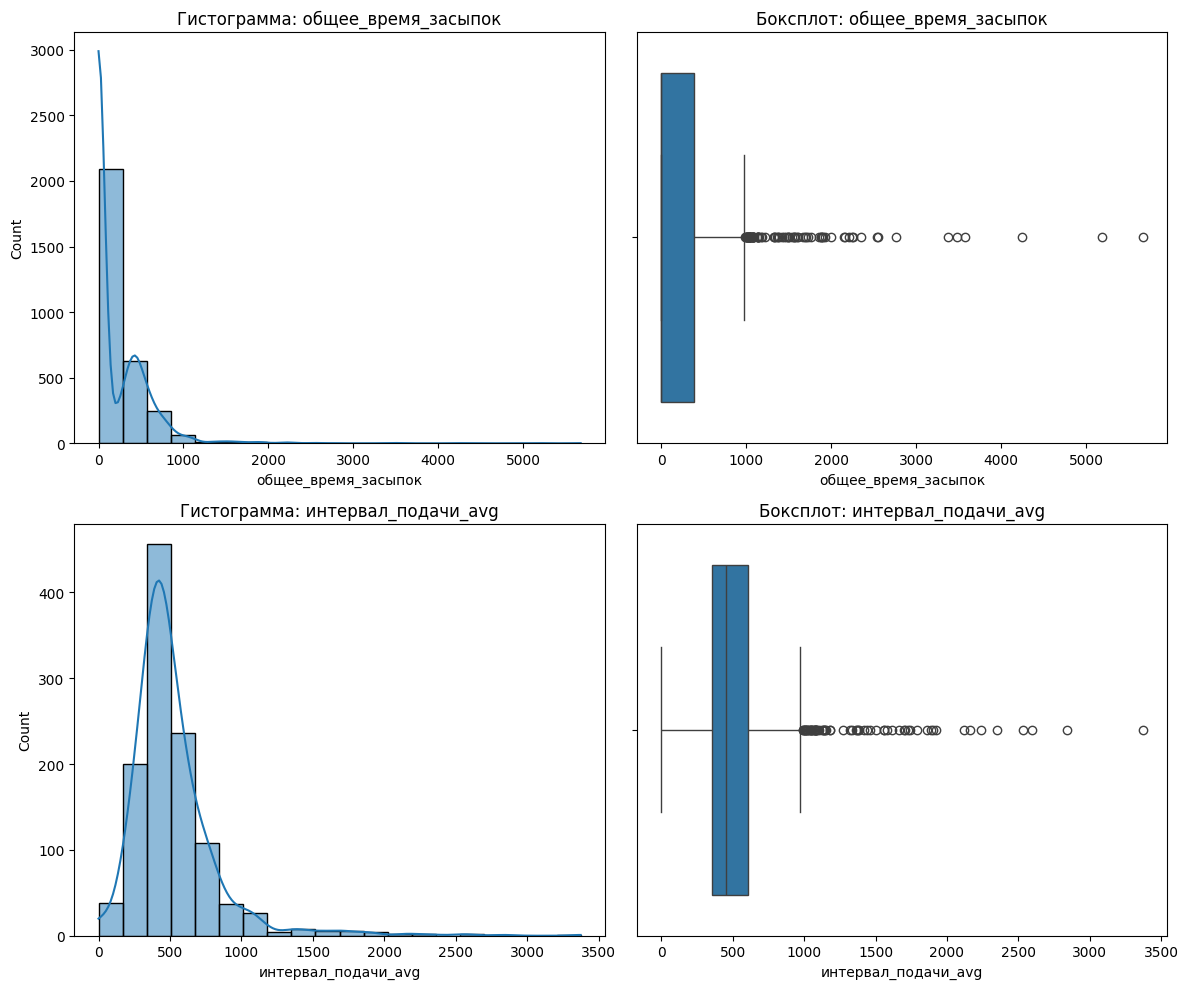

In [81]:
# и посмотрим что вышло
if len(wire_time_cols) >= 2:
    cols = ['общее_время_засыпок', 'интервал_подачи_avg']
    plot_combined(df_wire_time, col=cols, target=None, col_type=None, legend_loc='best')

Где-то большие промежутки и общее время плавки добавок, но штош поделать...

##### Выводы

Все данные были изучены и проанализированы  
Обработаны пропуски  
Скорректированы типы данных  
Реализованы новые признаки  

#### Объединение данных

##### Объединение

In [82]:
df_merged = (
    df_temp
    .merge(df_arc, on='key', how='inner')
    .merge(df_bulk, on='key', how='inner')
    .merge(df_bulk_time, on='key', how='inner', suffixes=('', '_bulk_time'))
    .merge(df_gas, on='key', how='inner')
    .merge(df_wire, on='key', how='inner')
    .merge(df_wire_time, on='key', how='inner', suffixes=('', '_wire_time'))
)

In [83]:
display(df_merged.drop_duplicates())

,key,время_первого_замера,время_последнего_замера,стартовая_температура,конечная_температура,количество_нагревов,суммарная_длительность,средняя_длительность,максимальная_длительность,средняя_активная_мощность,...,total_wire,count_wire,wire_1_wire_time,wire_2_wire_time,wire_3_wire_time,wire_6_wire_time,начало_засыпок_wire_time,конец_засыпок_wire_time,общее_время_засыпок_wire_time,интервал_подачи_avg_wire_time
0,1,2019-05-03 11:02:04,2019-05-03 11:30:38,1571.0,1618.0,5,1098.0,219.600000,365.0,0.607346,...,60.059998,1,2019-05-03 11:06:19,NaT,NaT,NaT,2019-05-03 11:06:19,2019-05-03 11:06:19,0.0,NaN
1,2,2019-05-03 11:34:04,2019-05-03 11:55:09,1577.0,1604.0,4,811.0,202.750000,338.0,0.534852,...,96.052315,1,2019-05-03 11:36:50,NaT,NaT,NaT,2019-05-03 11:36:50,2019-05-03 11:36:50,0.0,NaN
2,3,2019-05-03 12:06:44,2019-05-03 12:35:57,1596.0,1600.0,5,655.0,131.000000,280.0,0.812728,...,91.160157,1,2019-05-03 12:11:46,NaT,NaT,NaT,2019-05-03 12:11:46,2019-05-03 12:11:46,0.0,NaN
3,4,2019-05-03 12:39:27,2019-05-03 12:59:47,1601.0,1625.0,4,741.0,185.250000,278.0,0.676622,...,89.063515,1,2019-05-03 12:43:22,NaT,NaT,NaT,2019-05-03 12:43:22,2019-05-03 12:43:22,0.0,NaN
4,5,2019-05-03 13:11:03,2019-05-03 13:36:39,1576.0,1602.0,4,869.0,217.250000,415.0,0.563238,...,98.352796,2,2019-05-03 13:20:44,2019-05-03 13:15:34,NaT,NaT,2019-05-03 13:15:34,2019-05-03 13:20:44,310.0,310.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2324,2495,2019-08-10 11:27:47,2019-08-10 11:50:47,1570.0,1591.0,4,723.0,180.750000,234.0,0.792033,...,89.150879,1,2019-08-10 11:31:40,NaT,NaT,NaT,2019-08-10 11:31:40,2019-08-10 11:31:40,0.0,NaN
2325,2496,2019-08-10 11:56:48,2019-08-10 12:25:13,1554.0,1595.0,6,940.0,156.666667,228.0,0.695820,...,114.179527,1,2019-08-10 11:59:10,NaT,NaT,NaT,2019-08-10 11:59:10,2019-08-10 11:59:10,0.0,NaN
2326,2497,2019-08-10 12:37:26,2019-08-10 12:53:28,1571.0,1589.0,3,569.0,189.666667,207.0,1.201746,...,103.134723,2,2019-08-10 12:46:10,2019-08-10 12:40:30,NaT,NaT,2019-08-10 12:40:30,2019-08-10 12:46:10,340.0,340.0
2327,2498,2019-08-10 12:58:11,2019-08-10 13:23:31,1570.0,1594.0,5,750.0,150.000000,256.0,0.640462,...,118.110717,1,2019-08-10 13:02:54,NaT,NaT,NaT,2019-08-10 13:02:54,2019-08-10 13:02:54,0.0,NaN


Надо бы удалить временнЫе столбцы... они нам не понадобятся

In [84]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2329 entries, 0 to 2328
Data columns (total 53 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   key                             2329 non-null   int64         
 1   время_первого_замера            2329 non-null   datetime64[ns]
 2   время_последнего_замера         2329 non-null   datetime64[ns]
 3   стартовая_температура           2329 non-null   float64       
 4   конечная_температура            2329 non-null   float64       
 5   количество_нагревов             2329 non-null   int64         
 6   суммарная_длительность          2329 non-null   float64       
 7   средняя_длительность            2329 non-null   float64       
 8   максимальная_длительность       2329 non-null   float64       
 9   средняя_активная_мощность       2329 non-null   float64       
 10  максимальная_активная_мощность  2329 non-null   float64       
 11  сред

In [85]:
non_datetime_cols = df_merged.select_dtypes(exclude=['datetime64[ns]']).columns
main_df = df_merged[non_datetime_cols].copy()

In [86]:
main_df.head()

,key,стартовая_температура,конечная_температура,количество_нагревов,суммарная_длительность,средняя_длительность,максимальная_длительность,средняя_активная_мощность,максимальная_активная_мощность,средняя_реактивная_мощность,...,интервал_подачи_avg,газ_1,wire_1,wire_2,wire_3,wire_6,total_wire,count_wire,общее_время_засыпок_wire_time,интервал_подачи_avg_wire_time
0,1,1571.0,1618.0,5,1098.0,219.60,365.0,0.607346,0.867133,0.428564,...,361.666667,29.749986,60.059998,NaN,NaN,NaN,60.059998,1,0.0,NaN
1,2,1577.0,1604.0,4,811.0,202.75,338.0,0.534852,0.786322,0.363339,...,333.333333,12.555561,96.052315,NaN,NaN,NaN,96.052315,1,0.0,NaN
2,3,1596.0,1600.0,5,655.0,131.00,280.0,0.812728,1.222963,0.587491,...,327.666667,28.554793,91.160157,NaN,NaN,NaN,91.160157,1,0.0,NaN
3,4,1601.0,1625.0,4,741.0,185.25,278.0,0.676622,0.887855,0.514248,...,292.666667,18.841219,89.063515,NaN,NaN,NaN,89.063515,1,0.0,NaN
4,5,1576.0,1602.0,4,869.0,217.25,415.0,0.563238,0.892957,0.421998,...,68.333333,5.413692,89.238236,9.11456,NaN,NaN,98.352796,2,310.0,310.0


In [87]:
# попробуем дополнительно залогарифмировать признаки
from scipy.stats import skew

numeric_cols = main_df.select_dtypes(include=[np.number]).columns.tolist()
if 'key' in numeric_cols:
    numeric_cols.remove('key')

skewness = main_df[numeric_cols].apply(lambda x: skew(x.dropna()))
skewed_features = skewness[abs(skewness) > 1].index.tolist()
display('Скошенные признаки (|skew|>1):', skewed_features)

for col in skewed_features:
    main_df[f'log_{col}'] = np.log1p(main_df[col])
    display(f'Создан log_{col}')

'Скошенные признаки (|skew|>1):'

['суммарная_длительность',
 'максимальная_длительность',
 'bulk_1',
 'bulk_3',
 'bulk_5',
 'bulk_6',
 'bulk_11',
 'bulk_12',
 'bulk_14',
 'общее_время_засыпок',
 'интервал_подачи_avg',
 'газ_1',
 'wire_2',
 'wire_6',
 'total_wire',
 'count_wire',
 'общее_время_засыпок_wire_time',
 'интервал_подачи_avg_wire_time']

'Создан log_суммарная_длительность'

'Создан log_максимальная_длительность'

'Создан log_bulk_1'

...

'Создан log_wire_6'

'Создан log_total_wire'

'Создан log_count_wire'

'Создан log_общее_время_засыпок_wire_time'

'Создан log_интервал_подачи_avg_wire_time'

In [88]:
main_df = main_df.fillna(0)

In [89]:
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2329 entries, 0 to 2328
Data columns (total 51 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   key                                2329 non-null   int64  
 1   стартовая_температура              2329 non-null   float64
 2   конечная_температура               2329 non-null   float64
 3   количество_нагревов                2329 non-null   int64  
 4   суммарная_длительность             2329 non-null   float64
 5   средняя_длительность               2329 non-null   float64
 6   максимальная_длительность          2329 non-null   float64
 7   средняя_активная_мощность          2329 non-null   float64
 8   максимальная_активная_мощность     2329 non-null   float64
 9   средняя_реактивная_мощность        2329 non-null   float64
 10  bulk_1                             2329 non-null   float64
 11  bulk_3                             2329 non-null   float

##### Исследуем итоговую таблицу

interval columns not set, guessing: ['стартовая_температура', 'конечная_температура', 'количество_нагревов', 'суммарная_длительность', 'средняя_длительность', 'максимальная_длительность', 'средняя_активная_мощность', 'максимальная_активная_мощность', 'средняя_реактивная_мощность', 'bulk_1', 'bulk_3', 'bulk_4', 'bulk_5', 'bulk_6', 'bulk_10', 'bulk_11', 'bulk_12', 'bulk_14', 'bulk_15', 'total_bulk', 'count_bulk', 'общее_время_засыпок', 'интервал_подачи_avg', 'газ_1', 'wire_1', 'wire_2', 'wire_3', 'wire_6', 'total_wire', 'count_wire', 'общее_время_засыпок_wire_time', 'интервал_подачи_avg_wire_time', 'log_суммарная_длительность', 'log_максимальная_длительность', 'log_bulk_1', 'log_bulk_3', 'log_bulk_5', 'log_bulk_6', 'log_bulk_11', 'log_bulk_12', 'log_bulk_14', 'log_общее_время_засыпок', 'log_интервал_подачи_avg', 'log_газ_1', 'log_wire_2', 'log_wire_6', 'log_total_wire', 'log_count_wire', 'log_общее_время_засыпок_wire_time', 'log_интервал_подачи_avg_wire_time']


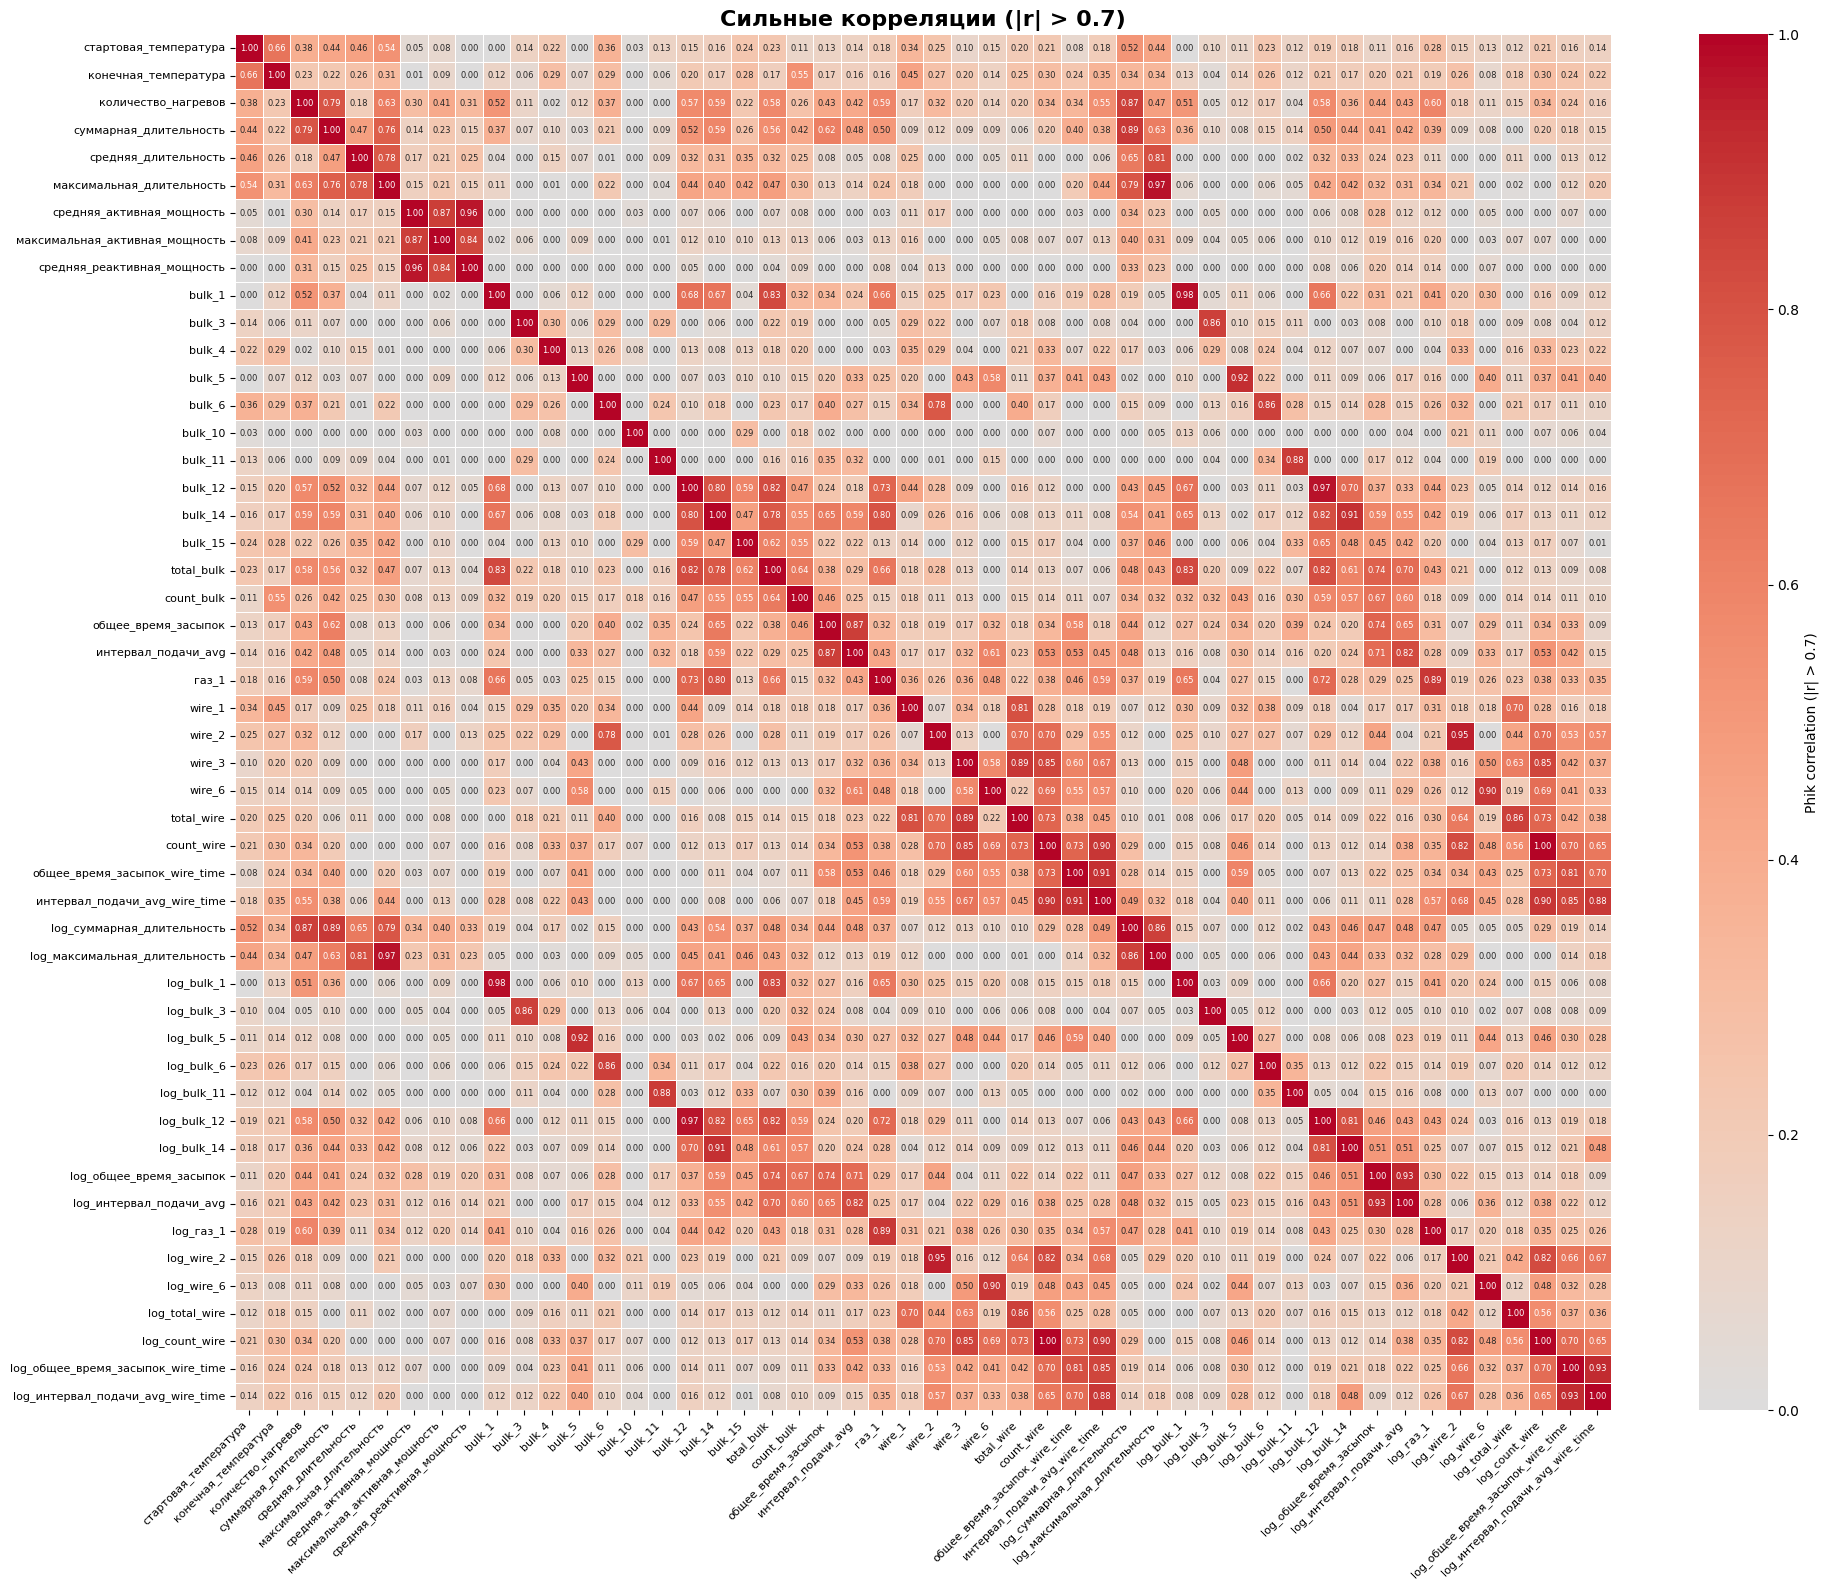

In [90]:
df_cor = main_df.drop(columns=['key'])
correlation_matrix = df_cor.phik_matrix()

plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            center=0,
            square=True, 
            linewidths=0.5,
            cbar_kws={'label': 'Phik correlation (|r| > 0.7)'},
            annot_kws={'size': 6})
plt.title('Сильные корреляции (|r| > 0.7)', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

In [91]:
threshold_cor = 0.9

features_to_drop = set()
corr_matrix = correlation_matrix.copy()
np.fill_diagonal(corr_matrix.values, 0)

for col in corr_matrix.columns:
    high_corr = corr_matrix[abs(corr_matrix[col]) > threshold_cor].index.tolist()
    if high_corr:
        features_to_drop.update(high_corr[1:])

logger.info(f"Удаляем признаков: {len(features_to_drop)}")
display("Список удаляемых признаков:", sorted(features_to_drop))

main_df = main_df.drop(columns=list(features_to_drop), errors='ignore')

logger.info(f"Осталось признаков: {main_df.shape[1] - 1}")

2026-03-04 23:49:04 [INFO] __main__: Удаляем признаков: 0


'Список удаляемых признаков:'

[]

2026-03-04 23:49:04 [INFO] __main__: Осталось признаков: 50


In [92]:
# выведем корреляцию с таргетом
corr = correlation_matrix[TARGET].sort_values(ascending=False)

logger.info(f"Сильня корреляция с {TARGET}:")
display(corr[corr >= 0.9])

logger.info(f"Слабая корреляция с {TARGET}:")
display(corr[corr < 0.9])

2026-03-04 23:49:04 [INFO] __main__: Сильня корреляция с конечная_температура:


конечная_температура    1.0
Name: конечная_температура, dtype: float64

2026-03-04 23:49:04 [INFO] __main__: Слабая корреляция с конечная_температура:


стартовая_температура                0.664084
count_bulk                           0.546851
wire_1                               0.446492
интервал_подачи_avg_wire_time        0.353332
log_суммарная_длительность           0.340301
log_максимальная_длительность        0.337327
максимальная_длительность            0.314707
count_wire                           0.295693
log_count_wire                       0.295693
bulk_6                               0.292675
bulk_4                               0.286480
bulk_15                              0.279436
wire_2                               0.266584
средняя_длительность                 0.262174
log_wire_2                           0.259545
log_bulk_6                           0.255280
total_wire                           0.251171
log_общее_время_засыпок_wire_time    0.244365
общее_время_засыпок_wire_time        0.236308
количество_нагревов                  0.226517
суммарная_длительность               0.220575
log_интервал_подачи_avg_wire_time 

In [93]:
# # проверим зависимость VIF
# VIF = main_df.drop(columns=['key', TARGET])

# VIF = pd.get_dummies(VIF, drop_first=True)
# VIF = VIF.assign(const=1)

# for col in VIF.select_dtypes(include='bool').columns:
#     VIF[col] = VIF[col].astype(int)

# VIF = VIF.dropna()

# # Пересчитываем VIF
# vif_data = pd.DataFrame()
# vif_data["Признаки"] = VIF.columns
# vif_data["VIF"] = [variance_inflation_factor(VIF.values, i) for i in range(VIF.shape[1])]

# # Удаляем константу из результатов
# vif_data = vif_data[vif_data["Признаки"] != "const"]
# display(vif_data)






# Подготовка данных для VIF
vif_df = main_df.drop(columns=['key', TARGET])
vif_df = pd.get_dummies(vif_df, drop_first=True)
for col in vif_df.select_dtypes(include='bool').columns:
    vif_df[col] = vif_df[col].astype(int)
vif_df = vif_df.dropna()

# Список всех признаков
all_features = vif_df.columns.tolist()
features = all_features.copy()
threshold = 10

# Итеративное удаление признаков с VIF > threshold
while True:
    X_with_const = vif_df[features].assign(const=1)
    vif_vals = [variance_inflation_factor(X_with_const.values, i) for i in range(len(features))]
    max_vif = max(vif_vals)
    if max_vif <= threshold:
        break
    idx = vif_vals.index(max_vif)
    removed = features.pop(idx)
    logger.info(f"Удалён {removed} (VIF={max_vif:.2f})")

logger.info(f"Осталось признаков: {len(features)}")
logger.info(f"Список: {features}")

# Удаляем из main_df признаки, которые не прошли отбор
cols_to_drop = [col for col in all_features if col not in features]
if cols_to_drop:
    logger.info(f"Удаляем из main_df: {cols_to_drop}")
    main_df = main_df.drop(columns=cols_to_drop, errors='ignore')
else:
    logger.info("Ничего не удаляем, все признаки остались.")

2026-03-04 23:49:05 [INFO] __main__: Удалён bulk_1 (VIF=inf)
2026-03-04 23:49:05 [INFO] __main__: Удалён log_общее_время_засыпок_wire_time (VIF=13963.46)
2026-03-04 23:49:05 [INFO] __main__: Удалён total_bulk (VIF=5332.82)
2026-03-04 23:49:06 [INFO] __main__: Удалён log_count_wire (VIF=569.24)
2026-03-04 23:49:06 [INFO] __main__: Удалён log_общее_время_засыпок (VIF=341.08)
2026-03-04 23:49:06 [INFO] __main__: Удалён total_wire (VIF=284.45)
2026-03-04 23:49:06 [INFO] __main__: Удалён log_максимальная_длительность (VIF=30.61)
2026-03-04 23:49:07 [INFO] __main__: Удалён количество_нагревов (VIF=30.07)
2026-03-04 23:49:07 [INFO] __main__: Удалён интервал_подачи_avg_wire_time (VIF=29.84)
2026-03-04 23:49:07 [INFO] __main__: Удалён log_wire_2 (VIF=24.28)
2026-03-04 23:49:07 [INFO] __main__: Удалён count_bulk (VIF=20.04)
2026-03-04 23:49:07 [INFO] __main__: Удалён средняя_активная_мощность (VIF=16.37)
2026-03-04 23:49:08 [INFO] __main__: Удалён count_wire (VIF=10.73)
2026-03-04 23:49:08 [INFO

По VIF всё больно - и как хорошо, что у нас нет линеек, а для всего остальное VIF чистить нет смысла, но мы все равно почистим  
Тогда просто делим данные и переходим к обучению

## Подготовим данные для обучения

In [94]:
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2329 entries, 0 to 2328
Data columns (total 36 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   key                                2329 non-null   int64  
 1   стартовая_температура              2329 non-null   float64
 2   конечная_температура               2329 non-null   float64
 3   средняя_длительность               2329 non-null   float64
 4   максимальная_длительность          2329 non-null   float64
 5   максимальная_активная_мощность     2329 non-null   float64
 6   средняя_реактивная_мощность        2329 non-null   float64
 7   bulk_3                             2329 non-null   float64
 8   bulk_4                             2329 non-null   float64
 9   bulk_5                             2329 non-null   float64
 10  bulk_6                             2329 non-null   float64
 11  bulk_10                            2329 non-null   float

In [95]:
X_train, X_test, y_train, y_test = train_test_split(
    main_df.drop([TARGET, 'key'], axis=1),
    main_df[TARGET],
    test_size = TEST_SIZE, 
    random_state = RANDOM_STATE)

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [96]:
X_train_scaled.shape, X_test_scaled.shape

((1746, 34), (583, 34))

In [97]:
X_train_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
стартовая_температура,1746.0,0.546653,0.138141,0.0,0.464912,0.561404,0.640351,1.0
средняя_длительность,1746.0,0.355824,0.134018,0.0,0.261682,0.348209,0.437565,1.0
максимальная_длительность,1746.0,0.273296,0.126581,0.0,0.182353,0.256471,0.328235,1.0
максимальная_активная_мощность,1746.0,0.589469,0.194828,0.0,0.450324,0.593332,0.749505,1.0
средняя_реактивная_мощность,1746.0,0.383900,0.127745,0.0,0.293816,0.380113,0.460029,1.0
bulk_3,1746.0,0.101749,0.161992,0.0,0.000000,0.000000,0.169604,1.0
bulk_4,1746.0,0.139131,0.215994,0.0,0.000000,0.000000,0.287823,1.0
bulk_5,1746.0,0.004897,0.040457,0.0,0.000000,0.000000,0.000000,1.0
bulk_6,1746.0,0.046207,0.113346,0.0,0.000000,0.000000,0.000000,1.0
bulk_10,1746.0,0.034029,0.136884,0.0,0.000000,0.000000,0.000000,1.0


## Обучение

### случайный лес

In [98]:
results = []

rf_params = {
    'n_estimators': 1000,
    'max_depth': 10,
    'min_samples_split': 5,
    'min_samples_leaf': 2,
    'max_features': 'sqrt',
    'bootstrap': True,
    'criterion': 'absolute_error',
    'random_state': RANDOM_STATE,
    'n_jobs': -1
}
model_rf = RandomForestRegressor(**rf_params)

# Кросс-валидация
cv_mae_scores = -cross_val_score(model_rf, X_train_scaled, y_train, cv=CV_FOLDS, 
                                  scoring='neg_mean_absolute_error', n_jobs=-1)
cv_r2_scores = cross_val_score(model_rf, X_train_scaled, y_train, cv=CV_FOLDS, 
                                scoring='r2', n_jobs=-1)

# Обучение на всей выборке
model_rf.fit(X_train_scaled, y_train)
y_train_pred_rf = model_rf.predict(X_train_scaled)

results.append({
    'model_name': 'RandomForestRegressor',
    'train_mae': mean_absolute_error(y_train, y_train_pred_rf),
    'train_r2': r2_score(y_train, y_train_pred_rf),
    'cv_mae_mean': cv_mae_scores.mean(),
    'cv_mae_std': cv_mae_scores.std(),
    'cv_r2_mean': cv_r2_scores.mean(),
    'cv_r2_std': cv_r2_scores.std(),
})

logger.info("Результаты:")
last_model = results[-1]
logger.info(f"Модель: {last_model['model_name']}")
for key, value in last_model.items():
    if key != 'model_name':
        logger.info(f"------- {key}: {value:.4f}" if isinstance(value, float) else f"------- {key}: {value}")

2026-03-04 23:49:21 [INFO] __main__: Результаты:
2026-03-04 23:49:21 [INFO] __main__: Модель: RandomForestRegressor
2026-03-04 23:49:21 [INFO] __main__: ------- train_mae: 5.8068
2026-03-04 23:49:21 [INFO] __main__: ------- train_r2: 0.7397
2026-03-04 23:49:21 [INFO] __main__: ------- cv_mae_mean: 8.1583
2026-03-04 23:49:21 [INFO] __main__: ------- cv_mae_std: 0.2193
2026-03-04 23:49:21 [INFO] __main__: ------- cv_r2_mean: 0.4985
2026-03-04 23:49:21 [INFO] __main__: ------- cv_r2_std: 0.0014


Немного не дотянули до требуемых значений

### catboost

In [ ]:
cb_params = {
    'iterations': 700,
    'depth': 4,
    'learning_rate': 0.05,
    'l2_leaf_reg': 5,
    'bagging_temperature': 0.8,
    'random_strength': 0.5,
    'loss_function': 'MAE',
    'random_seed': RANDOM_STATE,
    'allow_writing_files': False,
    'verbose': False,
    'thread_count': -1
}
model_cb = CatBoostRegressor(**cb_params)

# Кросс-валидация
cv_mae_scores = -cross_val_score(model_cb, X_train_scaled, y_train, cv=CV_FOLDS,
                                  scoring='neg_mean_absolute_error', n_jobs=-1)
cv_r2_scores = cross_val_score(model_cb, X_train_scaled, y_train, cv=CV_FOLDS,
                                scoring='r2', n_jobs=-1)

# Обучение на всей выборке
model_cb.fit(X_train_scaled, y_train, verbose=False)
y_train_pred_cb = model_cb.predict(X_train_scaled)

results.append({
    'model_name': 'CatBoostRegressor',
    'train_mae': mean_absolute_error(y_train, y_train_pred_cb),
    'train_r2': r2_score(y_train, y_train_pred_cb),
    'cv_mae_mean': cv_mae_scores.mean(),
    'cv_mae_std': cv_mae_scores.std(),
    'cv_r2_mean': cv_r2_scores.mean(),
    'cv_r2_std': cv_r2_scores.std(),
})

logger.info("Результаты:")
last_model = results[-1]
logger.info(f"Модель: {last_model['model_name']}")
for key, value in last_model.items():
    if key != 'model_name':
        logger.info(f"------- {key}: {value:.4f}" if isinstance(value, float) else f"------- {key}: {value}")

2026-03-04 23:49:29 [INFO] __main__: Результаты:
2026-03-04 23:49:29 [INFO] __main__: Модель: CatBoostRegressor
2026-03-04 23:49:29 [INFO] __main__: ------- train_mae: 4.8363
2026-03-04 23:49:29 [INFO] __main__: ------- train_r2: 0.7600
2026-03-04 23:49:29 [INFO] __main__: ------- cv_mae_mean: 7.2990
2026-03-04 23:49:29 [INFO] __main__: ------- cv_mae_std: 0.0023
2026-03-04 23:49:29 [INFO] __main__: ------- cv_r2_mean: 0.5750
2026-03-04 23:49:29 [INFO] __main__: ------- cv_r2_std: 0.0252


катбуст показал почти нужные результаты

### lightgbm

In [100]:
lgb_params = {
    'n_estimators': 500,
    'max_depth': 6,
    'learning_rate': 0.1,
    'objective': 'regression_l1',
    'random_state': RANDOM_STATE,
    'verbosity': -1,
    'n_jobs': -1
}
model_lgb = lgb.LGBMRegressor(**lgb_params)

# Кросс-валидация
cv_mae_scores = -cross_val_score(model_lgb, X_train_scaled, y_train, cv=CV_FOLDS,
                                  scoring='neg_mean_absolute_error', n_jobs=-1)
cv_r2_scores = cross_val_score(model_lgb, X_train_scaled, y_train, cv=CV_FOLDS,
                                scoring='r2', n_jobs=-1)

# Обучение на всей выборке
model_lgb.fit(X_train_scaled, y_train)
y_train_pred_lgb = model_lgb.predict(X_train_scaled)

results.append({
    'model_name': 'LightGBMRegressor',
    'train_mae': mean_absolute_error(y_train, y_train_pred_lgb),
    'train_r2': r2_score(y_train, y_train_pred_lgb),
    'cv_mae_mean': cv_mae_scores.mean(),
    'cv_mae_std': cv_mae_scores.std(),
    'cv_r2_mean': cv_r2_scores.mean(),
    'cv_r2_std': cv_r2_scores.std(),
})

logger.info("Результаты:")
last_model = results[-1]
logger.info(f"Модель: {last_model['model_name']}")
for key, value in last_model.items():
    if key != 'model_name':
        logger.info(f"------- {key}: {value:.4f}" if isinstance(value, float) else f"------- {key}: {value}")

2026-03-04 23:49:36 [INFO] __main__: Результаты:
2026-03-04 23:49:36 [INFO] __main__: Модель: LightGBMRegressor
2026-03-04 23:49:36 [INFO] __main__: ------- train_mae: 3.2418
2026-03-04 23:49:36 [INFO] __main__: ------- train_r2: 0.8324
2026-03-04 23:49:36 [INFO] __main__: ------- cv_mae_mean: 7.4365
2026-03-04 23:49:36 [INFO] __main__: ------- cv_mae_std: 0.0395
2026-03-04 23:49:36 [INFO] __main__: ------- cv_r2_mean: 0.5640
2026-03-04 23:49:36 [INFO] __main__: ------- cv_r2_std: 0.0198


### нейронка

In [101]:
def set_seed(seed=20):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(20)

In [102]:
X_train_full, X_val, y_train_full, y_val = train_test_split(
    X_train_scaled, y_train, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

In [103]:
class RegressionNN(nn.Module):
    def __init__(self, input_dim, hidden_dims=[256, 128, 64], activation='relu', dropout_rate=0.2, use_batchnorm=True):
        super().__init__()
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden_dim))
            
            if activation == 'relu':
                layers.append(nn.ReLU())
            elif activation == 'elu':
                layers.append(nn.ELU())
            elif activation == 'selu':
                layers.append(nn.SELU())
            elif activation == 'tanh':
                layers.append(nn.Tanh())
            
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            
            prev_dim = hidden_dim
        
        layers.append(nn.Linear(prev_dim, 1))
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

In [104]:
HIDDEN_DIMS = [256, 128, 64]
ACTIVATION = 'relu'
DROPOUT_RATE = 0.2
USE_BATCHNORM = True
LEARNING_RATE = 0.001
BATCH_SIZE = 32
WEIGHT_DECAY = 1e-5
EPOCHS = 100
EARLY_STOP = 10

In [105]:
X_train_t = torch.tensor(X_train_full.values, dtype=torch.float32).to(DEVICE)
X_val_t = torch.tensor(X_val.values, dtype=torch.float32).to(DEVICE)

y_train_t = torch.tensor(y_train_full.values, dtype=torch.float32).to(DEVICE).view(-1, 1)
y_val_t = torch.tensor(y_val.values, dtype=torch.float32).to(DEVICE).view(-1, 1)

In [106]:
model_nn = RegressionNN(
    input_dim=X_train_t.shape[1],
    hidden_dims=HIDDEN_DIMS,
    activation=ACTIVATION,
    dropout_rate=DROPOUT_RATE,
    use_batchnorm=USE_BATCHNORM
).to(DEVICE)

optimizer = optim.Adam(model_nn.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
criterion = nn.L1Loss()  # MAE

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [107]:
kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_mae_scores = []
cv_r2_scores = []

# Оборачиваем итератор по фолдам в tqdm
for fold, (train_idx, val_idx) in enumerate(tqdm(kf.split(X_train_scaled), total=CV_FOLDS, desc='CV Folds')):
    X_tr = X_train_scaled.iloc[train_idx].values
    y_tr = y_train.iloc[train_idx].values
    X_val_fold = X_train_scaled.iloc[val_idx].values
    y_val_fold = y_train.iloc[val_idx].values

    X_tr_t = torch.tensor(X_tr, dtype=torch.float32).to(DEVICE)
    y_tr_t = torch.tensor(y_tr, dtype=torch.float32).to(DEVICE).view(-1, 1)
    X_val_t_fold = torch.tensor(X_val_fold, dtype=torch.float32).to(DEVICE)
    y_val_t_fold = torch.tensor(y_val_fold, dtype=torch.float32).to(DEVICE).view(-1, 1)

    model_fold = RegressionNN(
        input_dim=X_tr_t.shape[1],
        hidden_dims=HIDDEN_DIMS,
        activation=ACTIVATION,
        dropout_rate=DROPOUT_RATE,
        use_batchnorm=USE_BATCHNORM
    ).to(DEVICE)

    optimizer_fold = optim.Adam(model_fold.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    criterion_fold = nn.L1Loss()

    train_dataset_fold = TensorDataset(X_tr_t, y_tr_t)
    val_dataset_fold = TensorDataset(X_val_t_fold, y_val_t_fold)

    train_loader_fold = DataLoader(train_dataset_fold, batch_size=BATCH_SIZE, shuffle=True)
    val_loader_fold = DataLoader(val_dataset_fold, batch_size=BATCH_SIZE, shuffle=False)

    best_val_loss = float('inf')
    patience_counter = 0
    best_state_fold = None

    for epoch in range(EPOCHS):
        model_fold.train()
        train_loss = 0
        for batch_X, batch_y in train_loader_fold:
            optimizer_fold.zero_grad()
            pred = model_fold(batch_X).squeeze()
            loss = criterion_fold(pred, batch_y)
            loss.backward()
            optimizer_fold.step()
            train_loss += loss.item() * len(batch_X)
        train_loss /= len(train_dataset_fold)

        model_fold.eval()
        val_loss = 0
        with torch.no_grad():
            for batch_X, batch_y in val_loader_fold:
                pred = model_fold(batch_X).squeeze()
                loss = criterion_fold(pred, batch_y)
                val_loss += loss.item() * len(batch_X)
        val_loss /= len(val_dataset_fold)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_state_fold = model_fold.state_dict()
        else:
            patience_counter += 1
            if patience_counter >= EARLY_STOP:
                break

    if best_state_fold:
        model_fold.load_state_dict(best_state_fold)

    model_fold.eval()
    with torch.no_grad():
        y_val_pred = model_fold(X_val_t_fold).cpu().numpy().flatten()
    cv_mae_scores.append(best_val_loss)
    cv_r2_scores.append(r2_score(y_val_fold, y_val_pred))

cv_mae_mean = np.mean(cv_mae_scores)
cv_mae_std = np.std(cv_mae_scores)
cv_r2_mean = np.mean(cv_r2_scores)
cv_r2_std = np.std(cv_r2_scores)

CV Folds: 100%|██████████| 2/2 [00:22<00:00, 11.23s/it]


In [108]:
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

for epoch in range(EPOCHS):
    model_nn.train()
    train_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        pred = model_nn(batch_X).squeeze()
        loss = criterion(pred, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(batch_X)
    train_loss /= len(train_dataset)

    model_nn.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            pred = model_nn(batch_X).squeeze()
            loss = criterion(pred, batch_y)
            val_loss += loss.item() * len(batch_X)
    val_loss /= len(val_dataset)

    if (epoch + 1) % 20 == 0:
        logger.info(f"Эпоха {epoch+1}/{EPOCHS}, Train MAE: {train_loss:.4f}, Val MAE: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = model_nn.state_dict()
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP:
            logger.info(f"Ранняя остановка на эпохе {epoch+1}")
            break

if best_model_state:
    model_nn.load_state_dict(best_model_state)

2026-03-04 23:50:02 [INFO] __main__: Эпоха 20/100, Train MAE: 1478.6446, Val MAE: 1468.7161
2026-03-04 23:50:05 [INFO] __main__: Эпоха 40/100, Train MAE: 1131.5764, Val MAE: 1109.8049
2026-03-04 23:50:08 [INFO] __main__: Эпоха 60/100, Train MAE: 600.8333, Val MAE: 579.7357
2026-03-04 23:50:11 [INFO] __main__: Эпоха 80/100, Train MAE: 122.5544, Val MAE: 70.5359
2026-03-04 23:50:14 [INFO] __main__: Эпоха 100/100, Train MAE: 104.5775, Val MAE: 35.1276


In [109]:
model_nn.eval()
with torch.no_grad():
    y_train_pred = model_nn(X_train_t).cpu().numpy().flatten()

train_mae_nn = mean_absolute_error(y_train_full, y_train_pred)
train_r2_nn = r2_score(y_train_full, y_train_pred)

results.append({
    'model_name': 'NeuralNetwork_PyTorch',
    'train_mae': train_mae_nn,
    'train_r2': train_r2_nn,
    'cv_mae_mean': cv_mae_mean,
    'cv_mae_std': cv_mae_std,
    'cv_r2_mean': cv_r2_mean,
    'cv_r2_std': cv_r2_std
})

logger.info("Результаты:")
last_model = results[-1]
logger.info(f"Модель: {last_model['model_name']}")
for key, value in last_model.items():
    if key != 'model_name':
        logger.info(f"------- {key}: {value:.4f}")

2026-03-04 23:50:14 [INFO] __main__: Результаты:
2026-03-04 23:50:14 [INFO] __main__: Модель: NeuralNetwork_PyTorch
2026-03-04 23:50:14 [INFO] __main__: ------- train_mae: 36.4447
2026-03-04 23:50:14 [INFO] __main__: ------- train_r2: -7.6163
2026-03-04 23:50:14 [INFO] __main__: ------- cv_mae_mean: 329.7096
2026-03-04 23:50:14 [INFO] __main__: ------- cv_mae_std: 5.6537
2026-03-04 23:50:14 [INFO] __main__: ------- cv_r2_mean: -594.2161
2026-03-04 23:50:14 [INFO] __main__: ------- cv_r2_std: 58.1832


нейронка не дала нам нормальных результов, возможно надо дать больше эпох к обучению и раннюю остановку увеличить

### константная модель

In [110]:
mean_y_train = y_train.mean()
y_train_pred_const = np.full_like(y_train, mean_y_train)
y_test_pred_const = np.full_like(y_test, mean_y_train)

results.append({
    'model_name': 'Constant_Mean',
    'train_mae': mean_absolute_error(y_train, y_train_pred_const),
    'train_r2': r2_score(y_train, y_train_pred_const),
})

logger.info("Результаты константной модели:")
last_model = results[-1]
logger.info(f"Модель: {last_model['model_name']}")
for key, value in last_model.items():
    if key != 'model_name':
        logger.info(f"------- {key}: {value:.4f}")

2026-03-04 23:50:14 [INFO] __main__: Результаты константной модели:
2026-03-04 23:50:14 [INFO] __main__: Модель: Constant_Mean
2026-03-04 23:50:14 [INFO] __main__: ------- train_mae: 11.9274
2026-03-04 23:50:14 [INFO] __main__: ------- train_r2: 0.0000


ну тут странно было ожидать каких-то вау результатов

## сравнение результатов

In [111]:
# сравним результаты моделей
results_pd = pd.DataFrame(results)
display(results_pd)

,model_name,train_mae,train_r2,cv_mae_mean,cv_mae_std,cv_r2_mean,cv_r2_std
0,RandomForestRegressor,5.806798,0.739705,8.158302,0.219305,0.498471,0.001405
1,CatBoostRegressor,4.836346,0.760023,7.299028,0.002293,0.575047,0.025172
2,LightGBMRegressor,3.241753,0.832354,7.436488,0.039505,0.563995,0.019771
3,NeuralNetwork_PyTorch,36.444665,-7.616316,329.709583,5.653736,-594.216130,58.183157
4,Constant_Mean,11.927422,0.000000,NaN,NaN,NaN,NaN


## лучшая модель

Катбуст дал лучшие показатели  
Покрутим дальше именно катбуст

In [ ]:
def objective_catboost(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 500, 1500, step=200),
        'depth': trial.suggest_int('depth', 4, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 1.0, log=True),
        'loss_function': 'MAE',
        'random_seed': RANDOM_STATE,
        'verbose': False,
        'allow_writing_files': False,
        'thread_count': 2
    }
    
    kf = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    cv_scores = []
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_scaled)):
        X_tr = X_train_scaled.iloc[train_idx].values
        y_tr = y_train.iloc[train_idx].values
        X_val = X_train_scaled.iloc[val_idx].values
        y_val = y_train.iloc[val_idx].values
        
        model = CatBoostRegressor(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=(X_val, y_val),
            early_stopping_rounds=50,
            verbose=False
        )
        y_pred = model.predict(X_val)
        cv_scores.append(mean_absolute_error(y_val, y_pred))
        
        trial.report(cv_scores[-1], fold)
        if trial.should_prune():
            raise optuna.TrialPruned()
    
    return np.mean(cv_scores)

optuna.logging.set_verbosity(optuna.logging.WARNING)
study_cb = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=RANDOM_STATE),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=2, interval_steps=1),
    study_name='catboost_temperature_improved'
)

logger.info("Запуск оптимизации CatBoost с Optuna...")
study_cb.optimize(objective_catboost, n_trials=N_TRIALS_CB, show_progress_bar=True, n_jobs=2)

logger.info(f"Лучшее значение MAE на CV: {study_cb.best_value:.4f}")
logger.info("Лучшие параметры:")
for key, value in study_cb.best_params.items():
    logger.info(f"  {key}: {value}")

best_params_cb = study_cb.best_params.copy()
model_cb_final = CatBoostRegressor(**best_params_cb, loss_function='MAE', random_seed=RANDOM_STATE, verbose=False, allow_writing_files=False, thread_count=2)
model_cb_final.fit(X_train_scaled, y_train, verbose=False)

y_train_pred_cb = model_cb_final.predict(X_train_scaled)
y_test_pred_cb = model_cb_final.predict(X_test_scaled)

train_mae_cb = mean_absolute_error(y_train, y_train_pred_cb)
test_mae_cb = mean_absolute_error(y_test, y_test_pred_cb)
train_r2_cb = r2_score(y_train, y_train_pred_cb)
test_r2_cb = r2_score(y_test, y_test_pred_cb)

results.append({
    'model_name': 'CatBoostRegressor_Optimized',
    'train_mae': train_mae_cb,
    'test_mae': test_mae_cb,
    'train_r2': train_r2_cb,
    'test_r2': test_r2_cb
})

logger.info("Результаты оптимизированной модели CatBoost:")
logger.info(f"------- train_mae: {train_mae_cb:.4f}")
logger.info(f"------- test_mae: {test_mae_cb:.4f}")
logger.info(f"------- train_r2: {train_r2_cb:.4f}")
logger.info(f"------- test_r2: {test_r2_cb:.4f}")

optuna.logging.set_verbosity(optuna.logging.INFO)

2026-03-04 23:50:14 [INFO] __main__: Запуск оптимизации CatBoost с Optuna...
Best trial: 3. Best value: 7.26071: 100%|██████████| 30/30 [01:13<00:00,  2.44s/it]
2026-03-04 23:51:27 [INFO] __main__: Лучшее значение MAE на CV: 7.2607
2026-03-04 23:51:27 [INFO] __main__: Лучшие параметры:
2026-03-04 23:51:27 [INFO] __main__:   iterations: 900
2026-03-04 23:51:27 [INFO] __main__:   depth: 6
2026-03-04 23:51:27 [INFO] __main__:   learning_rate: 0.031141096367303184
2026-03-04 23:51:27 [INFO] __main__:   l2_leaf_reg: 0.004861339743413642
2026-03-04 23:51:29 [INFO] __main__: Результаты оптимизированной модели CatBoost:
2026-03-04 23:51:29 [INFO] __main__: ------- train_mae: 3.8539
2026-03-04 23:51:29 [INFO] __main__: ------- test_mae: 7.6037
2026-03-04 23:51:29 [INFO] __main__: ------- train_r2: 0.8234
2026-03-04 23:51:29 [INFO] __main__: ------- test_r2: 0.5640


## анализ важности признаков

2026-03-04 23:51:29 [INFO] __main__: Топ-20 важных признаков:
2026-03-04 23:51:29 [INFO] __main__: 
                          feature  importance
            стартовая_температура   33.343340
       log_суммарная_длительность    9.920308
                           wire_1    6.329502
        максимальная_длительность    4.502284
             средняя_длительность    4.273152
          log_интервал_подачи_avg    3.695088
              общее_время_засыпок    2.540333
                           wire_2    2.516792
                            газ_1    2.408211
                          bulk_15    2.360578
                   log_total_wire    2.133525
                       log_bulk_6    1.944317
                        log_газ_1    1.936044
   максимальная_активная_мощность    1.913401
                      log_bulk_14    1.816074
                          bulk_12    1.812226
log_интервал_подачи_avg_wire_time    1.796835
      средняя_реактивная_мощность    1.749449
                      log_

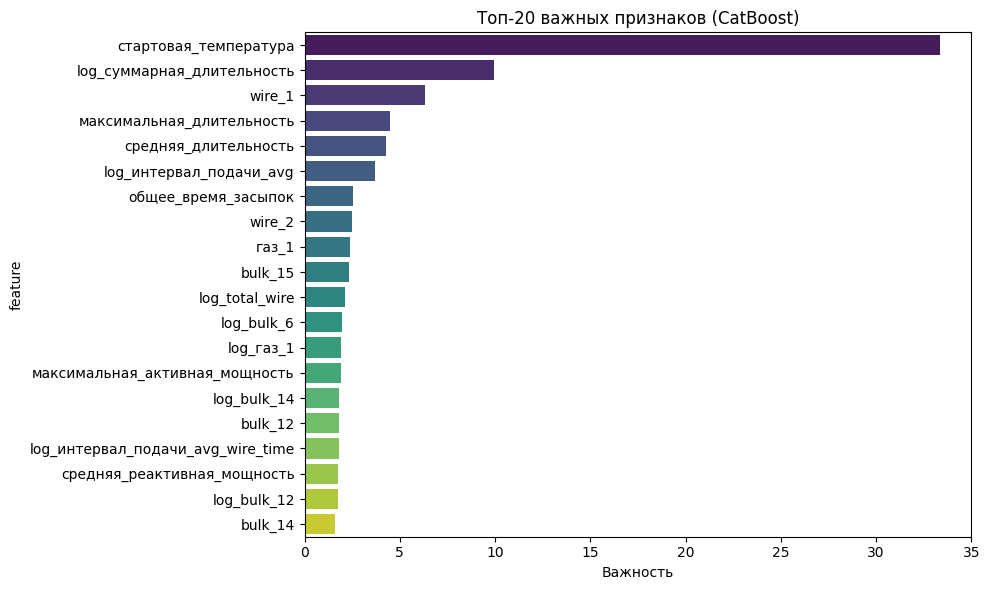

In [113]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model_cb_final.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

logger.info("Топ-20 важных признаков:")
logger.info("\n" + feature_importance.head(20).to_string(index=False))

plt.figure(figsize=(10, max(6, len(feature_importance.head(20))*0.3)))
sns.barplot(data=feature_importance.head(20), y='feature', x='importance', palette='viridis')
plt.title('Топ-20 важных признаков (CatBoost)')
plt.xlabel('Важность')
plt.tight_layout()
plt.show()

Таргет зависит от стартовой температуры, поэтому необходимо больше уделать этому внимания  
Плюс важную роль играет и продолжительность процесса

### связь с таргетом

2026-03-04 23:51:29 [INFO] __main__: Исследуем зависимость целевой переменной от признака: стартовая_температура


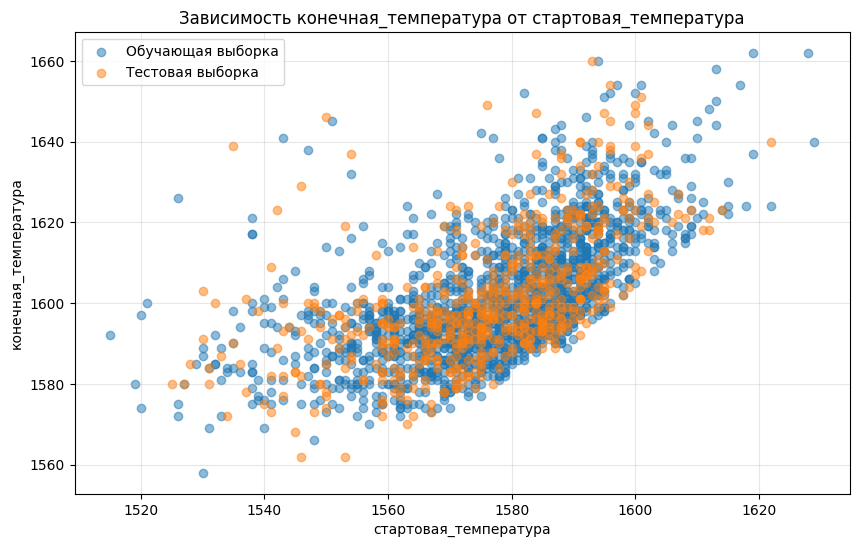

In [ ]:
top_feature = feature_importance.iloc[0]['feature']
logger.info(f"Исследуем зависимость целевой переменной от признака: {top_feature}")


plt.figure(figsize=(10, 6))
plt.scatter(X_train[top_feature], y_train, alpha=0.5, label='Обучающая выборка')
plt.scatter(X_test[top_feature], y_test, alpha=0.5, label='Тестовая выборка')
plt.xlabel(top_feature)
plt.ylabel(TARGET)
plt.title(f'Зависимость {TARGET} от {top_feature}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

График показывает прямую зависимость конечной температуры от стартовой:  
- чем выше старт, тем выше финиш (логично для нагрева).  

Разброс при одинаковом старте говорит о влиянии других факторов (мощность, длительность и пр.).  
Обучающая и тестовая выборки лежат в одной области — распределения согласованы, модель сможет обобщать.

### дополнительный анализ

2026-03-04 23:51:30 [INFO] __main__: Среднее значение конечная_температура по группам признака стартовая_температура:
2026-03-04 23:51:30 [INFO] __main__: 
             group        mean  count
(1514.999, 1565.0] 1590.538028    355
  (1565.0, 1575.0] 1593.928962    366
  (1575.0, 1583.0] 1599.694767    344
  (1583.0, 1590.0] 1605.630986    355
  (1590.0, 1629.0] 1618.653374    326


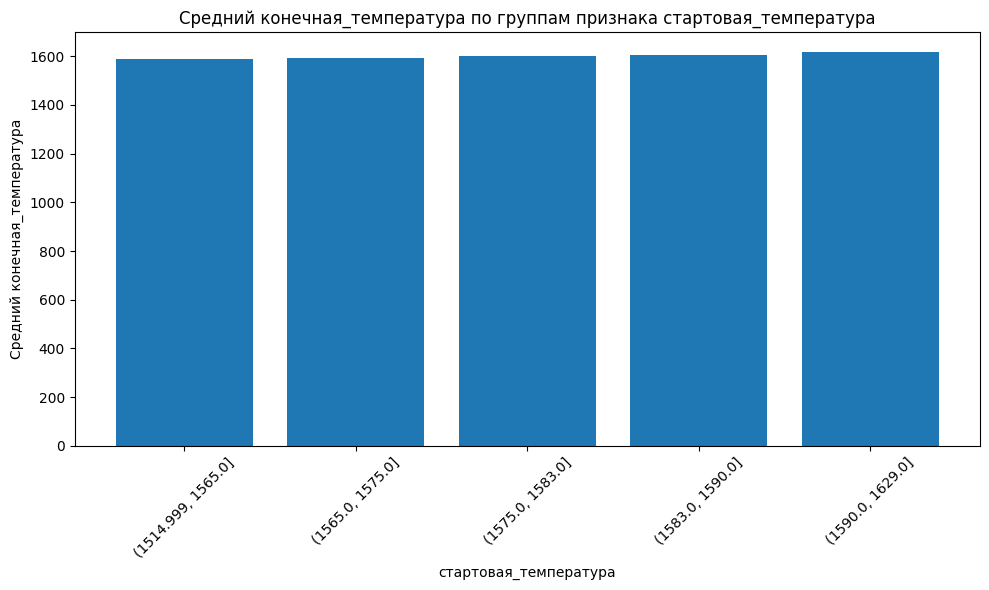

In [115]:
df_temp = X_train[[top_feature]].copy()
df_temp[TARGET] = y_train

df_temp['group'] = pd.qcut(df_temp[top_feature], q=5, duplicates='drop')
group_stats = df_temp.groupby('group')[TARGET].agg(['mean', 'count']).reset_index()

logger.info(f"Среднее значение {TARGET} по группам признака {top_feature}:")
logger.info("\n" + group_stats.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.bar(range(len(group_stats)), group_stats['mean'], tick_label=group_stats['group'].astype(str))
plt.xlabel(top_feature)
plt.ylabel(f'Средний {TARGET}')
plt.title(f'Средний {TARGET} по группам признака {top_feature}')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


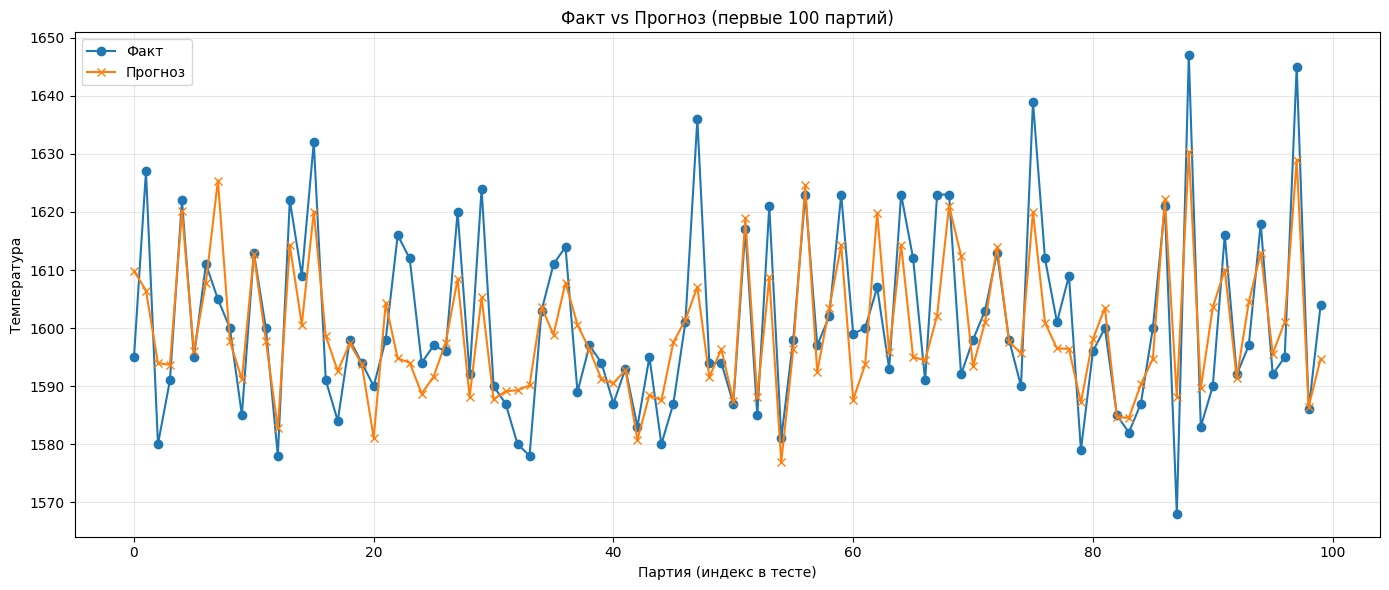

In [118]:
n = 100
y_true_100 = y_test.iloc[:n].values
y_pred_100 = y_test_pred_cb[:n]

plt.figure(figsize=(14, 6))
plt.plot(y_true_100, label='Факт', marker='o')
plt.plot(y_pred_100, label='Прогноз', marker='x')
plt.title('Факт vs Прогноз (первые 100 партий)')
plt.xlabel('Партия (индекс в тесте)')
plt.ylabel('Температура')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

В целом модель работает неплохо, но плохо себя чувствует в пиковых точках

# Выводы